# **Predicting Term Deposits Subscription: A Classification & Segmentation Approach for Bank Telemarketing Campaigns**

## **01. Data Cleaning & EDA**

# Problem Statement:

A bank conducted a telemarketing campaign for one of its financial products called ‘Term Deposits’ to help foster long-term relationships with existing customers. The dataset contains information about all the customers who were contacted during a particular year to open term deposit accounts with the bank.

What is the term Deposit?

Term deposits also called fixed deposits, are the cash investments made for a specific time period ranging from 1 month to 5 years for predetermined fixed interest rates. The fixed interest rates offered for term deposits are higher than the regular interest rates for savings accounts. The customers receive the total amount (investment plus the interest) at the end of the maturity period. Also, the money can only be withdrawn at the end of the maturity period. Withdrawing money before that will result in an added penalty associated, and the customer will not receive any interest returns.


# Business Objective:

**This project implements the machine learning binary classification to predict if the customer will take/** **subscribe a bank term deposit (variable y) by analyzing various customers dimensions. Build a model for Data-Driven Approach to Predict the Success of Bank Telemarketing**


### **1. Data Ingestion & Understanding**

In [347]:
# Import Libraries

import pandas as pd 
import numpy as np  
import sidetable
import sklearn
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from glob import glob
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from itertools import combinations

In [348]:
# Display Settings

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display
from IPython.display import Markdown

# Display markdown formatted output like bold, italic bold etc.'''
def display_md(string):
    display(Markdown(string))
    

### **1.1. Data Ingestion & Basic Understanding**

In [349]:
path = Path.cwd().parent
path_data = path/'data'/'raw'
files = []
for file in path_data.glob('*'):
    files.append(file)

files 

[WindowsPath('e:/Bank-Telemarketing/data/raw/.gitkeep'),
 WindowsPath('e:/Bank-Telemarketing/data/raw/bank-additional-full.csv'),
 WindowsPath('e:/Bank-Telemarketing/data/raw/bank-additional-names.txt'),
 WindowsPath('e:/Bank-Telemarketing/data/raw/bank-full.csv'),
 WindowsPath('e:/Bank-Telemarketing/data/raw/info.txt')]

In [350]:
f = open(path_data/'bank-additional-names.txt','rt')
for line in f.readlines():
    print(line.strip())

Citation Request:
This dataset is publicly available for research. The details are described in [Moro et al., 2014].
Please include this citation if you plan to use this database:

[Moro et al., 2014] S. Moro, P. Cortez and P. Rita. A Data-Driven Approach to Predict the Success of Bank Telemarketing. Decision Support Systems, In press, http://dx.doi.org/10.1016/j.dss.2014.03.001

Available at: [pdf] http://dx.doi.org/10.1016/j.dss.2014.03.001
[bib] http://www3.dsi.uminho.pt/pcortez/bib/2014-dss.txt

1. Title: Bank Marketing (with social/economic context)

2. Sources
Created by: Sérgio Moro (ISCTE-IUL), Paulo Cortez (Univ. Minho) and Paulo Rita (ISCTE-IUL) @ 2014

3. Past Usage:

The full dataset (bank-additional-full.csv) was described and analyzed in:

S. Moro, P. Cortez and P. Rita. A Data-Driven Approach to Predict the Success of Bank Telemarketing. Decision Support Systems (2014), doi:10.1016/j.dss.2014.03.001.

4. Relevant Information:

This dataset is based on "Bank Marketing" UC

In [351]:
print("Loading raw data...")
try:
    org_data = pd.read_csv(path/'data'/'raw'/'bank-full.csv', sep=';')
    org_data.columns = org_data.columns.str.strip().str.replace(".", "_").str.replace(" ", "_")
    display(org_data.head(2))
    print(f"Duplicate Entries : {org_data.duplicated().sum()}", end="\n\n")
    print(f"Dataset Shape : {org_data.shape}")
except Exception as e:
    print(f"Data Loading Error: {e}")



Loading raw data...


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no


Duplicate Entries : 0

Dataset Shape : (45211, 17)


In [352]:
org_data.shape
print('Number of rows:', org_data.shape[0])
print('Number of columns:', org_data.shape[1])

Number of rows: 45211
Number of columns: 17


In [353]:
org_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


The data is collected by Banco de Portugal via direct phone call marketing campaigns but duration of call is not included, where 15 columns are recorded for 45211 term deposit market campaign.

**Bank Client Data Description:**

- **age**: Age of the client (numeric)
- **job**: Type of job (categorical: 'admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown')
- **marital**: Marital status (categorical: 'divorced', 'married', 'single')
- **education**: Level of education (categorical: 'secondary', 'tertiary', 'primary', 'unknown')
- **default**: Whether the client has credit in default (binary: 'no', 'yes')
- **housing**: Whether the client has a housing loan (binary: 'no', 'yes')
- **loan**: Whether the client has a personal loan (binary: 'no', 'yes')

**Last Contact Data Description:**

- **contact**: Type of communication used to contact the client (categorical: 'cellular', 'telephone', 'unknown')
- **month**: Last contact month of the year (categorical: 'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec')
- **day**: Last contact day of the month (numerical)
- **duration**: Duration of the last contact in seconds (numeric)
Important note:  this attribute highly affects the output target (e.g., if duration=0 then y="no"). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model

**Campaign Data Description:**

- **campaign**: Number of contacts performed during this campaign for this client (numeric, includes last contact)
- **pdays**: Number of days since the client was last contacted from a previous campaign (numeric; -1 means client was not previously contacted)
- **previous**: Number of contacts performed before this campaign for this client (numeric) 
- **poutcome**: Outcome of the previous marketing campaign (categorical: 'failure', 'unknown', 'success')

**Target Variable:**
- **y**: Whether the client subscribed to a term deposit (binary: 'no', 'yes')



***Dataset Summary:***

**This dataset represents the direct marketing campaign(phone calls) of a Portuguese banking institution, where each record represents a client and the outcome of a marketing campaign to convince the client to subscribe a term deposit. The dataset contains both categorical and numerical features describing each client's demographics, behaviroal, with a binary target variable indicating whether the client subscribed to a term deposit. The data spans from May 2008 to November 2010**

**Missing Attribute Values**: There are several missing values in some categorical attributes, all coded with the "unknown" label. These missing values can be treated as a possible class label or using deletion or imputation techniques.


### **2. Formatting and Consistency Checks**

In [354]:
pd.DataFrame({
    'dtype':org_data.dtypes,
    'nunique': org_data.nunique(),
    'unique': [org_data[col].unique() for col in org_data.columns]},
    index=org_data.columns)

,dtype,nunique,unique
age,int64,77,"[58, 44, 33, 47, 35, 28, 42, 43, 41, 29, 53, 5..."
job,object,12,"[management, technician, entrepreneur, blue-co..."
marital,object,3,"[married, single, divorced]"
education,object,4,"[tertiary, secondary, unknown, primary]"
default,object,2,"[no, yes]"
balance,int64,7168,"[2143, 29, 2, 1506, 1, 231, 447, 121, 593, 270..."
housing,object,2,"[yes, no]"
loan,object,2,"[no, yes]"
contact,object,3,"[unknown, cellular, telephone]"
day,int64,31,"[5, 6, 7, 8, 9, 12, 13, 14, 15, 16, 19, 20, 21..."


In [355]:
def highlight_zero_negative(val):
    if val < 0:
        return 'background-color: red; color: white;'  # Negative values styled in red
    elif val == 0:
        return 'background-color: yellow; color: black;'  # Zero values styled in yellow
    else:
        return ''  # No styling for positive values

In [356]:
def highlight_repeats(series):
    is_repeat = series.duplicated(keep=False)  # Identify repeated values
    return ['background-color: green; color: white' if repeat else '' for repeat in is_repeat]


In [357]:
# Formatting and data descripition for numerical columns 
df_descb = org_data.describe(include='number')
print("Zero & Negative Values in Dataset :")
display(df_descb.style.applymap(highlight_zero_negative))

print("Repeat Values in Dataset :", end="\n\n")
display(df_descb.style.apply(highlight_repeats))

Zero & Negative Values in Dataset :


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


Repeat Values in Dataset :



,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [358]:
org_data[org_data['duration'].isin([0])]['y']

6424     no
22937    no
36425    no
Name: y, dtype: object

In [359]:
org_data.stb.missing().query("percent > 0")

,missing,total,percent


In [360]:
org_data.describe(exclude='number')

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


**NOTEs:**

- **Duration**: this attribute highly affects the output target (e.g., if duration=0 then y="no"). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.

- **pdays** : -1 means client was not previously contacted

- As there are no `NaN` values in the dataset, we will focus on the numerical features if any other value represent `np.nan` during preprocessing.


## **3. EDA**

In [361]:
data = org_data.copy()
data.rename(columns={'y': 'term_deposit'}, inplace=True)

In [362]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'term_deposit'],
      dtype='object')

In [363]:
# Categorical columns Consistency Check

def calculate_category_cols_info(df:pd.DataFrame):
    #Store data in dictionary
    value_dict = {}
    pct_dict = {}

    # Get categorical columns
    cat_cols = df.select_dtypes(include=['object']).columns

    # Iterate through each categorical column
    for col in cat_cols:
        count = df[col].value_counts()
        pct = df[col].value_counts(normalize=True) * 100
        value_dict[col] = count.to_dict()
        pct_dict[col] = pct.to_dict()

    # Convert dictionary of dictionaries to DataFrames
    count_df = pd.DataFrame.from_dict(value_dict, orient='index').stack().reset_index()
    count_df.columns = ['Features', 'Category', 'Count']
    pct_df = pd.DataFrame.from_dict(pct_dict, orient='index').stack().reset_index()
    pct_df.columns = ['Features', 'Category', 'Percentage']

    # Merge the two DataFrames on Features and Category
    result_df = pd.merge(count_df, pct_df, on=['Features', 'Category'])
    
    # Set MultiIndex for better readability
    result_df.set_index(['Features', 'Category'], inplace=True)

    return result_df

In [364]:
# Define a function to highlight specific category
def highlight_category(val):
    return np.where(val=='unknown','background-color: orange; color:white;',"")  # Highlight 'unknown' in orange


In [365]:
cat_df = calculate_category_cols_info(data)
cat_df.style.apply_index(highlight_category)

- **Features such as `job, education, contact, and poutcome` contain 'unknown' values. We will examine how to handle these values during preprocessing.**


#### **3.1. Demographic Features Analysis**

- Demographic factors are statistical characteristics of a populations that helps in analyzing and understanding social, economic and cultural trends. Common demographic factors include **age, gender, income, education level, marital status, occupation, and geographic location**. These factors are often used in market research, public health studies, and social science research to segment populations and identify patterns or trends.

By the above definition of demographic factors, the following featurs can be considered as demographic factors in the datset:
- **age**: indicator of the customer's age group, ehich can influence their financial behaviour and lifestyle choices.'
- **job**: indicate the customer's occupation, which can affect their income and financial decisions.
- **marital**: indicates the customer's marital status, which can influence financial priorities and consumption patterns.
- **education**: indicates the customer's level of education, which can impact their financial literacy and decision-making abilities.

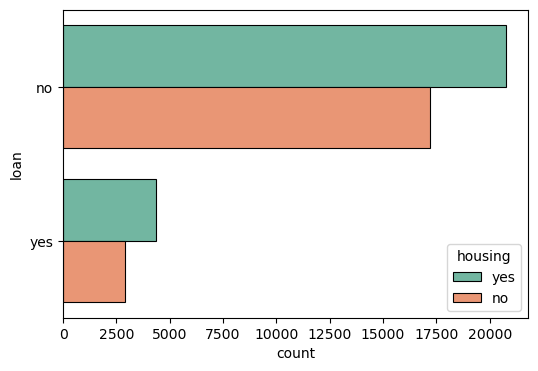

In [366]:
# Number of campaign customer by personal loans and housing loans
plt.figure(figsize=(6,4))
sns.countplot(data=data, y='loan', hue='housing', palette='Set2', edgecolor='black', linewidth=0.8)
plt.show()

In [367]:
# numeric features distribution plots
def univariate_numeric_distribution(df:pd.DataFrame, col:str):
    fig, ax = plt.subplots(ncols=2, figsize=(15, 5))

    sns.histplot(data=df, x = col, ax=ax[0], bins=30, kde=True, stat='density', color='lightskyblue')
    ax[0].lines[0].set_color('crimson')
    ax[0].set_title(f'{col.capitalize()} Distribution with Density Curve', fontsize=14, fontweight='bold')
    
    sns.boxplot(data=df, x = col, ax=ax[1], fill=False, color='k', flierprops=dict(marker='o', markerfacecolor='r'))
    ax[1].set_title(f'Box Plot for {col.capitalize()}', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    plt.show()
    

In [368]:
# categorical features distribution plots
def univariate_categorical_distribution(df: pd.DataFrame, col: str):
    fig, ax = plt.subplots(ncols=2, figsize=(20, 8))

    # Bar plot (frequency counts)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=ax[0], palette="pastel")
    ax[0].set_title(f'{col.capitalize()} Distribution (Bar Plot)', fontsize=14, fontweight='bold', y=1.02)
    ax[0].tick_params(axis='x', rotation=45)

    # Pie plot (proportions)
    counts = df[col].value_counts()
    ax[1].pie(
        counts.values, labels=counts.index, 
        autopct='%1.1f%%', startangle=45, 
        colors=sns.color_palette("pastel"), 
        textprops={'fontsize': 12, 'weight':'bold', 'color':'k'}
    )
    ax[1].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    ax[1].set_title(f'{col.capitalize()} Distribution (Pie Chart)', fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    plt.show()


In [369]:
# plots for numeric columns and target column
def plot_numeric_columns(df:pd.DataFrame, column:str, target:str='term_deposit', kde:bool = True,edgecolor:str = 'black',multiple:str ='stack') ->None:
    ''' 
    Plots histogram and normalized histogram of specified numeric columns with a target column in hue.

    Parameters:


    Returns:
    None: Displays the histogram and normalized histogram plots for numeric columns.
    '''
    fig, ax = plt.subplots(ncols=2, figsize=(15,5),sharey=True)

    # histogram plot for each type of term_deposit customer
    sns.histplot(data=df, y=column, hue=target ,kde=kde, edgecolor=edgecolor,linewidth=0.8, legend=False, alpha =0.6,multiple=multiple ,ax=ax[0])

    # Normalized histogram plot for each type of term_deposit customer
    sns.histplot(data=df, y=column, hue=target,kde=kde ,stat='percent', edgecolor=edgecolor,linewidth=0.8, multiple=multiple ,ax=ax[1])

    # set titles and labels
    ax[0].set_ylabel(column.capitalize(), fontsize=12, fontweight='bold')
    ax[0].set_xlabel('Term Deposit Count', fontsize=12, fontweight='bold')
    ax[1].set_xlabel('Term Deposit Percentage', fontsize=12, fontweight='bold')

    # Hide all spines for both subplots
    sns.despine(left=True,bottom=True)
    # Display settings
    plt.suptitle(f'Distribution of Counts & Percentages of Normalized Term Deposit for {column.capitalize()}', fontsize=14, fontweight='bold')
    plt.subplots_adjust(top=0.96)
    plt.tight_layout()
    plt.show()


In [370]:
# plots for categorical columns and target column
def plot_categorical_columns(df:pd.DataFrame, column: str, target:str='term_deposit'):
    """
    Plot counts and percentages of a categorical column with respect to a target column.

    Parameters:

    Returns:
    None: Displays the bar plot of counts and percentages of the categorical column with respect to the target column.
    """
    # count DataFrame for the specified column and target
    count_df = pd.crosstab(df[column], df[target]).stack().reset_index().rename(columns={0:'count'})
                                                                                
    # percentage DataFrame for the specified column and target
    pct_df = (pd.crosstab(df[column], df[target], normalize='index').round(4)*100).stack().reset_index().rename(columns={0:'percentage'})

    # Display the counts DataFrame
    display(count_df.head(10))

    # Create subplots for count and percentage
    fig, ax = plt.subplots(ncols=2, figsize=(15, 5), sharey=True)

    #plot using seaborn barplot for count and percentage
    sns.barplot(data=count_df, x='count', y=column, hue=target, ax=ax[0], palette='Set2', edgecolor='black', linewidth=0.8)
    sns.barplot(data=pct_df, x='percentage', y=column, hue=target, ax=ax[1], palette='Set2', edgecolor='black', linewidth=0.8,legend=False)

    # Set titles and labels
    ax[0].set_ylabel(column.capitalize(), fontsize=12, fontweight='bold')
    ax[0].set_xlabel('Count', fontsize=12, fontweight='bold')
    ax[1].set_xlabel('Percentage', fontsize=12, fontweight='bold')
    

    # Hide all spines for both subplots
    sns.despine(left=True, bottom=True)
    
    # Display settings
    plt.suptitle(f'Counts & Percentages of Term Deposit for each category in {column.capitalize()}', fontsize=14, fontweight='bold')
    plt.subplots_adjust(top=0.96)   
    plt.tight_layout()

    #add legend to the first subplot
    ax[0].legend(labelcolor='linecolor', loc='lower right', title=target.capitalize(),edgecolor='black', fontsize=10, title_fontsize='12', frameon=True, framealpha=0.8)
    plt.show()

                                                                                                                                        

**Age**

In [371]:
display_md("**Age Distribution Summary :**")
print(data['age'].describe())


**Age Distribution Summary :**

count   45211.00
mean       40.94
std        10.62
min        18.00
25%        33.00
50%        39.00
75%        48.00
max        95.00
Name: age, dtype: float64


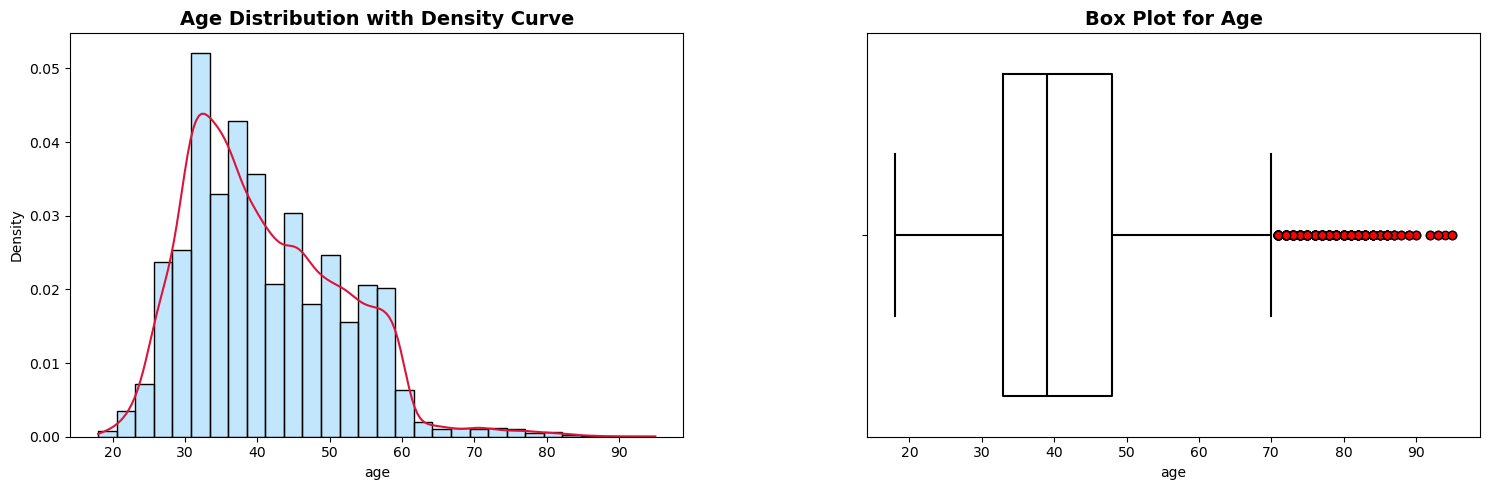

In [372]:
univariate_numeric_distribution(data, 'age')

In [373]:
# Create age groups
def categorize_age(age):
    if age < 25:
        return 'Young (18-24)'
    elif age < 35:
        return 'Young Adult (25-34)'
    elif age < 50:
        return 'Middle Age (35-49)'
    elif age < 65:
        return 'Senior (50-64)'
    else:
        return 'Super Senior (65+)'

data['age_group'] = data['age'].apply(categorize_age)

# Count and percentage by age group
age_group_counts = data['age_group'].value_counts()
age_group_percentages = data['age_group'].value_counts(normalize=True) * 100

display_md("**Age Group Distribution:**")
for group in age_group_counts.index:
    display(f"{group} : {age_group_counts[group]} ({age_group_percentages[group]:.2f}%)")


**Age Group Distribution:**

'Middle Age (35-49) : 20004 (44.25%)'

'Young Adult (25-34) : 14204 (31.42%)'

'Senior (50-64) : 9384 (20.76%)'

'Super Senior (65+) : 810 (1.79%)'

'Young (18-24) : 809 (1.79%)'

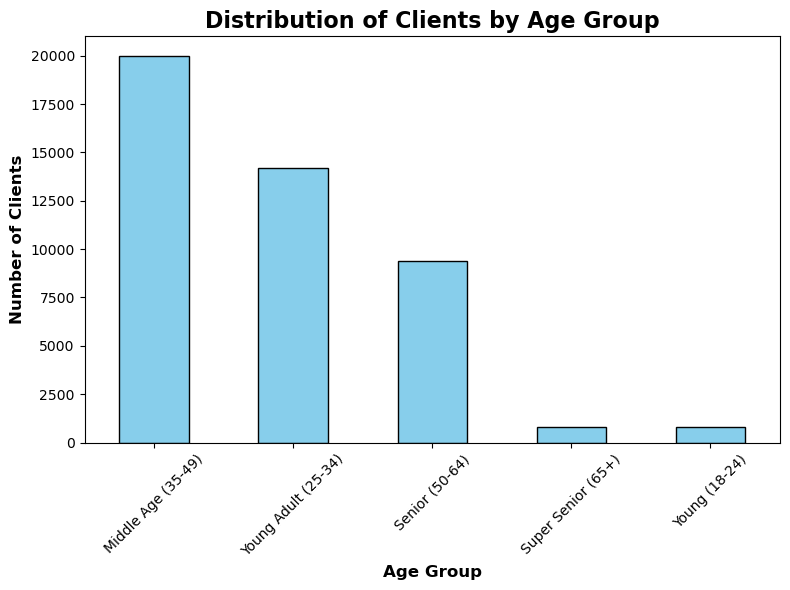

In [374]:
plt.figure(figsize=(8, 6))
age_group_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Clients by Age Group', fontsize=16, fontweight='bold')
plt.xlabel('Age Group', fontsize=12, fontweight='bold')
plt.ylabel('Number of Clients', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

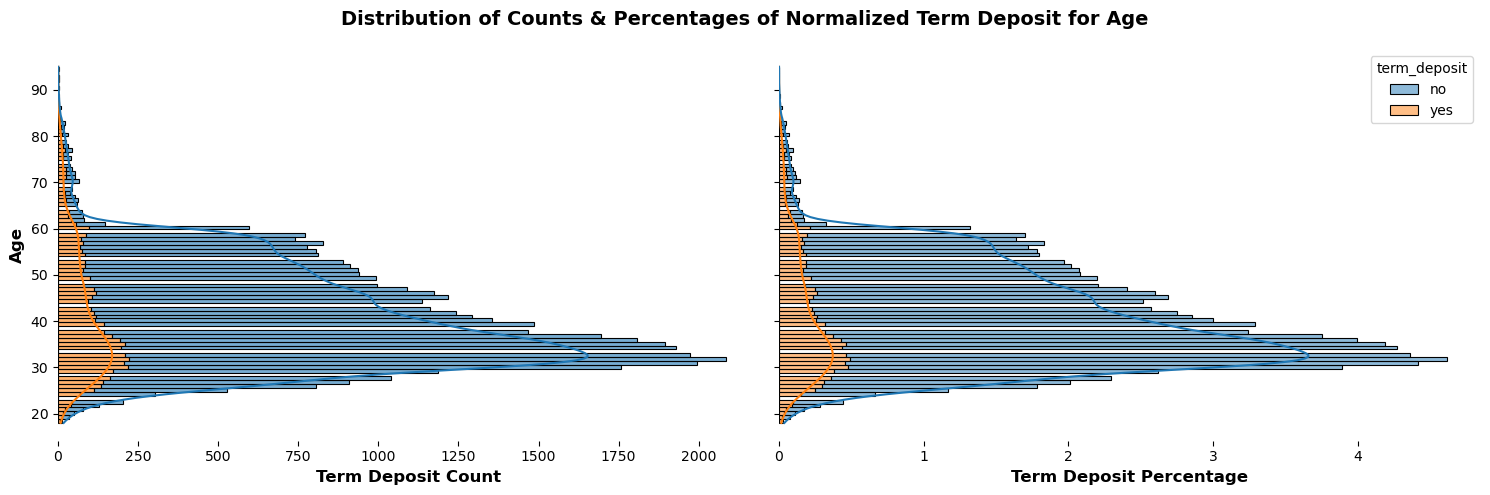

In [375]:
plot_numeric_columns(data, 'age')

**job**

In [376]:
display_md("**Job type summary :**")
display(data['job'].value_counts())

**Job type summary :**

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

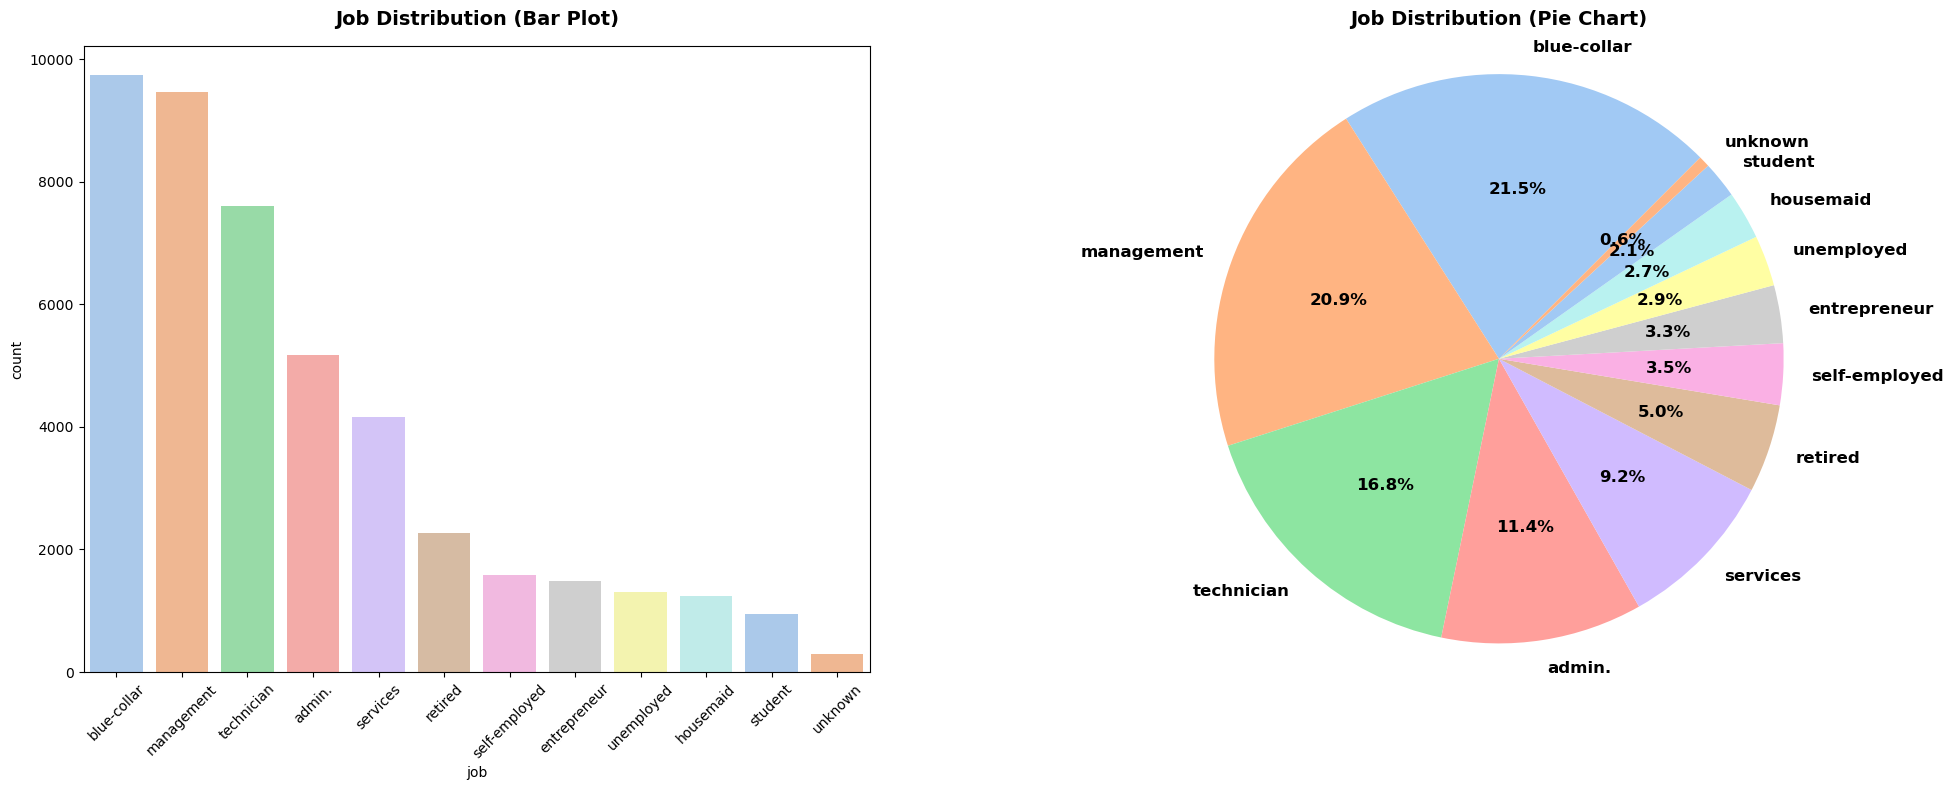

In [377]:
univariate_categorical_distribution(data, 'job')


In [378]:
# Average age by job type
job_age_stats = data.groupby('job')['age'].agg(['mean', 'median', 'std']).round(2)
job_age_stats = job_age_stats.sort_values('mean', ascending=False)

display_md("**Age Statistics by Job Type:**")
display(job_age_stats)

**Age Statistics by Job Type:**

,mean,median,std
job,,,
retired,61.63,59.00,9.54
unknown,47.59,47.00,10.78
housemaid,46.42,47.00,10.48
entrepreneur,42.19,41.00,9.11
unemployed,40.96,40.00,9.78
self-employed,40.48,39.00,9.66
management,40.45,38.00,9.38
blue-collar,40.04,39.00,9.03
technician,39.31,37.00,8.94


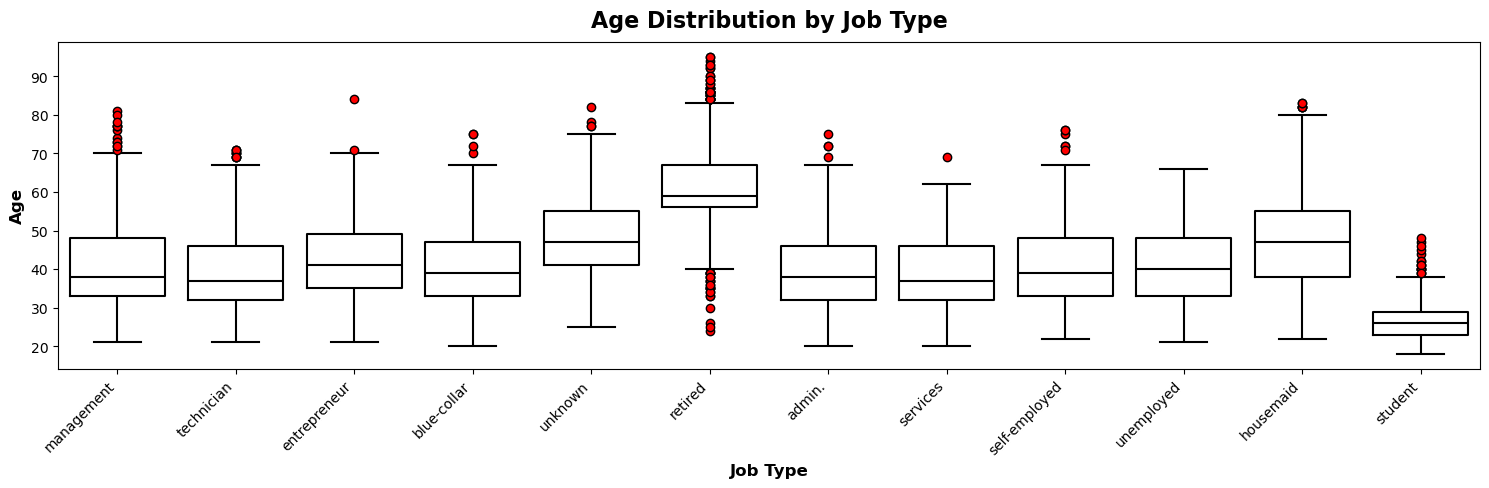

In [379]:
plt.figure(figsize=(15, 5))
sns.boxplot(data, x='job', y='age', fill=False, color='k', flierprops=dict(marker='o', markerfacecolor='r'))
plt.title('Age Distribution by Job Type', fontsize=16, fontweight='bold', y=1.02)
plt.xlabel('Job Type', fontsize=12, fontweight='bold')
plt.ylabel('Age', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [380]:
display_md("**Job Type Summary :**")
print(f"Total unique job types: {data['job'].nunique()}")
print(f"Most common job: {data['job'].mode()[0]} ({data['job'].value_counts().iloc[0]} clients)")
print(f"Least common job: {data['job'].value_counts().index[-1]} ({data['job'].value_counts().iloc[-1]} clients)")

**Job Type Summary :**

Total unique job types: 12
Most common job: blue-collar (9732 clients)
Least common job: unknown (288 clients)


,job,term_deposit,count
0,admin.,no,4540
1,admin.,yes,631
2,blue-collar,no,9024
3,blue-collar,yes,708
4,entrepreneur,no,1364
5,entrepreneur,yes,123
6,housemaid,no,1131
7,housemaid,yes,109
8,management,no,8157
9,management,yes,1301


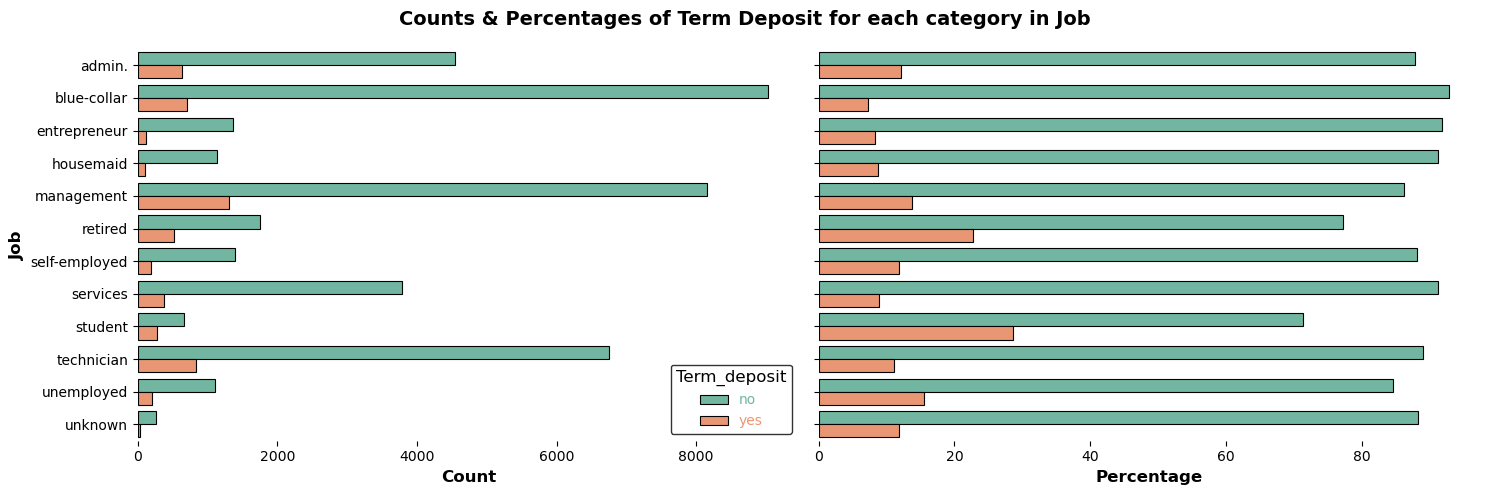

In [381]:
plot_categorical_columns(data, column='job')

**Marital**

In [382]:
display_md("**Marital Status Summary :**")
display(data['marital'].value_counts())

**Marital Status Summary :**

marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

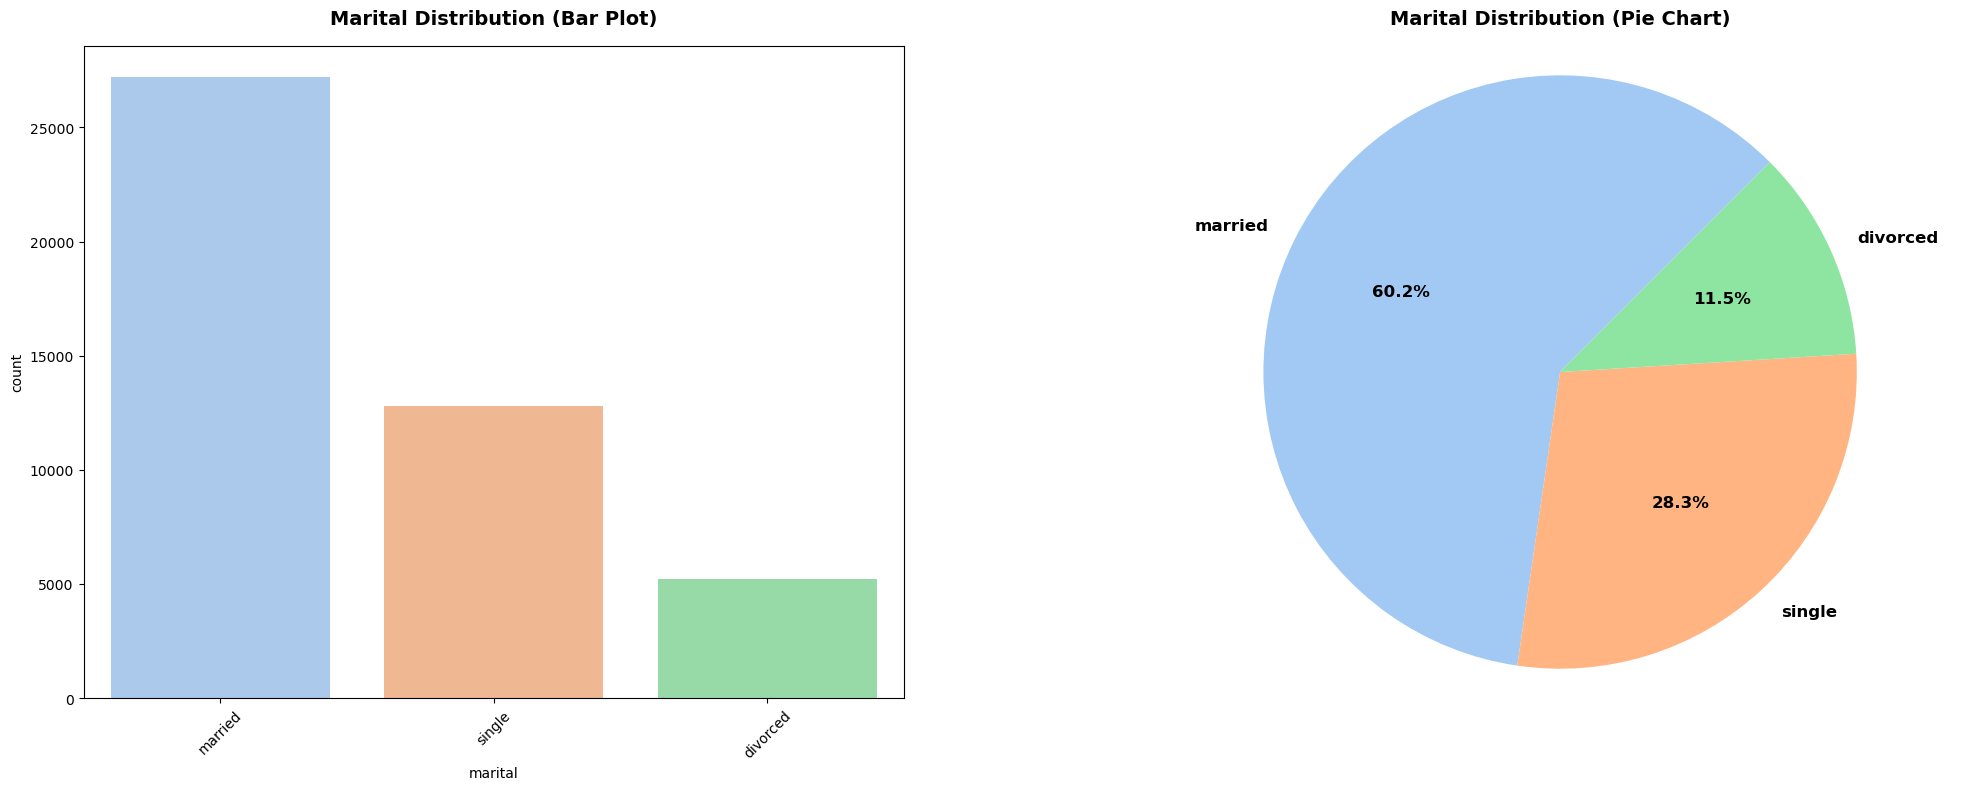

In [383]:
univariate_categorical_distribution(data, 'marital')

,marital,term_deposit,count
0,divorced,no,4585
1,divorced,yes,622
2,married,no,24459
3,married,yes,2755
4,single,no,10878
5,single,yes,1912


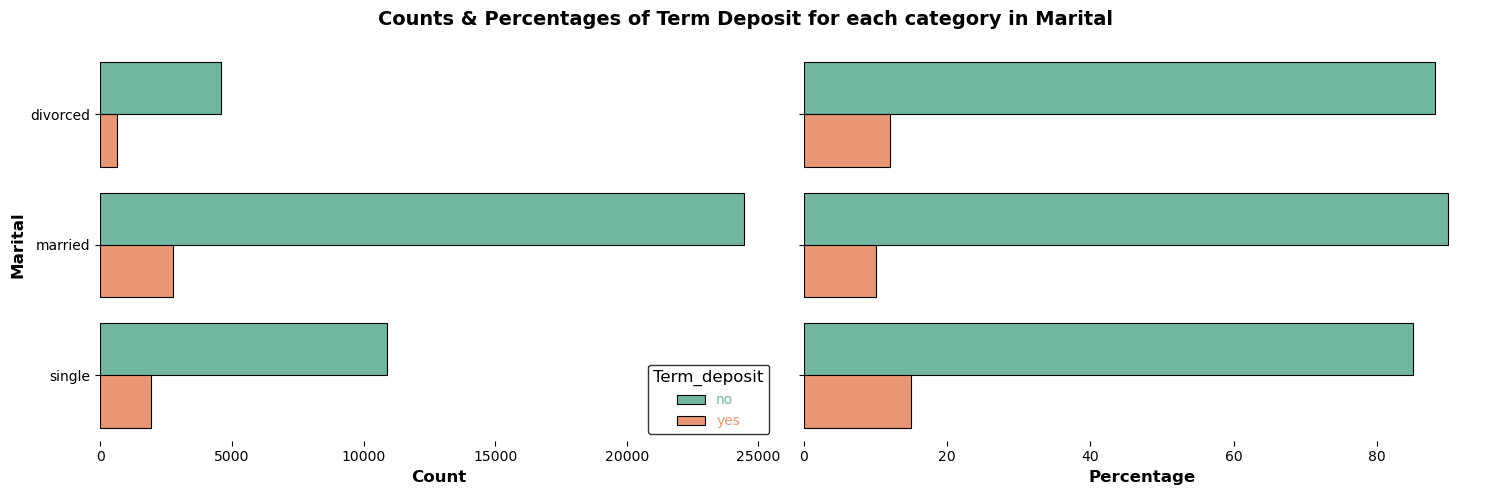

In [384]:
plot_categorical_columns(data, column='marital')

**Education**

In [385]:
display_md("**Education Level Summary :**")
display(data['education'].value_counts())


**Education Level Summary :**

education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

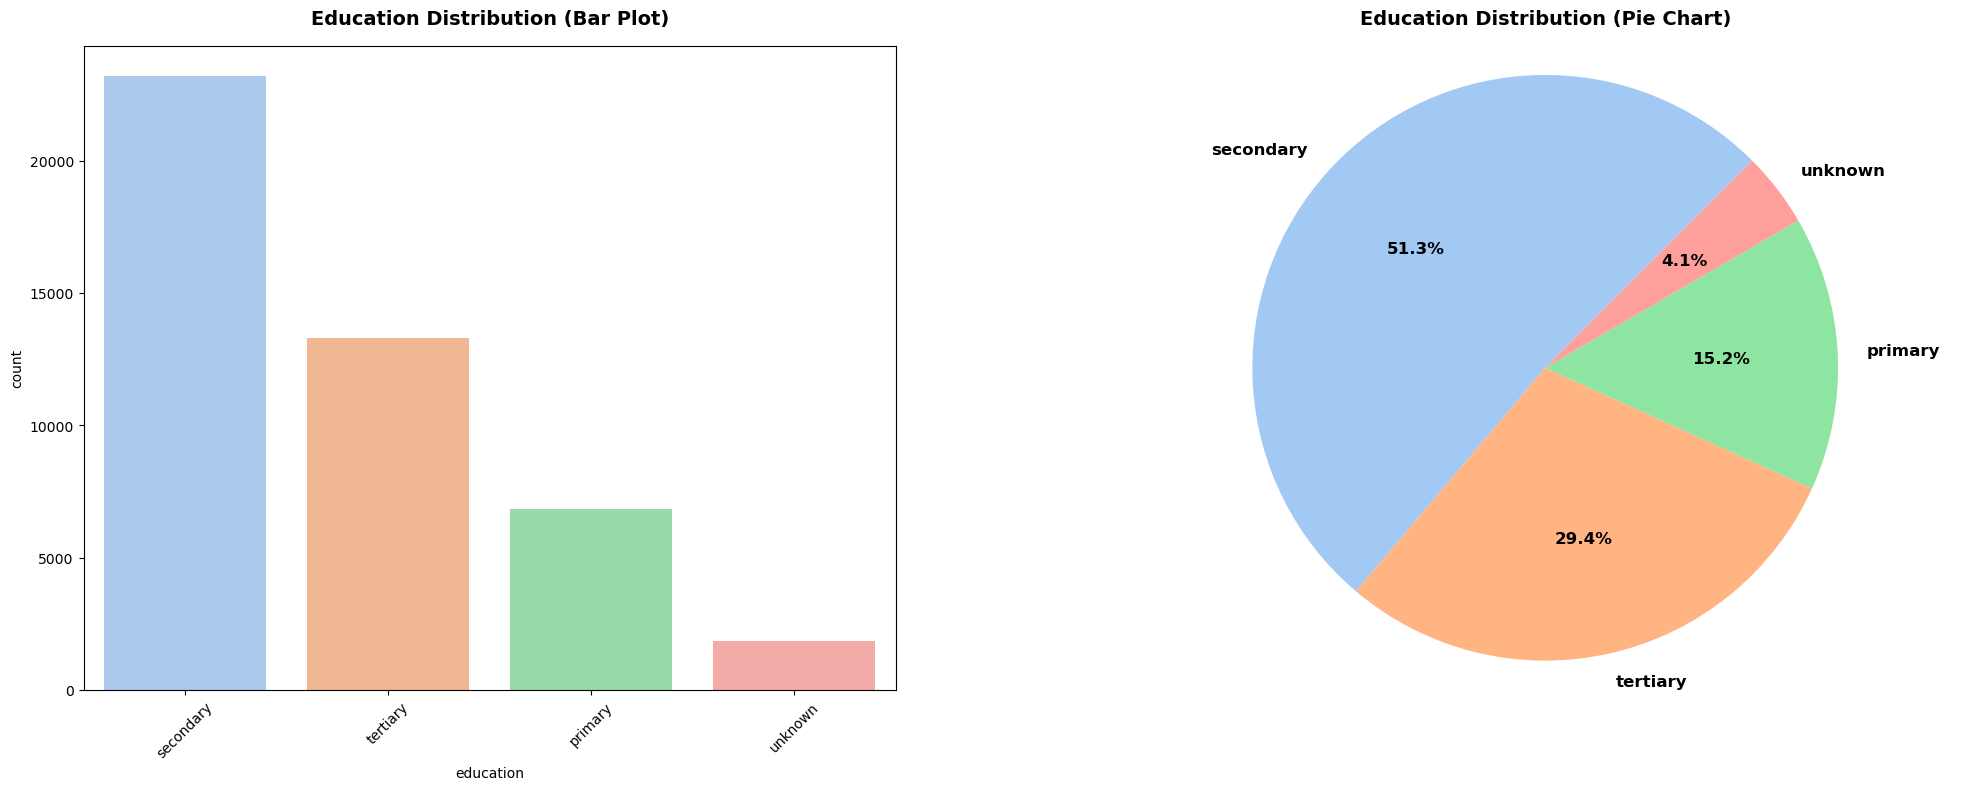

In [386]:
univariate_categorical_distribution(data, 'education')

,education,term_deposit,count
0,primary,no,6260
1,primary,yes,591
2,secondary,no,20752
3,secondary,yes,2450
4,tertiary,no,11305
5,tertiary,yes,1996
6,unknown,no,1605
7,unknown,yes,252


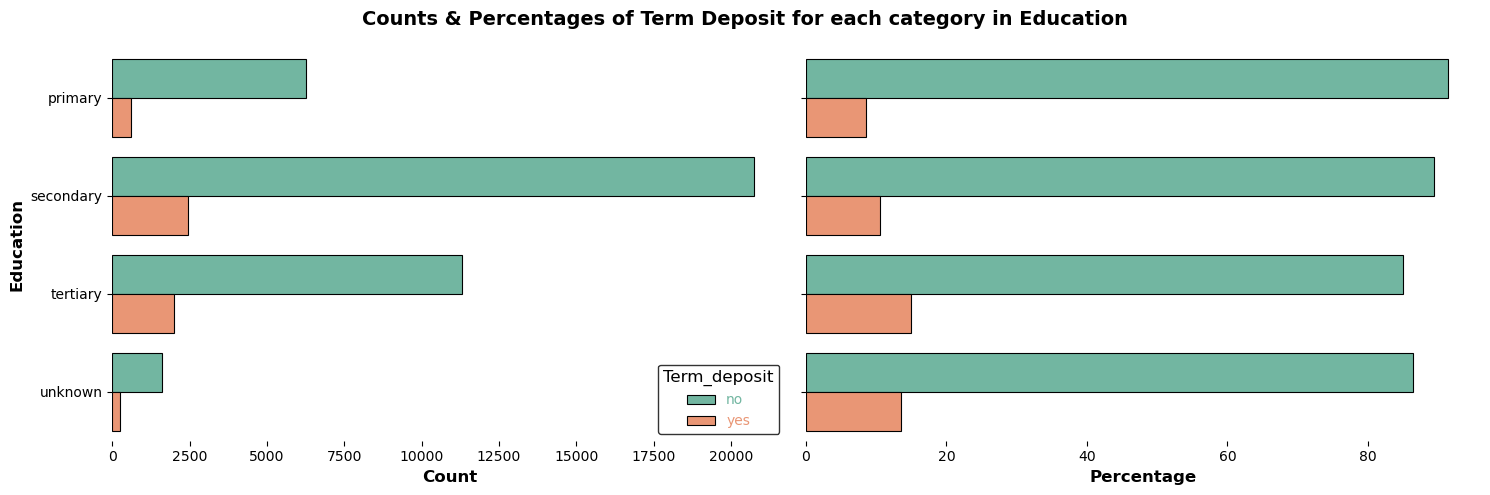

In [387]:
plot_categorical_columns(data, column='education')

### **3.2. Financial/Behavioral Features**

- Those factors which describe how the customer behaves in terms of financial decisions, response to campaigns and interaction with financial products. By this definition following features can be considered as financial factors in the dataset:

- **balance**: Average yearly balance in euros.
- **default**: indicates financial relability and risk behaviour.
- **housing**: indicates a whether the customer has long-term financial commitments.
- **loan**: presence of a personal loan indicates borrowing behaviour.


**Default**

In [388]:
# Basic default distribution
display_md("**Credit Default Distribution :**")
default_counts = data['default'].value_counts()
default_percentages = data['default'].value_counts(normalize=True) * 100

print(f"Total clients: {len(data)}")

for status in default_counts.index:
    print(f"{status}: {default_counts[status]} ({default_percentages[status]:.2f}%)")



**Credit Default Distribution :**

Total clients: 45211
no: 44396 (98.20%)
yes: 815 (1.80%)


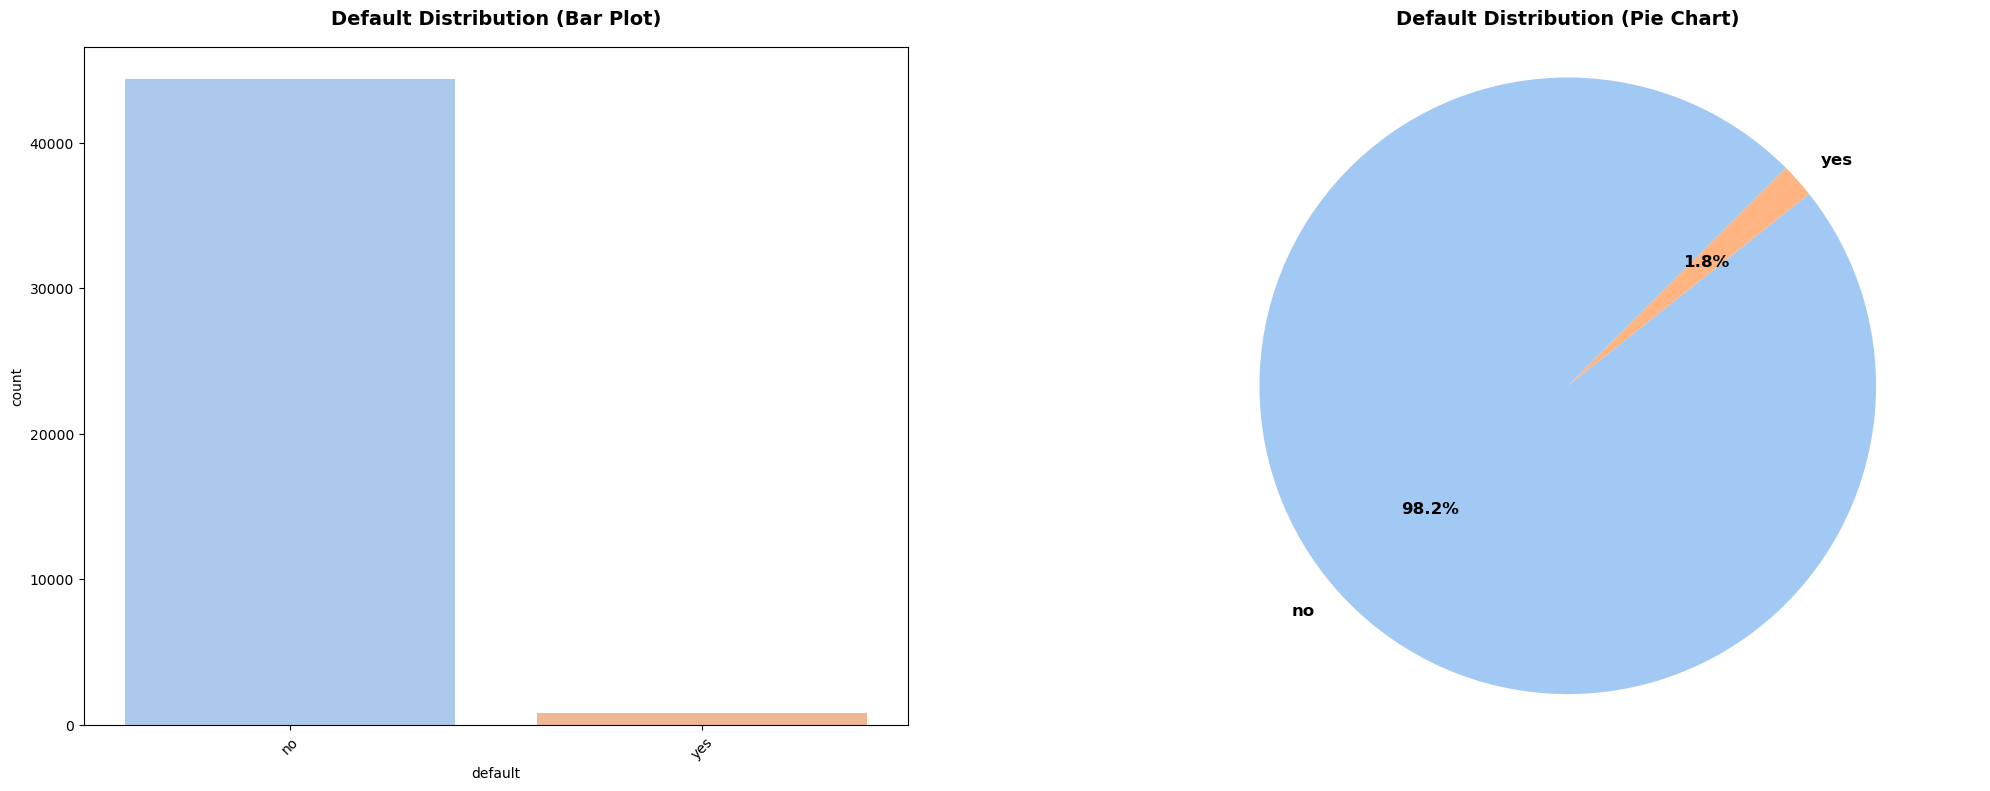

In [389]:
univariate_categorical_distribution(data, 'default')

In [390]:
# Default rate by age group

default_by_age = pd.crosstab(data['age_group'], data['default'], normalize='index') * 100
display_md("**Default Rate by Age Group (%) :**")
display(default_by_age.round(2))


**Default Rate by Age Group (%) :**

default,no,yes
age_group,,
Middle Age (35-49),98.12,1.88
Senior (50-64),98.50,1.50
Super Senior (65+),99.88,0.12
Young (18-24),98.52,1.48
Young Adult (25-34),98.00,2.00


In [391]:
# Default rate by job

default_by_job = pd.crosstab(data['job'], data['default'], normalize='index') * 100
display_md("**Default Rate by Job Type (%) :**")
display(default_by_job.round(2))
print()

display_md("**Jobs with Highest Default Rates (%) :**")
display(default_by_job.sort_values(by='yes', ascending=False)['yes'].round(2))

**Default Rate by Job Type (%) :**

default,no,yes
job,,
admin.,98.57,1.43
blue-collar,97.93,2.07
entrepreneur,96.30,3.70
housemaid,98.23,1.77
management,98.27,1.73
retired,98.85,1.15
self-employed,97.91,2.09
services,98.19,1.81
student,99.68,0.32


**Jobs with Highest Default Rates (%) :**

job
entrepreneur    3.70
unemployed      2.30
self-employed   2.09
blue-collar     2.07
services        1.81
housemaid       1.77
management      1.73
technician      1.71
admin.          1.43
retired         1.15
unknown         0.69
student         0.32
Name: yes, dtype: float64

In [392]:
# Overall default statistics

total_clients = len(data)
default_yes = len(data[data['default'] == 'yes'])
default_no = len(data[data['default'] == 'no'])
default_rate = (default_yes / total_clients) * 100

display_md("**CREDIT DEFAULT SUMMARY :**")
print(f"Total Clients: {total_clients:,}")
print(f"Clients in Default: {default_yes:,}")
print(f"Clients NOT in Default: {default_no:,}")
print(f"Default Rate: {default_rate:.2f}%")
print(f"Non-Default Rate: {100-default_rate:.2f}%")

# Risk Assessment
if default_rate < 5:
    risk_level = "Low Risk"
elif default_rate < 15:
    risk_level = "Moderate Risk"
else:
    risk_level = "High Risk"

display_md(f"**Risk Level: {risk_level}**")

**CREDIT DEFAULT SUMMARY :**

Total Clients: 45,211
Clients in Default: 815
Clients NOT in Default: 44,396
Default Rate: 1.80%
Non-Default Rate: 98.20%


**Risk Level: Low Risk**

In [393]:
# Additional insights
display_md("**KEY INSIGHTS :**")

# 1. Which job has highest default rate?
if 'yes' in default_by_job.columns:
    highest_default_job = default_by_job['yes'].idxmax()
    highest_default_rate = default_by_job['yes'].max()
    display_md(f"**Job with Highest Default Rate :** {highest_default_job} ({highest_default_rate:.2f}%)")

# 2. Age group with highest default rate
if 'yes' in  default_by_age.columns:
    highest_default_age_group = default_by_age['yes'].idxmax()
    highest_default_age_rate = default_by_age['yes'].max()
    display_md(f"**Age Group with Highest Default Rate :** {highest_default_age_group} ({highest_default_age_rate:.2f}%)")

**KEY INSIGHTS :**

**Job with Highest Default Rate :** entrepreneur (3.70%)

**Age Group with Highest Default Rate :** Young Adult (25-34) (2.00%)

,default,term_deposit,count
0,no,no,39159
1,no,yes,5237
2,yes,no,763
3,yes,yes,52


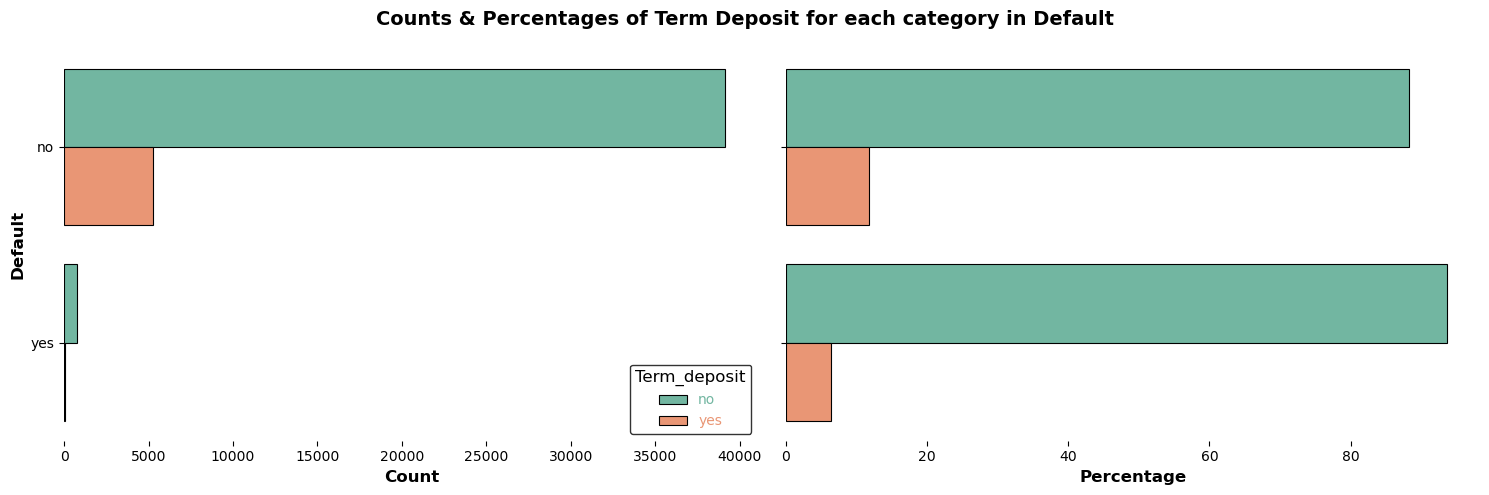

In [394]:
plot_categorical_columns(data, 'default')

default,no,yes
housing,,
no,19701,380
yes,24695,435


<Axes: xlabel='count', ylabel='housing'>

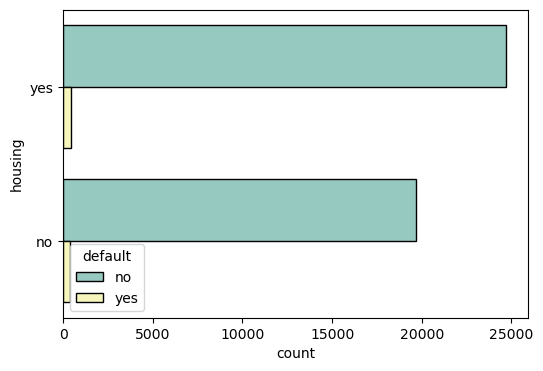

In [395]:
# Number of term_deposit customer by personal loans and housing loans
display(pd.crosstab(data['housing'], data['default']))
plt.figure(figsize=(6,4))
sns.countplot(data=data,y='housing',hue='default',palette='Set3', edgecolor='black')

**Balance**

In [396]:
display_md("**Balance Distribution  Summary :**")
display(data['balance'].describe())

**Balance Distribution  Summary :**

count    45211.00
mean      1362.27
std       3044.77
min      -8019.00
25%         72.00
50%        448.00
75%       1428.00
max     102127.00
Name: balance, dtype: float64

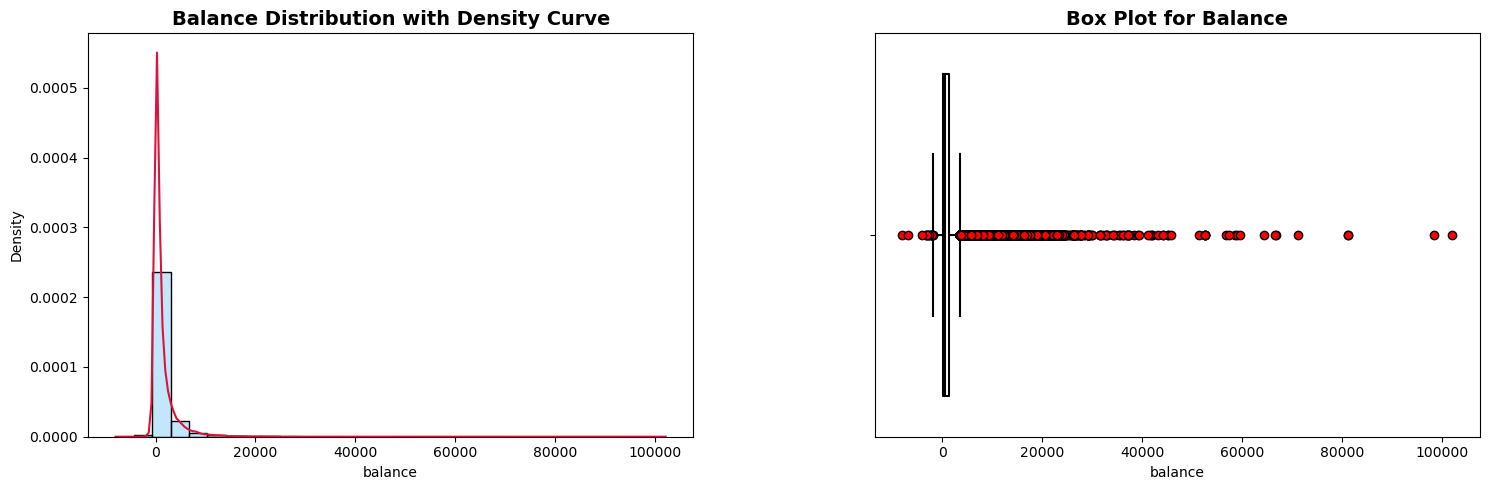

In [397]:
univariate_numeric_distribution(data, 'balance')

In [398]:
# Create balance categories
def categorize_balance(balance):
    if balance < 0:
        return 'Negative (Debt)'
    elif balance == 0:
        return 'Zero Balance'
    elif balance < 1000:
        return 'Low ($1-999)'
    elif balance < 5000:
        return 'Medium ($1K-5K)'
    elif balance < 20000:
        return 'High ($5K-20K)'
    else:
        return 'Very High ($20K+)'

data['balance_category'] = data['balance'].apply(categorize_balance)

# Count and percentage by balance category
balance_counts = data['balance_category'].value_counts()
balance_percentages = data['balance_category'].value_counts(normalize=True) * 100

display_md("**Balance Category Distribution :**")
print()
for category in balance_counts.index:
    print(f"{category} : {balance_counts[category]:,} ({balance_percentages[category]:.1f}%)")


**Balance Category Distribution :**


Low ($1-999) : 23,289 (51.5%)
Medium ($1K-5K) : 11,795 (26.1%)
Negative (Debt) : 3,766 (8.3%)
Zero Balance : 3,514 (7.8%)
High ($5K-20K) : 2,654 (5.9%)
Very High ($20K+) : 193 (0.4%)


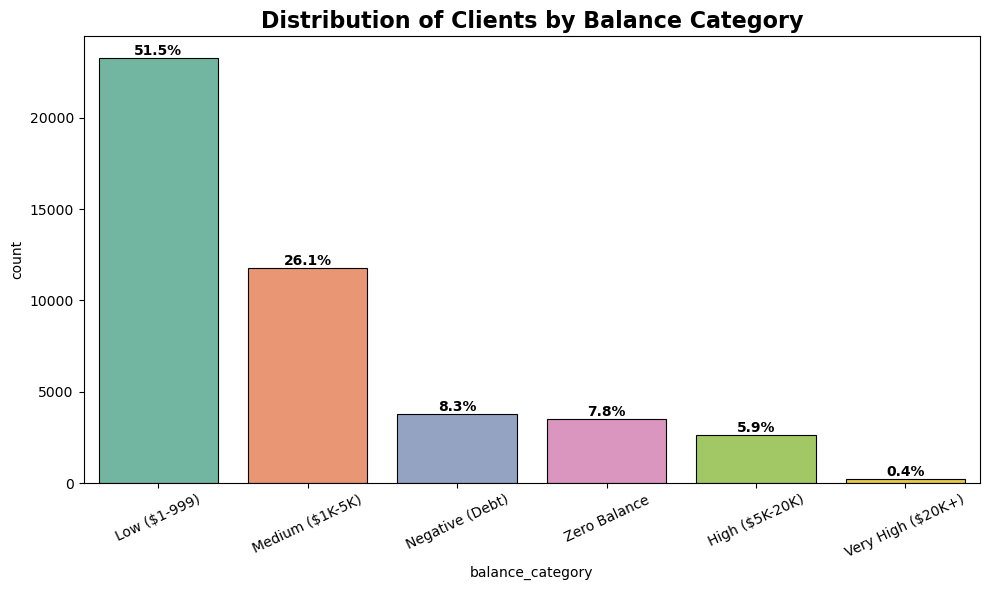

In [399]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=data, x='balance_category', order=balance_counts.index, palette='Set2', edgecolor='black', linewidth=0.8, ax=ax)

# Add labels to each bar
for idx, row in balance_counts.items():
    ax.text(idx, row, f"{balance_percentages[idx]:.1f}%", color='black', ha="center", va="bottom", fontsize=10, fontweight='bold')
ax.set_title('Distribution of Clients by Balance Category', fontsize=16, fontweight='bold')
ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

In [400]:
# Identify outliers in balance using IQR method
x_low, x_high = np.percentile(data['balance'], [25, 75])
iqr = x_high - x_low
lower_bound = x_low - 1.5 * iqr
upper_bound = x_high + 1.5 * iqr

outliers = data[~data['balance'].between(lower_bound, upper_bound)]
display_md("**Outliers Analysis :**")
print(f"Lower bound: ${lower_bound:,.2f}")
print(f"Upper bound: ${upper_bound:,.2f}")
print(f"Number of outliers: {len(outliers):,} ({len(outliers)/len(data)*100:.1f}%)")
print(f"Highest balance: ${data['balance'].max():,.2f}")
print(f"Lowest balance: ${data['balance'].min():,.2f}")


**Outliers Analysis :**

Lower bound: $-1,962.00
Upper bound: $3,462.00
Number of outliers: 4,729 (10.5%)
Highest balance: $102,127.00
Lowest balance: $-8,019.00


**Balance Statistics by Job Type :**

,mean,median,std
job,,,
retired,1984.22,787.00,4397.04
unknown,1772.36,677.00,2970.29
management,1763.62,572.00,3822.97
self-employed,1647.97,526.00,3684.26
unemployed,1521.75,529.00,3144.67
entrepreneur,1521.47,352.00,4153.44
housemaid,1392.40,406.00,2984.69
student,1388.06,502.00,2441.70
technician,1252.63,421.00,2548.54


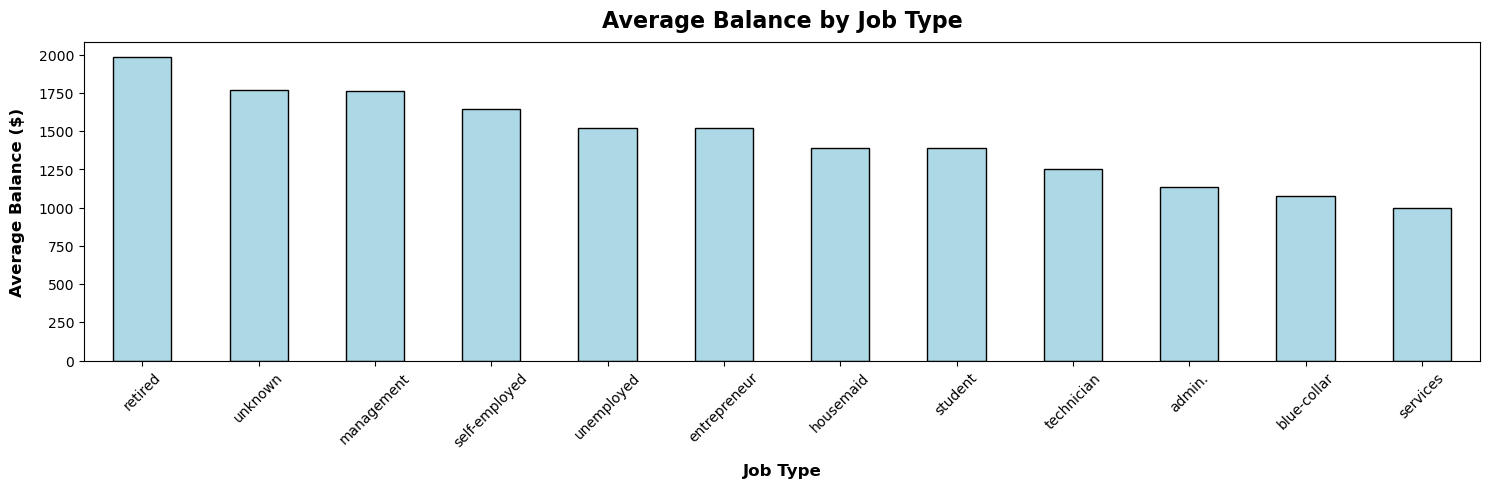

In [401]:
# Average balance by job
balance_by_job = data.groupby('job')['balance'].agg(['mean', 'median', 'std']).round(2)
balance_by_job = balance_by_job.sort_values('mean', ascending=False)

display_md("**Balance Statistics by Job Type :**")
display(balance_by_job)

# Visualization
plt.figure(figsize=(15, 5))
balance_by_job['mean'].plot(kind='bar', color='lightblue', edgecolor='black')
plt.title('Average Balance by Job Type', fontsize=16, fontweight='bold', y=1.02)
plt.xlabel('Job Type', labelpad=10, fontsize=12, fontweight='bold')
plt.ylabel('Average Balance ($)', labelpad=10, fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Balance by Age Group :**

                       mean  median  count
age_group                                 
Middle Age (35-49)  1301.58  446.00  20004
Senior (50-64)      1738.42  587.00   9384
Super Senior (65+)  2791.00 1411.00    810
Young (18-24)        915.69  377.00    809
Young Adult (25-34) 1143.20  369.00  14204


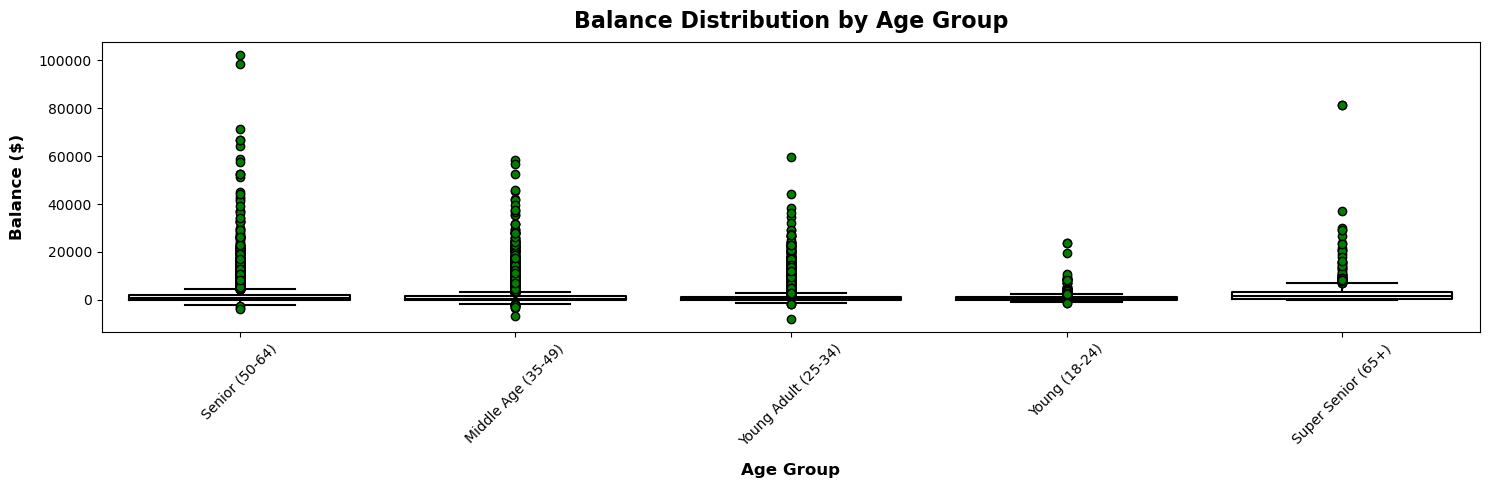

In [402]:
# Balance by age group
balance_by_age = data.groupby('age_group')['balance'].agg(['mean', 'median', 'count']).round(2)
display_md("**Balance by Age Group :**")
print(balance_by_age)

# Box plot by age group
plt.figure(figsize=(15, 5))
sns.boxplot(data=data, x='age_group', y='balance', fill=False, color='k', flierprops={'marker':'o', 'markerfacecolor':'g'})
plt.title('Balance Distribution by Age Group', fontsize=16, fontweight='bold', y=1.02)
plt.xlabel('Age Group', labelpad=10, fontsize=12, fontweight='bold')
plt.ylabel('Balance ($)', labelpad=10, fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


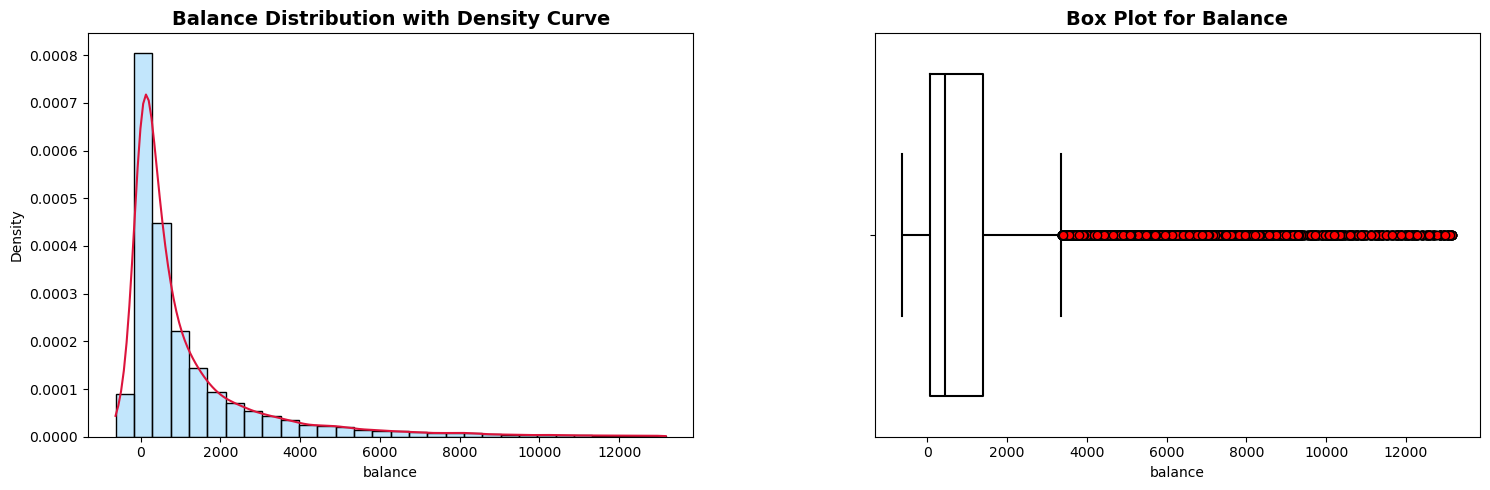

In [403]:
# Remove extreme outliers for better visualization
low, high = np.percentile(data['balance'], [1, 99])
balance_filtered = data[data['balance'].between(low, high)]

univariate_numeric_distribution(balance_filtered, 'balance')

In [404]:
# Percentile breakdown
percentiles = [10, 25, 50, 75, 90, 95, 99]
display_md("**Balance Percentiles :**")
for p in percentiles:
    value = np.percentile(data['balance'], p)
    print(f"{p}th Percentile : ${value:,.2f}")

# What percentage have negative balance?
negative_balance = (data['balance'] < 0).sum()
negative_percentage = (negative_balance / len(data)) * 100
display_md(f"**Clients with negative balance :** {negative_balance:,} ({negative_percentage:.1f}%)")

# What percentage have zero balance?
zero_balance = (data['balance'] == 0).sum()
zero_percentage = (zero_balance / len(data)) * 100
display_md(f"**Clients with zero balance :** {zero_balance:,} ({zero_percentage:.1f}%)")


**Balance Percentiles :**

10th Percentile : $0.00
25th Percentile : $72.00
50th Percentile : $448.00
75th Percentile : $1,428.00
90th Percentile : $3,574.00
95th Percentile : $5,768.00
99th Percentile : $13,164.90


**Clients with negative balance :** 3,766 (8.3%)

**Clients with zero balance :** 3,514 (7.8%)

In [405]:
# Correlation with age
correlation_age_balance = data['age'].corr(data['balance'])
display_md(f"**Correlation between Age and Balance :** {correlation_age_balance:.3f}")
print()

# Balance by marital status
balance_by_marital = data.groupby('marital')['balance'].agg(['mean', 'median']).round(2)
display_md(f"**Balance by Marital Status :**")
print(balance_by_marital, end="\n\n")

# Balance by education
balance_by_education = data.groupby('education')['balance'].agg(['mean', 'median']).round(2)
display_md(f"**Balance by Education :**")
print(balance_by_education)


**Correlation between Age and Balance :** 0.098

**Balance by Marital Status :**

            mean  median
marital                 
divorced 1178.87  348.00
married  1425.93  477.00
single   1301.50  437.00



**Balance by Education :**

             mean  median
education                
primary   1250.95  403.00
secondary 1154.88  392.00
tertiary  1758.42  577.00
unknown   1526.75  568.00


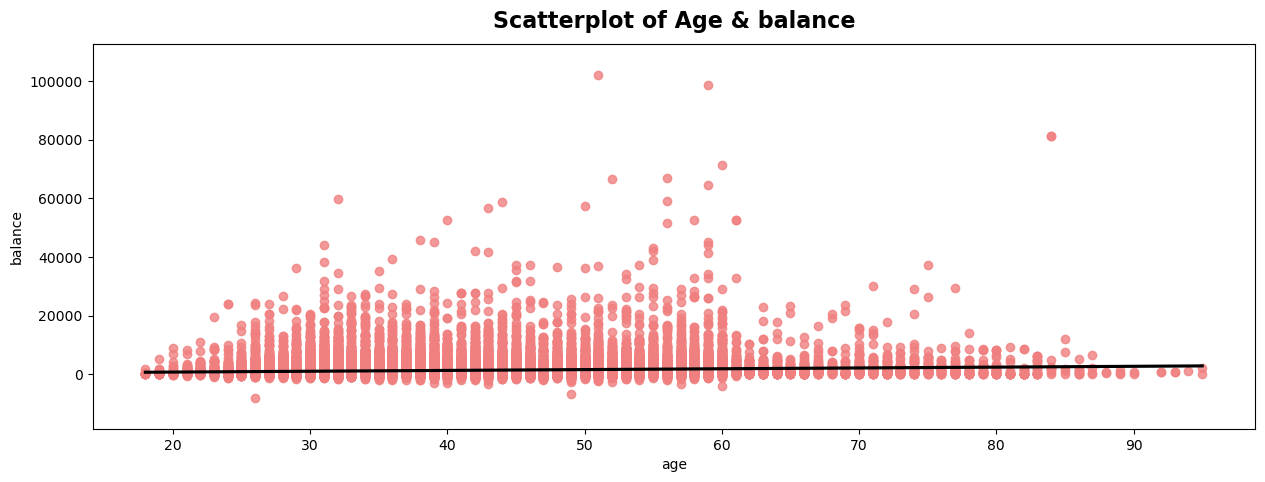

In [406]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.regplot(data=data, x='age', y='balance', color='lightcoral', line_kws={"color":"k"}, ax=ax)

bottom, top = ax.get_ylim()
ax.set_ylim(bottom-5000, top + 5000)
ax.set_title("Scatterplot of Age & balance", fontsize=16, fontweight='bold', y=1.02)

plt.show()

__Insight :__

- The dataset likely has balances centered around zero (many negative and positive values).

- balance is independent of age in this linear fit.

**Housing**

In [407]:
display_md("**Housing distribution Summary:**")
display_md(f"**Number of clients with housing loan :** {data['housing'].value_counts().get('yes', 0)}")
display_md(f"**Number of clients without housing loan :** {data['housing'].value_counts().get('no', 0)}")

**Housing distribution Summary:**

**Number of clients with housing loan :** 25130

**Number of clients without housing loan :** 20081

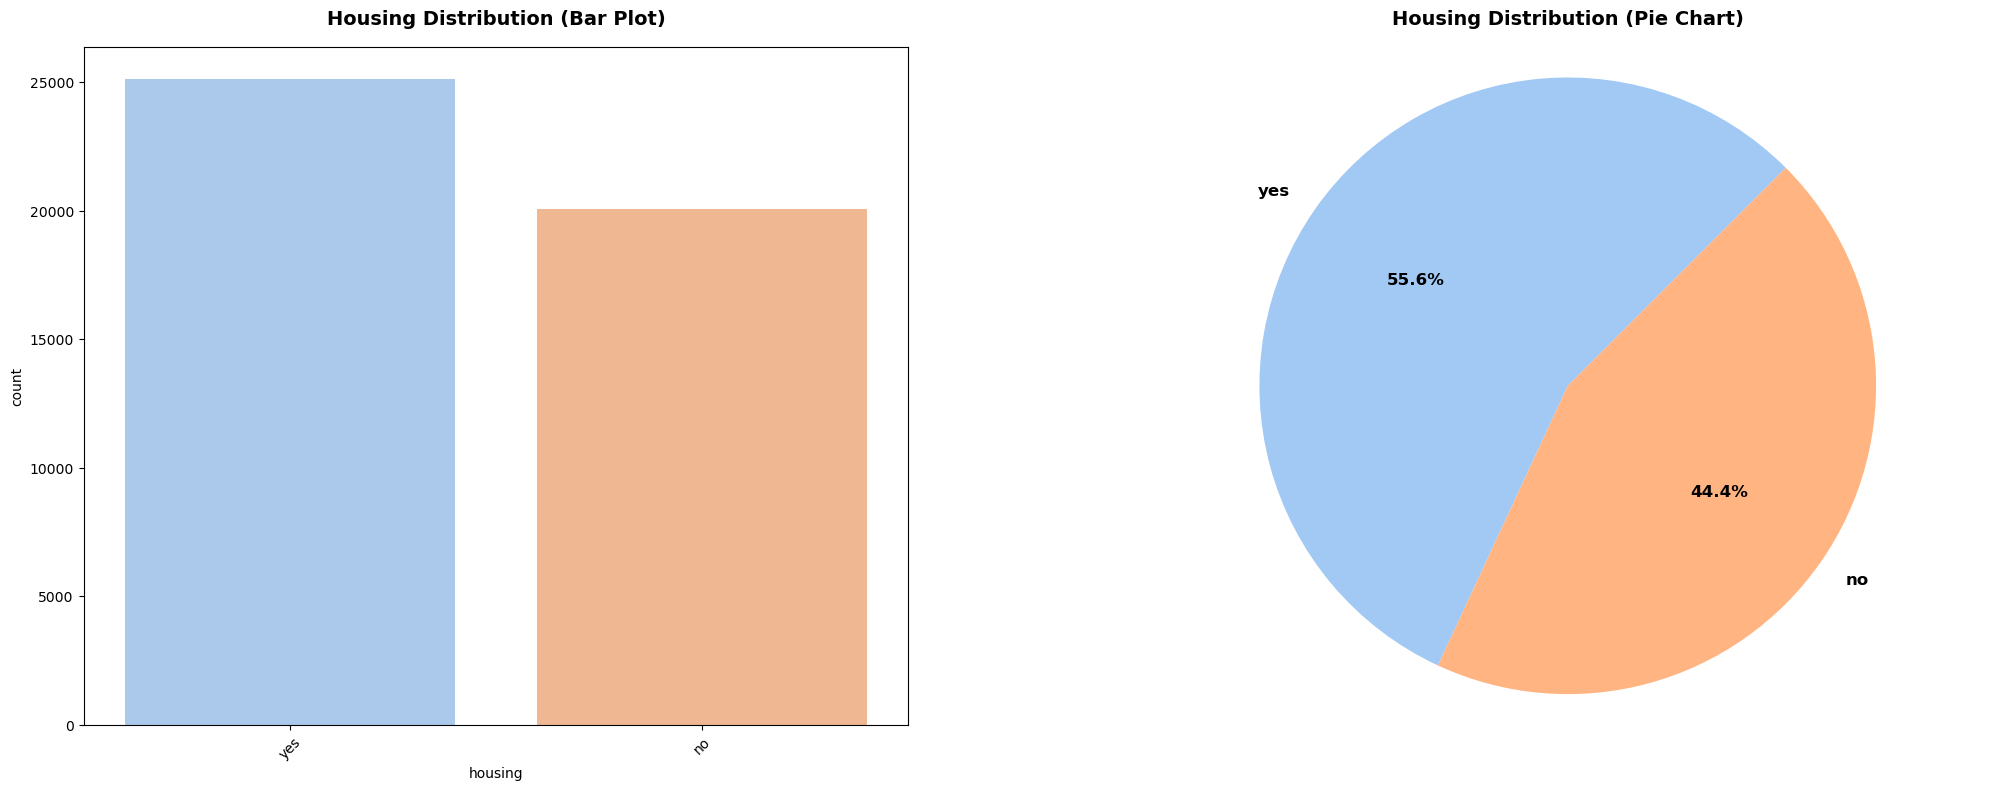

In [408]:
univariate_categorical_distribution(data, 'housing')

,housing,term_deposit,count
0,no,no,16727
1,no,yes,3354
2,yes,no,23195
3,yes,yes,1935


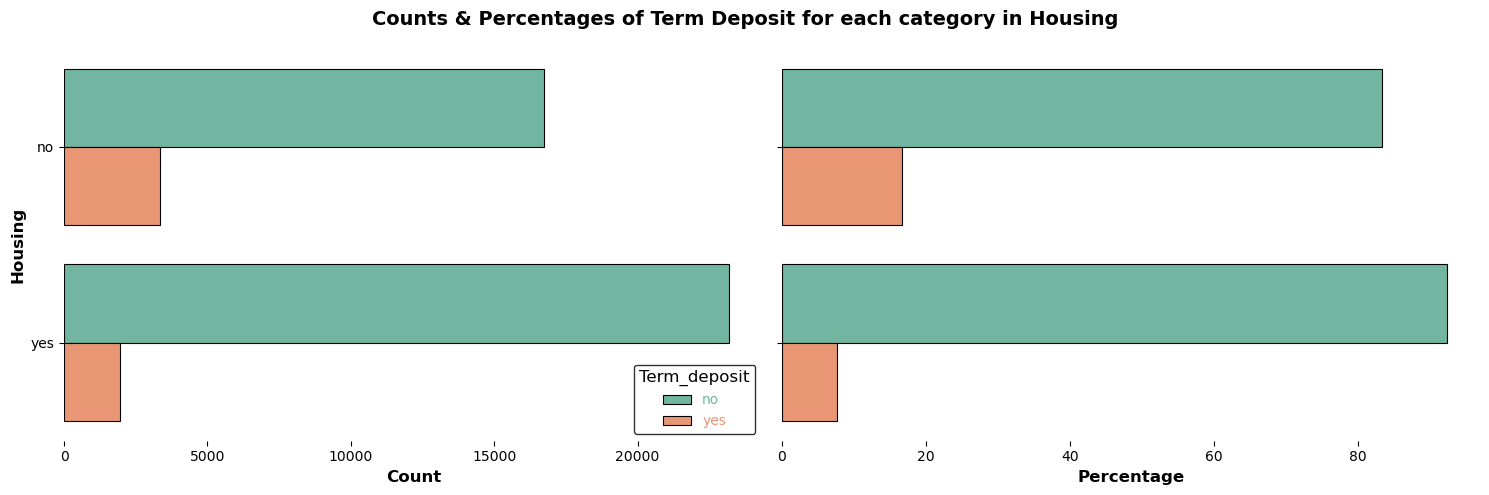

In [409]:
plot_categorical_columns(data, 'housing')

**Loan**

In [410]:
display_md("**Personal Loan distribution Summary:**")
display_md(f"**Number of clients with personal loan :** {data['loan'].value_counts().get('yes', 0)}")
display_md(f"**Number of clients without personal loan :** {data['loan'].value_counts().get('no', 0)}")

**Personal Loan distribution Summary:**

**Number of clients with personal loan :** 7244

**Number of clients without personal loan :** 37967

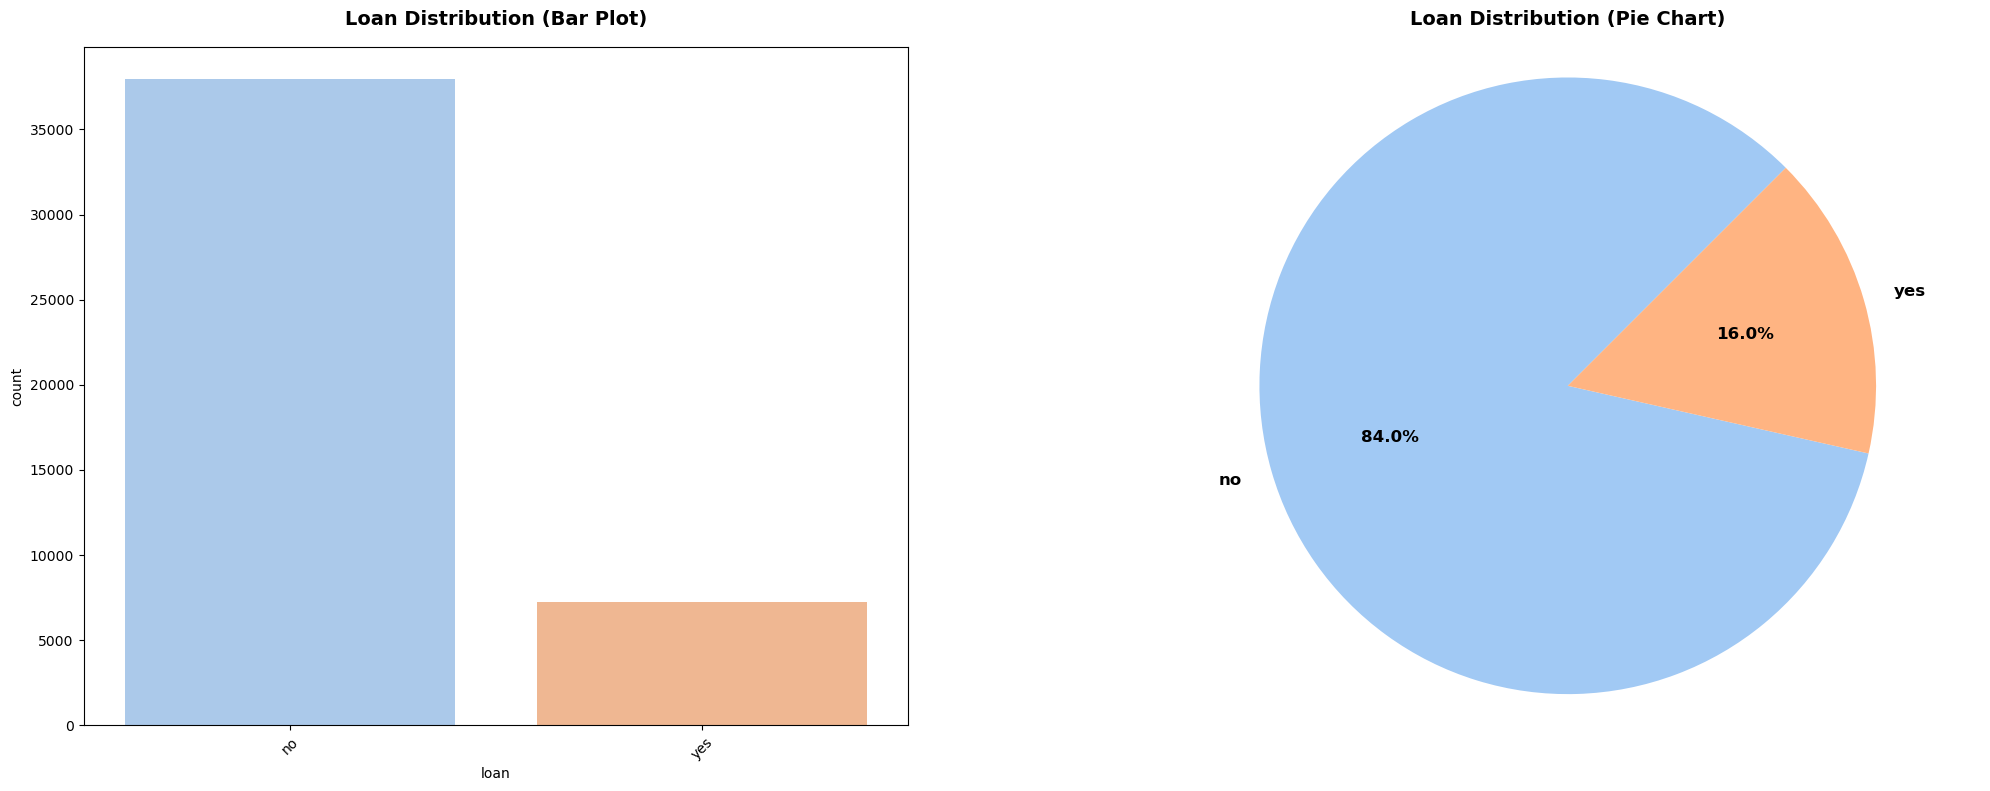

In [411]:
univariate_categorical_distribution(data, 'loan')

,loan,term_deposit,count
0,no,no,33162
1,no,yes,4805
2,yes,no,6760
3,yes,yes,484


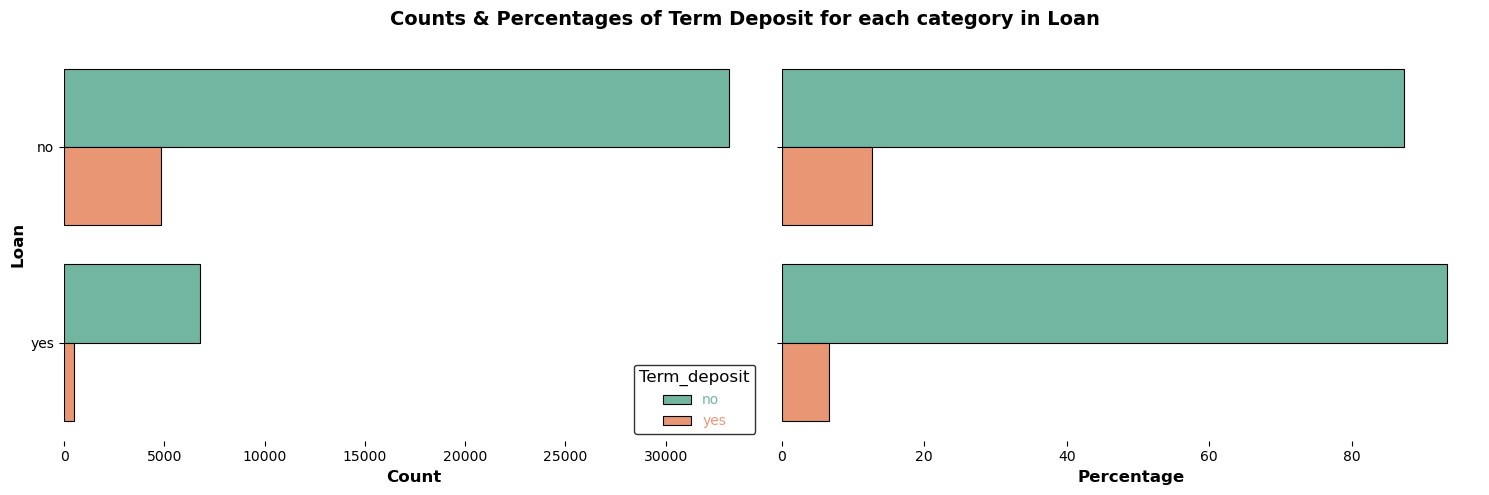

In [412]:
plot_categorical_columns(data, column='loan')

### **3.3. Campaign Details**

- **duration**: Last call duration (seconds).
- **campaign**: shows engagement with marketing efforts indicating responsivness.
- **pdays**:  indicates the number of days since the last contact, reflecting the recency of customer interaction.
- **previous**: number of previous contacts, indicating the customer's history with the bank.
- **poutcome**: outcome of the previous marketing campaign, indicating the effectiveness of past interactions.
- **contact**: Communication type (cellular/telephone).
- **day, month**: Last contact date.


**Duration**

In [413]:
duration_values = data['duration'].value_counts()[:10]
display_md(f"**Distribution of the duration of the last contact :**")
display(duration_values)

# Get basic statistics
display_md("**Duration Statistics:**")
display(data['duration'].describe())


**Distribution of the duration of the last contact :**

duration
124    188
90     184
89     177
104    175
122    175
114    175
136    174
139    174
112    174
121    173
Name: count, dtype: int64

**Duration Statistics:**

count   45211.00
mean      258.16
std       257.53
min         0.00
25%       103.00
50%       180.00
75%       319.00
max      4918.00
Name: duration, dtype: float64

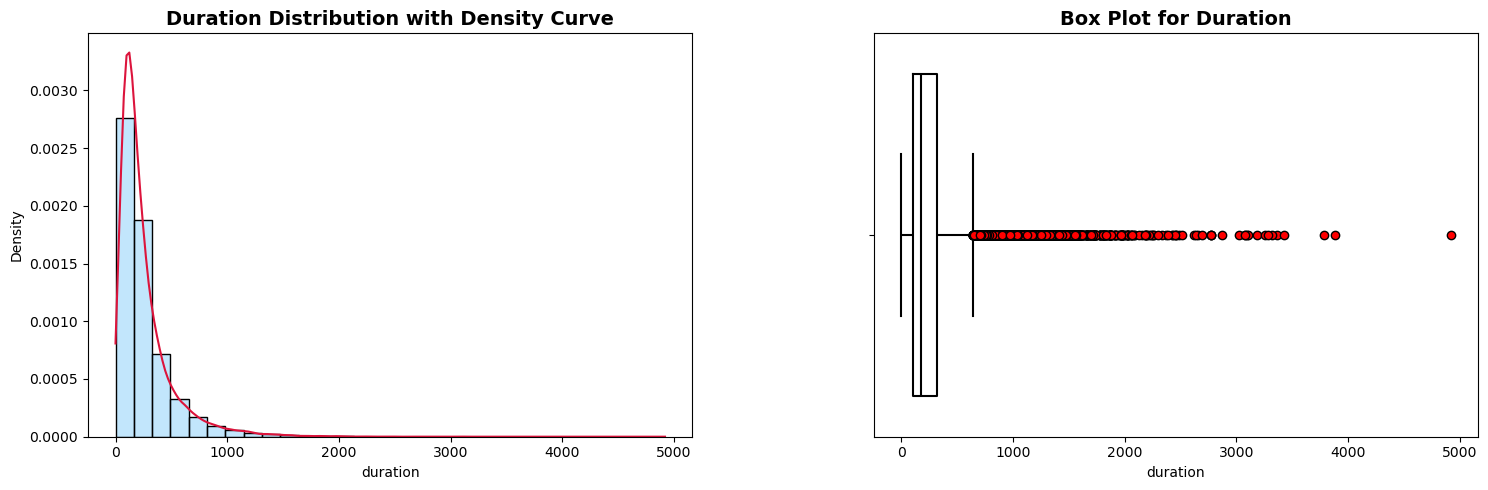

In [414]:
univariate_numeric_distribution(data, 'duration')

In [415]:
# Create duration categories
def categorize_duration(duration):
    if duration == 0:
        return 'No Contact (0 sec)'
    elif duration <= 60:
        return 'Very Short (1-60 sec)'
    elif duration <= 180:
        return 'Short (61-180 sec)'
    elif duration <= 300:
        return 'Medium (181-300 sec)'
    elif duration <= 600:
        return 'Long (301-600 sec)'
    else:
        return 'Very Long (600+ sec)'

data['duration_category'] = data['duration'].apply(categorize_duration)

# Count and percentage analysis
duration_counts = data['duration_category'].value_counts()
duration_percentages = data['duration_category'].value_counts(normalize=True) * 100

print("Duration Categories Distribution:")
for category in duration_counts.index:
    print(f"{category} : {duration_counts[category]} ({duration_percentages[category]:0.3}%)")
    

Duration Categories Distribution:
Short (61-180 sec) : 17894 (39.6%)
Medium (181-300 sec) : 10277 (22.7%)
Long (301-600 sec) : 8484 (18.8%)
Very Short (1-60 sec) : 4763 (10.5%)
Very Long (600+ sec) : 3790 (8.38%)
No Contact (0 sec) : 3 (0.00664%)


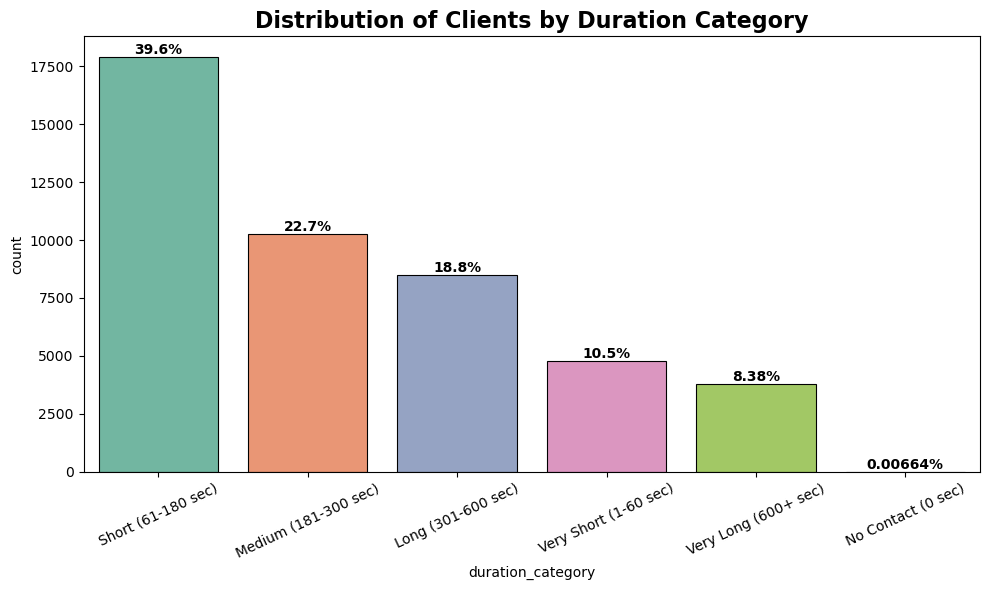

In [416]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=data, x='duration_category', order=duration_counts.index, palette='Set2', edgecolor='black', linewidth=0.8, ax=ax)

# Add labels to each bar
for idx, row in duration_counts.items():
    ax.text(idx, row, f"{duration_percentages[idx]:0.3}%", color='black', ha="center", va="bottom", fontsize=10, fontweight='bold')
ax.set_title('Distribution of Clients by Duration Category', fontsize=16, fontweight='bold')
ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

**Duration by Campaign Outcome :**

,mean,median,count
term_deposit,,,
no,221.18,164.00,39922
yes,537.29,426.00,5289


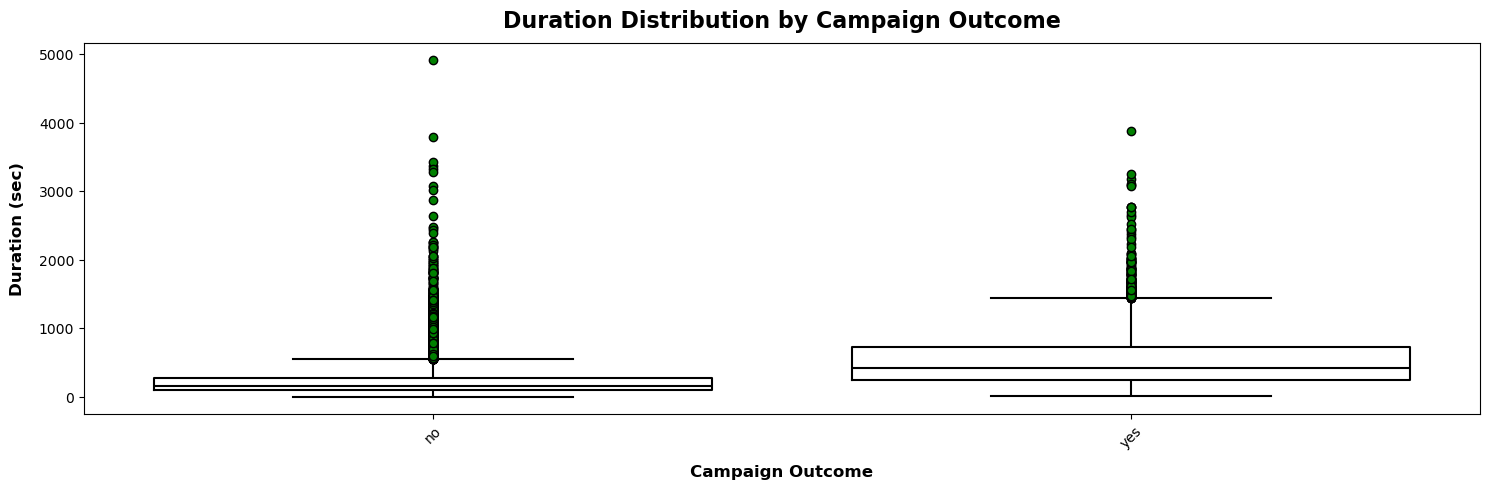

In [417]:
# Statistical comparison
display_md("**Duration by Campaign Outcome :**")
duration_by_outcome = data.groupby('term_deposit')['duration'].agg(['mean', 'median', 'count']).round(2)
display(duration_by_outcome)
print()

# Analyze duration by campaign outcome
plt.figure(figsize=(15, 5))
sns.boxplot(data=data, x='term_deposit', y='duration', fill=False, color='k', flierprops={'marker':'o', 'markerfacecolor':'g'})
plt.title('Duration Distribution by Campaign Outcome', fontsize=16, fontweight='bold', y=1.02)
plt.xlabel('Campaign Outcome', labelpad=10, fontsize=12, fontweight='bold')
plt.ylabel('Duration (sec)', labelpad=10, fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

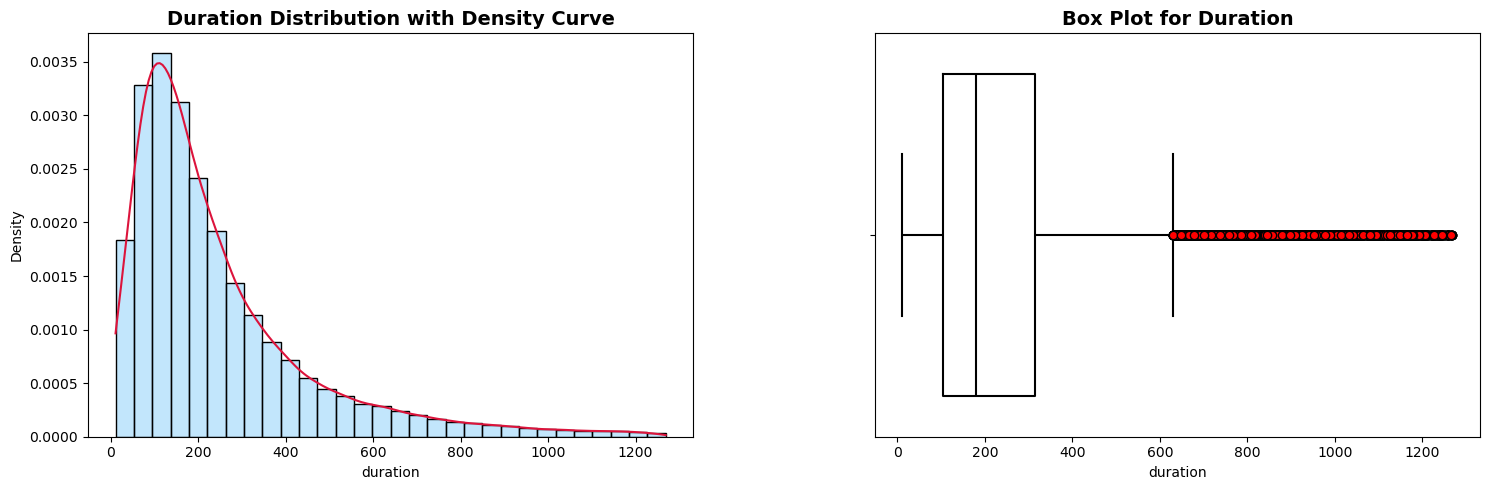

In [418]:
# Remove extreme outliers for better visualization
low, high = np.percentile(data['duration'], [1, 99])
duration_filtered = data[data['duration'].between(low, high)]

univariate_numeric_distribution(duration_filtered, 'duration')


In [419]:
# Percentile breakdown
percentiles = [10, 25, 50, 75, 90, 95, 99]
display_md("**Duration Percentiles :**")
for p in percentiles:
    value = np.percentile(data['duration'], p)
    print(f"{p}th Percentile : {value:.0f} ({value/60:.1f} minutes)")


**Duration Percentiles :**

10th Percentile : 58 (1.0 minutes)
25th Percentile : 103 (1.7 minutes)
50th Percentile : 180 (3.0 minutes)
75th Percentile : 319 (5.3 minutes)
90th Percentile : 548 (9.1 minutes)
95th Percentile : 751 (12.5 minutes)
99th Percentile : 1269 (21.1 minutes)


**Campaign**

**How the percentage of subscribers of term deposits varies with the campaign attempts**

In [420]:
display_md("**Number of Contacts Distribution :**")
display(data['campaign'].value_counts()[:10])

display_md("**Campaign Statistics Summary :**")
display(data['campaign'].describe())

**Number of Contacts Distribution :**

campaign
1     17544
2     12505
3      5521
4      3522
5      1764
6      1291
7       735
8       540
9       327
10      266
Name: count, dtype: int64

**Campaign Statistics Summary :**

count   45211.00
mean        2.76
std         3.10
min         1.00
25%         1.00
50%         2.00
75%         3.00
max        63.00
Name: campaign, dtype: float64

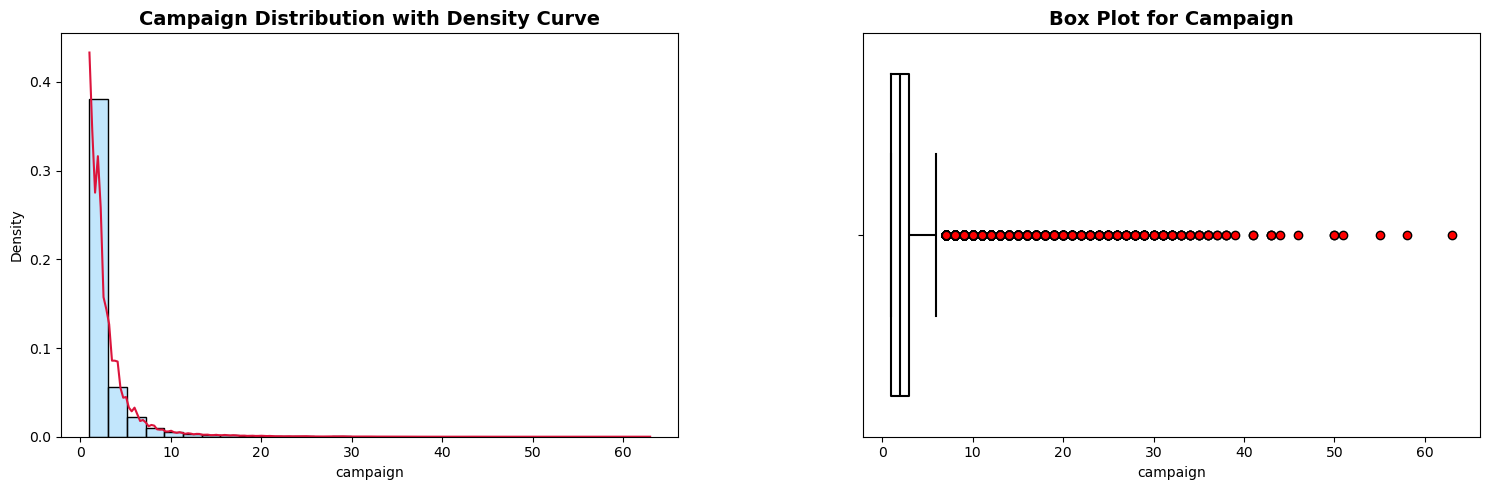

In [421]:
univariate_numeric_distribution(data, 'campaign')

In [422]:
# Percentile Analysis
percentiles = [10, 25, 50, 75, 90, 95, 99]
display_md("**Campaign Percentiles :**")
for p in percentiles:
    value = np.percentile(data['campaign'], p)
    print(f"{p}th Percentile : {value:.0f} contacts")


**Campaign Percentiles :**

10th Percentile : 1 contacts
25th Percentile : 1 contacts
50th Percentile : 2 contacts
75th Percentile : 3 contacts
90th Percentile : 5 contacts
95th Percentile : 8 contacts
99th Percentile : 16 contacts


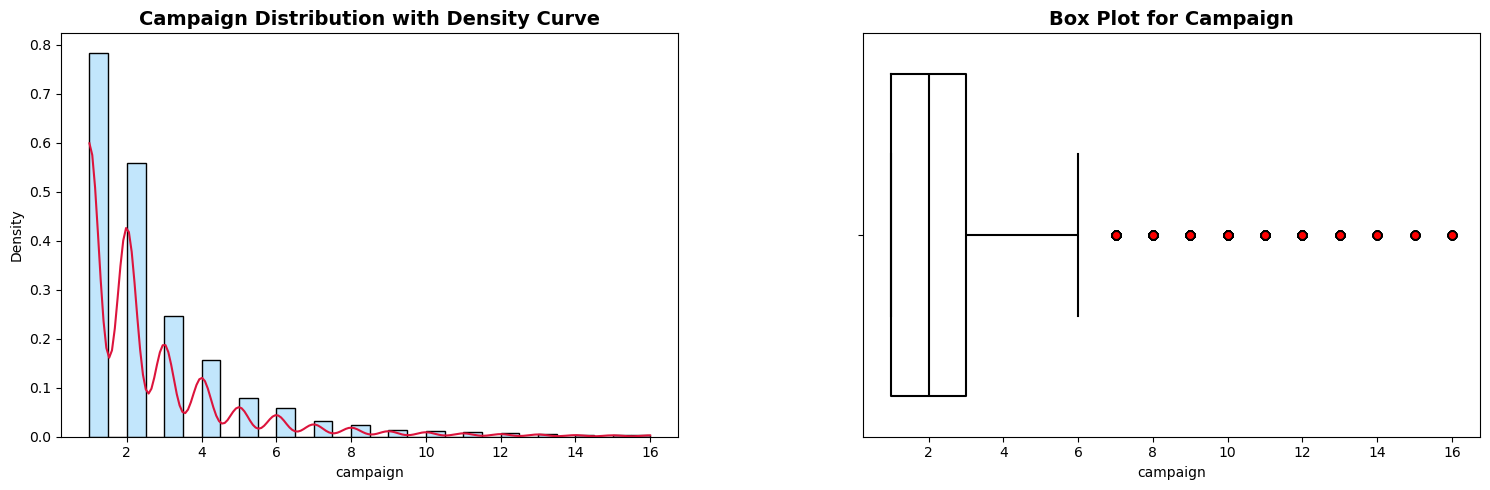

In [423]:
# Remove extreme outliers for better visualization
low, high = np.percentile(data['campaign'], [1, 99])
campaign_filtered = data[data['campaign'].between(low, high)]

univariate_numeric_distribution(campaign_filtered, 'campaign')


In [424]:
# Create contact frequency categories
def categorize_contacts(contacts):
    if contacts == 1:
        return 'Single Contact'
    elif contacts == 2:
        return '2 Contacts'
    elif contacts <= 5:
        return '3-5 Contacts'
    elif contacts <= 10:
        return '6-10 Contacts'
    else:
        return '10+ Contacts'

data['contact_frequency_category'] = data['campaign'].apply(categorize_contacts)

# Count and percentage analysis
contact_freq_counts = data['contact_frequency_category'].value_counts()
contact_freq_percentages = data['contact_frequency_category'].value_counts(normalize=True) * 100

print("Contact Frequency Categories:")
for category in contact_freq_counts.index:
    print(f"{category}: {contact_freq_counts[category]} ({contact_freq_percentages[category]:.1f}%)")


Contact Frequency Categories:
Single Contact: 17544 (38.8%)
2 Contacts: 12505 (27.7%)
3-5 Contacts: 10807 (23.9%)
6-10 Contacts: 3159 (7.0%)
10+ Contacts: 1196 (2.6%)


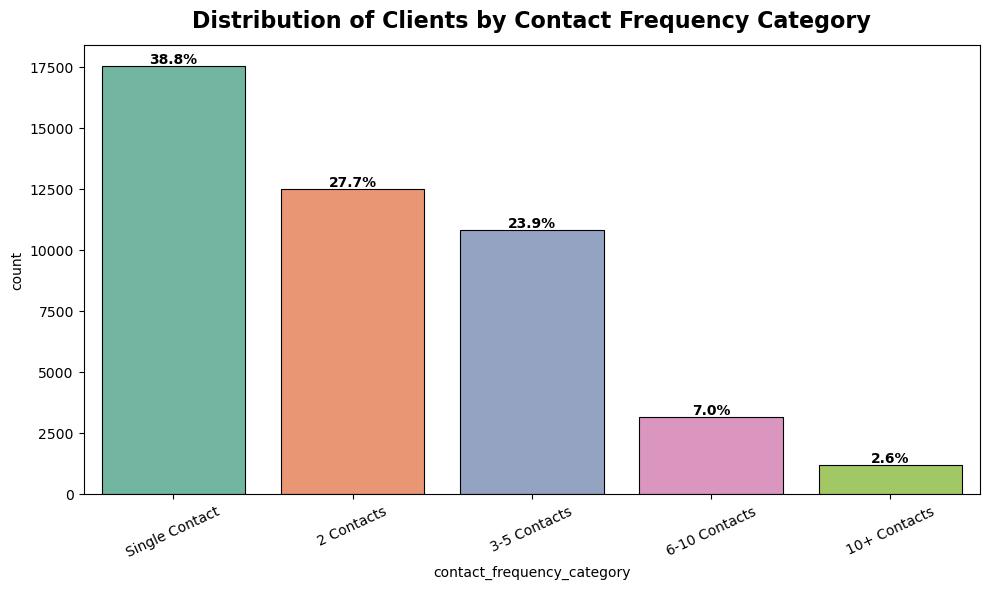

In [425]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=data, x='contact_frequency_category', order=contact_freq_counts.index, palette='Set2', edgecolor='black', linewidth=0.8, ax=ax)

# Add labels to each bar
for idx, row in contact_freq_counts.items():
    ax.text(idx, row, f"{contact_freq_percentages[idx]:.1f}%", color='black', ha="center", va="bottom", fontsize=10, fontweight='bold')
ax.set_title('Distribution of Clients by Contact Frequency Category', fontsize=16, fontweight='bold', y=1.02)
ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()


In [426]:
# Analyze success rate by number of contacts
success_by_contacts = data.groupby('campaign')['term_deposit'].apply(lambda x: (x == 'yes').mean() * 100)

display_md("**Success Rate by Number of Contacts :**")
for contacts, success_rate in success_by_contacts[:10].items():
    client_count = (data['campaign'] == contacts).sum()
    print(f"{contacts} contact(s): {success_rate:.1f}% success rate ({client_count:,} clients)")


**Success Rate by Number of Contacts :**

1 contact(s): 14.6% success rate (17,544 clients)
2 contact(s): 11.2% success rate (12,505 clients)
3 contact(s): 11.2% success rate (5,521 clients)
4 contact(s): 9.0% success rate (3,522 clients)
5 contact(s): 7.9% success rate (1,764 clients)
6 contact(s): 7.1% success rate (1,291 clients)
7 contact(s): 6.4% success rate (735 clients)
8 contact(s): 5.9% success rate (540 clients)
9 contact(s): 6.4% success rate (327 clients)
10 contact(s): 5.3% success rate (266 clients)


term_deposit,no,yes,total,success_rate
campaign,,,,
1,14983.00,2561.00,17544.00,14.60
2,11104.00,1401.00,12505.00,11.20
3,4903.00,618.00,5521.00,11.19
4,3205.00,317.00,3522.00,9.00
5,1625.00,139.00,1764.00,7.88
6,1199.00,92.00,1291.00,7.13
7,688.00,47.00,735.00,6.39
8,508.00,32.00,540.00,5.93
9,306.00,21.00,327.00,6.42


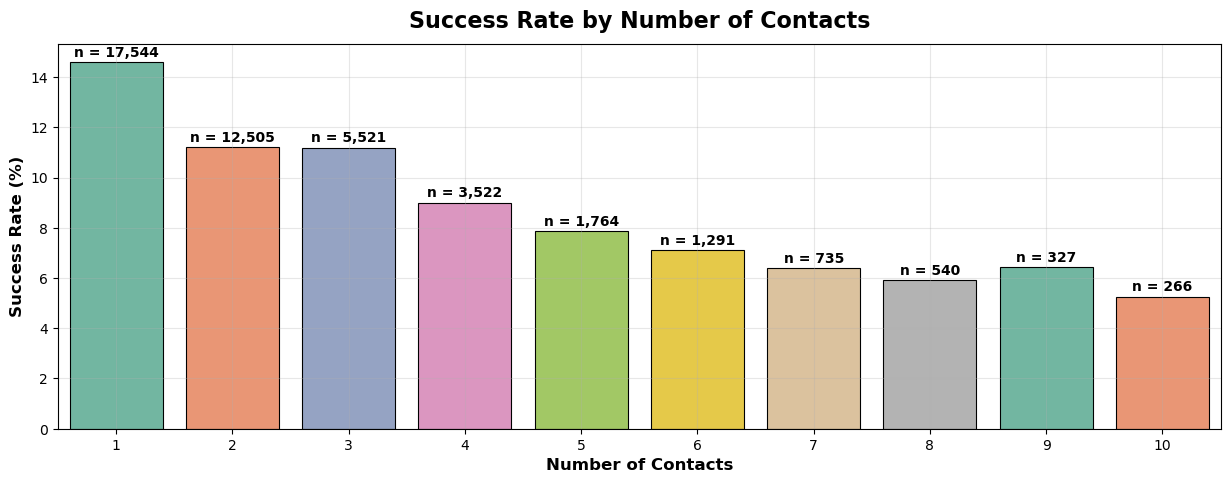

In [427]:
# Plot success rate by contact frequency
success_by_contacts_counts = data.groupby('campaign')['term_deposit'].value_counts().unstack().fillna(0).assign(total=lambda x: x.sum(axis=1), success_rate=lambda x: (x['yes'] / x['total']) * 100).sort_values(by='success_rate', ascending=False).sort_index()[:10]
display(success_by_contacts_counts)

# Create bar plot
plt.figure(figsize=(15, 5))
sns.barplot(x=success_by_contacts_counts.index, y=success_by_contacts_counts['success_rate'], palette='Set2', edgecolor='black', linewidth=0.8)

# Add client count labels on bars
for i, (contacts, row) in enumerate(success_by_contacts_counts.iterrows()):
    plt.text(i, row['success_rate'] + 0.1, f"n = {int(row['total']):,}", ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.title('Success Rate by Number of Contacts', fontsize=16, fontweight='bold', y=1.02)
plt.xlabel('Number of Contacts', fontsize=12, fontweight='bold')
plt.ylabel('Success Rate (%)', fontsize=12, fontweight='bold')

plt.grid(True, alpha=0.3)
plt.show()


In [428]:
# Create cross-tabulation
contact_outcome_crosstab = pd.crosstab(data['contact_frequency_category'], data['term_deposit'], margins=True, normalize='index')
display_md("**Success Rate by Contact Frequency Category :**")
display(contact_outcome_crosstab.round(3))


**Success Rate by Contact Frequency Category :**

term_deposit,no,yes
contact_frequency_category,,
10+ Contacts,0.96,0.04
2 Contacts,0.89,0.11
3-5 Contacts,0.90,0.10
6-10 Contacts,0.94,0.07
Single Contact,0.85,0.15
All,0.88,0.12


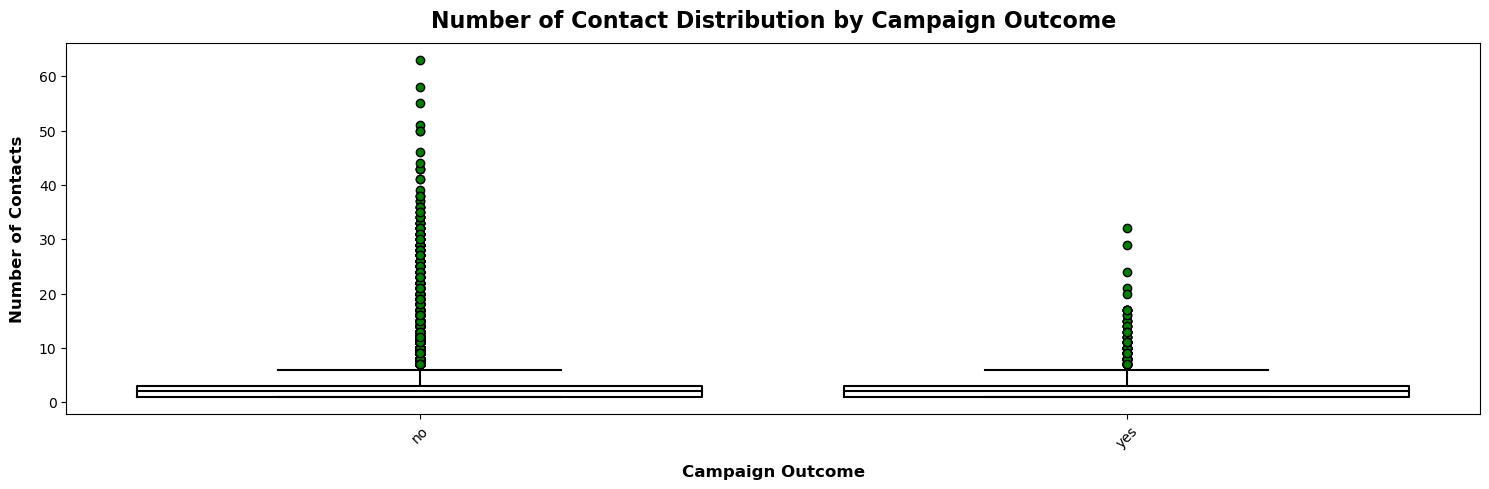

In [429]:
# Analyze last contact by campaign outcome
plt.figure(figsize=(15, 5))
sns.boxplot(data=data, x='term_deposit', y='campaign', fill=False, color='k', flierprops={'marker':'o', 'markerfacecolor':'g'})
plt.title('Number of Contact Distribution by Campaign Outcome', fontsize=16, fontweight='bold', y=1.02)
plt.xlabel('Campaign Outcome', labelpad=10, fontsize=12, fontweight='bold')
plt.ylabel('Number of Contacts', labelpad=10, fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [430]:
# Find the optimal number of contacts
optimal_analysis = data.groupby('campaign').agg({
    'term_deposit': [('total_clients', 'count'), 
          ('success', lambda x: (x == 'yes').sum()),
          ('success_rate', lambda x: (x == 'yes').mean() * 100)]
}).round(2)

optimal_analysis.columns = ['total_clients', 'success', 'success_rate']
optimal_analysis = optimal_analysis[optimal_analysis['total_clients'] >= 50]  # Filter for significant sample sizes

display_md("**Optimal Contact Analysis (minimum 50 clients per group) :**")
print(optimal_analysis.head(10))

# Find the sweet spot
best_contact_num = optimal_analysis['success_rate'].idxmax()
best_success_rate = optimal_analysis['success_rate'].max()
display_md(f"**Optimal number of contacts:** {best_contact_num} (Success rate: {best_success_rate:.1f}%)")


**Optimal Contact Analysis (minimum 50 clients per group) :**

          total_clients  success  success_rate
campaign                                      
1                 17544     2561         14.60
2                 12505     1401         11.20
3                  5521      618         11.19
4                  3522      317          9.00
5                  1764      139          7.88
6                  1291       92          7.13
7                   735       47          6.39
8                   540       32          5.93
9                   327       21          6.42
10                  266       14          5.26


**Optimal number of contacts:** 1 (Success rate: 14.6%)

term_deposit,no,yes,pct_success
campaign,,,
1,14983,2561,14.60
2,11104,1401,11.20
3,4903,618,11.19
4,3205,317,9.00
5,1625,139,7.88
6,1199,92,7.13
7,688,47,6.39
8,508,32,5.93
9,306,21,6.42


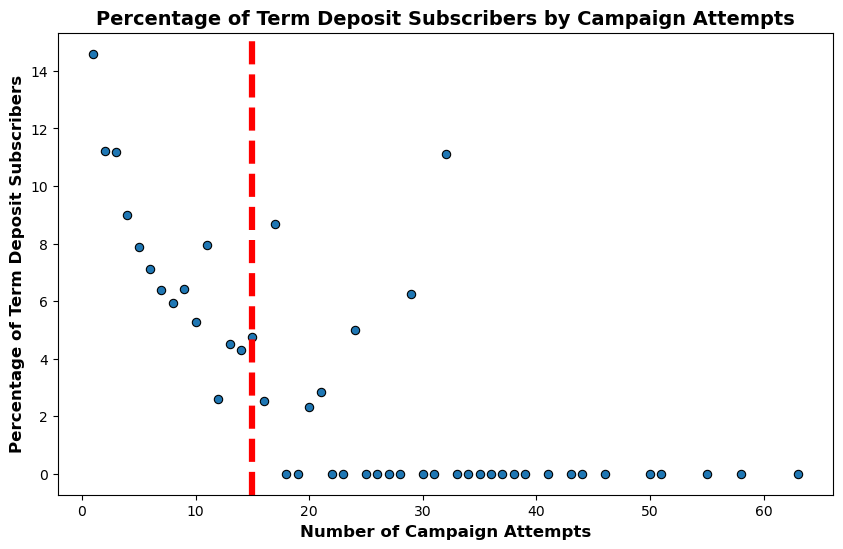

In [431]:
campaign_counts = pd.crosstab(data['campaign'], data['term_deposit'])
campaign_counts['pct_success'] = ((campaign_counts['yes']/(campaign_counts['no'] + campaign_counts['yes'])))*100
display(campaign_counts.head(10))

# plot scatter plot for campaign attempts and percentage of term deposit subscribers
plt.figure(figsize=(10,6))
sns.scatterplot(data=campaign_counts, x='campaign', y='pct_success', palette='Set2', edgecolor='black', linewidth=0.8)
plt.axvline(x=15, color='red', linestyle='--', linewidth=4.5)
plt.xlabel('Number of Campaign Attempts', fontsize=12, fontweight='bold')
plt.ylabel('Percentage of Term Deposit Subscribers', fontsize=12, fontweight='bold')
plt.title('Percentage of Term Deposit Subscribers by Campaign Attempts', fontsize=14, fontweight='bold')
plt.show()

**Insight**

- Analysis shows that when the number of campaign contacts exceeds 10, the likelihood of converting customers to term deposits drops significantly. In other words, attempts beyond 10 are rarely effective.

**Pdays**

In [432]:
display_md("**Days since last contact distribution Summary :**")
last_contact_counts = data['pdays'].value_counts()
display(last_contact_counts[:10])

**Days since last contact distribution Summary :**

pdays
-1      36954
 182      167
 92       147
 91       126
 183      126
 181      117
 370       99
 184       85
 364       77
 95        74
Name: count, dtype: int64

In [433]:
display_md("**Analyzing special values:**")
print(f"Clients never contacted before (pdays = -1) : {last_contact_counts.get(-1, 0)} ({last_contact_counts.get(-1, 0)/len(data)*100:.1f}%)")

# Create a clean dataset for previously contacted clients
data_previously_contacted = data[data['pdays'] > 0].copy()
print(f"\nClients with previous contact history: {len(data_previously_contacted):,} ({len(data_previously_contacted)/len(data)*100:.1f}%)")


**Analyzing special values:**

Clients never contacted before (pdays = -1) : 36954 (81.7%)

Clients with previous contact history: 8,257 (18.3%)


In [434]:
# Statistics for all data
display_md("**Complete Dataset Statistics (including special values) :**")
print(data['pdays'].describe(), end="\n\n")

# Statistics for previously contacted clients only
if len(data_previously_contacted) > 0:
    display_md(f"**Previously Contacted Clients Only n :** {len(data_previously_contacted):,}")
    print(data_previously_contacted['pdays'].describe())
    
    # Convert to more meaningful time units
    display_md(f"**Time Since Last Contact (Previously Contacted Clients) :**")
    print(f"Minimum: {data_previously_contacted['pdays'].min():.0f} days ({data_previously_contacted['pdays'].min()/7:.1f} days)")
    print(f"Average: {data_previously_contacted['pdays'].mean():.1f} days ({data_previously_contacted['pdays'].mean()/30:.1f} months)")
    print(f"Median: {data_previously_contacted['pdays'].median():.0f} days ({data_previously_contacted['pdays'].median()/30:.1f} months)")
    print(f"Maximum: {data_previously_contacted['pdays'].max():.0f} days ({data_previously_contacted['pdays'].max()/365:.1f} years)")


**Complete Dataset Statistics (including special values) :**

count   45211.00
mean       40.20
std       100.13
min        -1.00
25%        -1.00
50%        -1.00
75%        -1.00
max       871.00
Name: pdays, dtype: float64



**Previously Contacted Clients Only n :** 8,257

count   8257.00
mean     224.58
std      115.34
min        1.00
25%      133.00
50%      194.00
75%      327.00
max      871.00
Name: pdays, dtype: float64


**Time Since Last Contact (Previously Contacted Clients) :**

Minimum: 1 days (0.1 days)
Average: 224.6 days (7.5 months)
Median: 194 days (6.5 months)
Maximum: 871 days (2.4 years)


In [435]:
# Categorize clients based on previous contact history

def categorize_pdays(pdays):
    if pdays <= 0:  # -1 or 0 typically means never contacted
        return 'Never Contacted'
    elif pdays <= 30:
        return 'Recent (≤30 days)'
    elif pdays <= 90:
        return 'Within 3 months (31-90 days)'
    elif pdays <= 180:
        return 'Within 6 months (91-180 days)'
    elif pdays <= 365:
        return 'Within 1 year (181-365 days)'
    else:
        return 'Over 1 year (365+ days)'

data['pdays_category'] = data['pdays'].apply(categorize_pdays)

# Count and percentage analysis
pdays_counts = data['pdays_category'].value_counts()
pdays_percentages = data['pdays_category'].value_counts(normalize=True) * 100

print("Previous Contact History Distribution:")
for category in pdays_counts.index:
    print(f"{category}: {pdays_counts[category]} ({pdays_percentages[category]:.1f}%)")
    

Previous Contact History Distribution:
Never Contacted: 36954 (81.7%)
Within 1 year (181-365 days): 4416 (9.8%)
Within 6 months (91-180 days): 2480 (5.5%)
Over 1 year (365+ days): 643 (1.4%)
Within 3 months (31-90 days): 530 (1.2%)
Recent (≤30 days): 188 (0.4%)


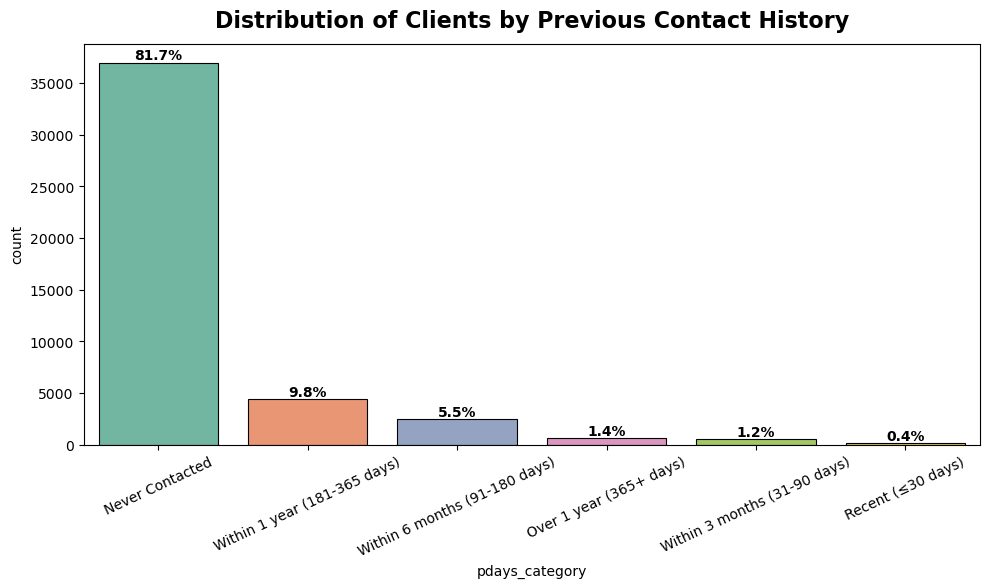

In [436]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=data, x='pdays_category', order=pdays_counts.index, palette='Set2', edgecolor='black', linewidth=0.8, ax=ax)

# Add labels to each bar
for idx, row in pdays_counts.items():
    ax.text(idx, row, f"{pdays_percentages[idx]:.1f}%", color='black', ha="center", va="bottom", fontsize=10, fontweight='bold')
ax.set_title('Distribution of Clients by Previous Contact History', fontsize=16, fontweight='bold', y=1.02)
ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()


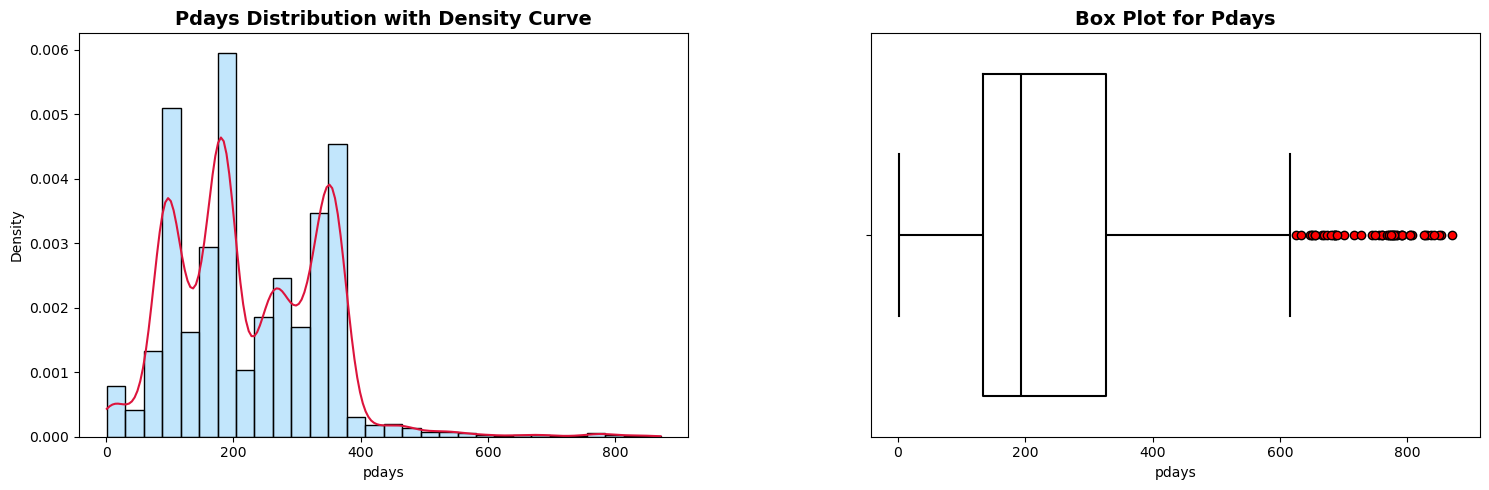

In [437]:
if len(data_previously_contacted) > 0:
    univariate_numeric_distribution(data_previously_contacted, 'pdays')

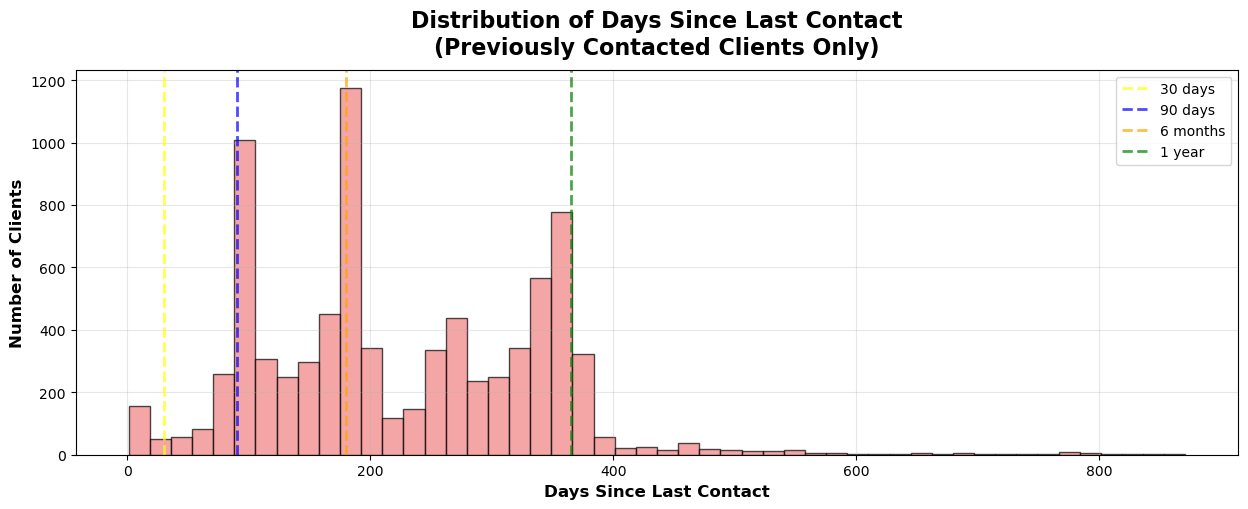

In [438]:
# Histogram for clients with previous contact history (excluding never contacted)

if len(data_previously_contacted) > 0:
    plt.figure(figsize=(15, 5))
    plt.hist(data_previously_contacted['pdays'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
    plt.title('Distribution of Days Since Last Contact\n(Previously Contacted Clients Only)', fontsize=16, fontweight='bold', y=1.02)
    plt.xlabel('Days Since Last Contact', fontsize=12, fontweight='bold')
    plt.ylabel('Number of Clients', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Add vertical lines for key time periods
    plt.axvline(x=30, color='yellow', linewidth=2, linestyle='--', alpha=0.7, label='30 days')
    plt.axvline(x=90, color='blue', linewidth=2, linestyle='--', alpha=0.7, label='90 days')
    plt.axvline(x=180, color='orange', linewidth=2, linestyle='--', alpha=0.7, label='6 months')
    plt.axvline(x=365, color='green', linewidth=2, linestyle='--', alpha=0.7, label='1 year')
    plt.legend()
    plt.show()


In [439]:
# Analyze campaign success by previous contact history
success_by_contacts = data.groupby('pdays_category')['term_deposit'].apply(lambda x: (x == 'yes').mean() * 100)

display_md("**Success Rate by Previous Contact History :**")
for contacts, success_rate in success_by_contacts.items():
    client_count = (data['pdays_category'] == contacts).sum()
    print(f"{contacts} contact(s): {success_rate:.1f}% success rate ({client_count:,} clients)")


**Success Rate by Previous Contact History :**

Never Contacted contact(s): 9.2% success rate (36,954 clients)
Over 1 year (365+ days) contact(s): 29.2% success rate (643 clients)
Recent (≤30 days) contact(s): 14.9% success rate (188 clients)
Within 1 year (181-365 days) contact(s): 17.8% success rate (4,416 clients)
Within 3 months (31-90 days) contact(s): 42.1% success rate (530 clients)
Within 6 months (91-180 days) contact(s): 27.4% success rate (2,480 clients)


term_deposit,no,yes,total,success_rate
pdays_category,,,,
Never Contacted,33570,3384,36954,9.16
Over 1 year (365+ days),455,188,643,29.24
Recent (≤30 days),160,28,188,14.89
Within 1 year (181-365 days),3630,786,4416,17.80
Within 3 months (31-90 days),307,223,530,42.08
Within 6 months (91-180 days),1800,680,2480,27.42


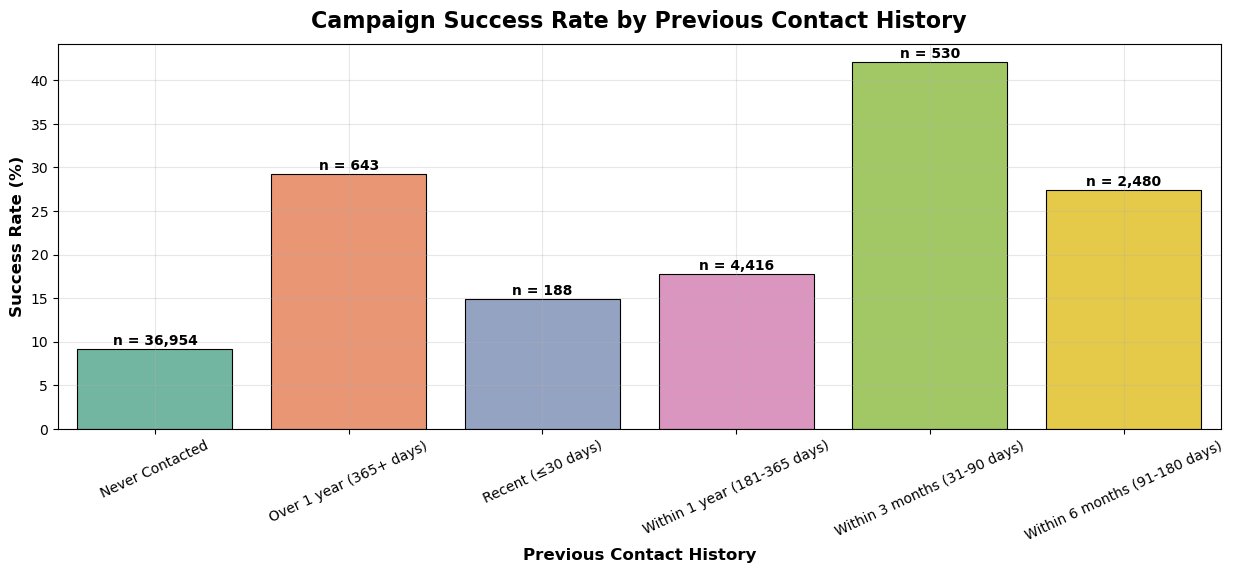

In [440]:
# Plot success rate by previous contact history
success_by_pdays_counts = data.groupby('pdays_category')['term_deposit'].value_counts().unstack().fillna(0).assign(total=lambda x: x.sum(axis=1), success_rate=lambda x: (x['yes'] / x['total']) * 100).sort_values(by='success_rate', ascending=False).sort_index()
display(success_by_pdays_counts)

# Create bar plot
plt.figure(figsize=(15, 5))
sns.barplot(x=success_by_pdays_counts.index, y=success_by_pdays_counts['success_rate'], palette='Set2', edgecolor='black', linewidth=0.8)

# Add client count labels on bars
for i, (pdays, row) in enumerate(success_by_pdays_counts.iterrows()):
    plt.text(i, row['success_rate'] + 0.1, f"n = {int(row['total']):,}", ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.title('Campaign Success Rate by Previous Contact History', fontsize=16, fontweight='bold', y=1.02)
plt.xlabel('Previous Contact History', fontsize=12, fontweight='bold')
plt.ylabel('Success Rate (%)', fontsize=12, fontweight='bold')
plt.xticks(rotation=25)

plt.grid(True, alpha=0.3)
plt.show()

In [441]:
# For previously contacted clients, analyze by specific time periods
if len(data_previously_contacted) > 0:
    # Weekly analysis for first 3 months (0-90 days or 12 weeks)
    weekly_df = []
    for week in range(1, 13): # Weeks 1 to 12
        mask = data_previously_contacted['pdays'].between((week-1)*7 + 1, week*7)
        week_data = data_previously_contacted[mask]
        if not week_data.empty:
            weekly_df.append({
                'Week': week,
                'days_range':f"{(week-1)*7 + 1}-{week*7}",
                'clients': len(week_data),
                'success_rate': (week_data['term_deposit'] == 'yes').mean() * 100
            })

    weekly_df = pd.DataFrame(weekly_df)
    if not weekly_df.empty:
        display_md("**Weekly Success Rate Analysis (First 3 Months) :**")
        display(weekly_df.style.hide(axis='index').format({'success_rate': '{:.2f}%'}))
        

**Weekly Success Rate Analysis (First 3 Months) :**

Week,days_range,clients,success_rate
1,1-7,83,12.05%
2,8-14,65,16.92%
3,15-21,16,18.75%
4,22-28,20,15.00%
5,29-35,22,31.82%
6,36-42,28,32.14%
7,43-49,16,31.25%
8,50-56,24,45.83%
9,57-63,38,36.84%
10,64-70,33,39.39%


In [442]:
# Create detailed cross-tabulation
pdays_outcome_crosstab = pd.crosstab(data['pdays_category'], data['term_deposit'], 
                                    margins=True, normalize='index')
display_md("**Detailed Cross-tabulation (Row Percentages) :**")
display(pdays_outcome_crosstab.round(3))

# Chi-square test for independence
from scipy.stats import chi2_contingency
chi2, p_value, dof, expected = chi2_contingency(pd.crosstab(data['pdays_category'], data['term_deposit']))
display_md("**Chi-square Test for Independence :**")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Significant relationship: {'Yes' if p_value < 0.05 else 'No'}")


**Detailed Cross-tabulation (Row Percentages) :**

term_deposit,no,yes
pdays_category,,
Never Contacted,0.91,0.09
Over 1 year (365+ days),0.71,0.29
Recent (≤30 days),0.85,0.15
Within 1 year (181-365 days),0.82,0.18
Within 3 months (31-90 days),0.58,0.42
Within 6 months (91-180 days),0.73,0.27
All,0.88,0.12


**Chi-square Test for Independence :**

Chi-square statistic: 1650.2364
P-value: 0.0000
Significant relationship: Yes


**Insight :**

- This campaign primarily targeted new customers. The analysis indicates that clients who had not been contacted previously are the least likely to subscribe to a term deposit.

**Previous** : Number of contacts performed before this campaign for this client (numeric)

In [443]:
display_md("**Previous Contact History Summary :**")
display(data['previous'].value_counts()[:10])

print(f"\nBasic Statistics:")
print(data['previous'].describe())

**Previous Contact History Summary :**

previous
0    36954
1     2772
2     2106
3     1142
4      714
5      459
6      277
7      205
8      129
9       92
Name: count, dtype: int64


Basic Statistics:
count   45211.00
mean        0.58
std         2.30
min         0.00
25%         0.00
50%         0.00
75%         0.00
max       275.00
Name: previous, dtype: float64


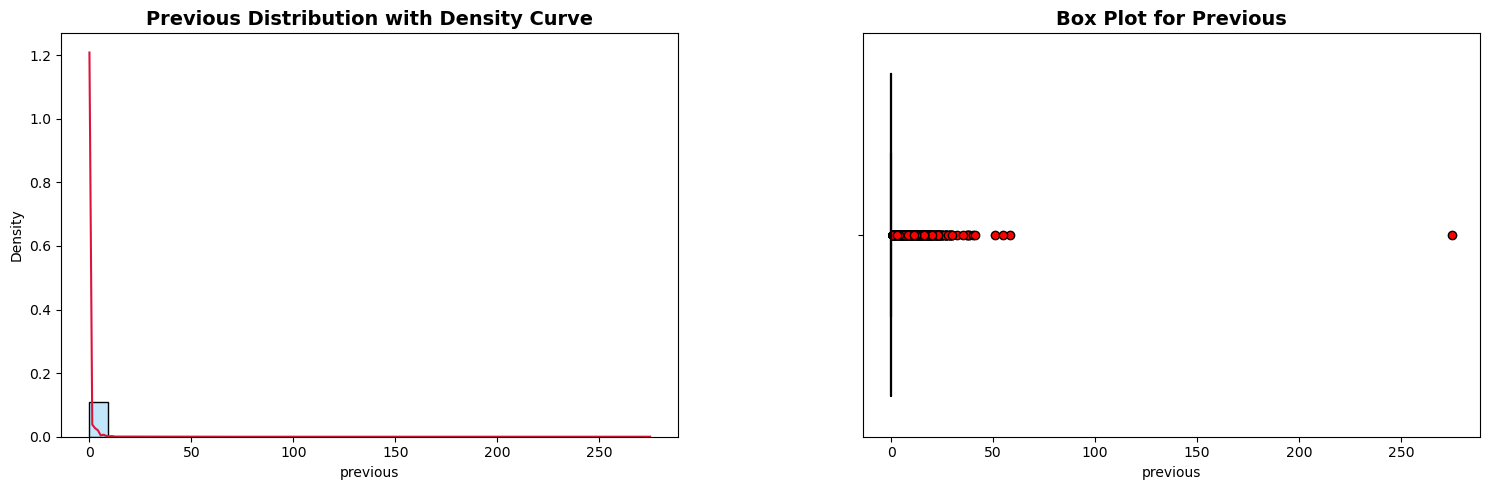

In [444]:
univariate_numeric_distribution(data, 'previous')

In [445]:
# Count frequency of previous contacts
previous_counts = data['previous'].value_counts().sort_index()

display_md("**Distribution of Previous Contacts :**")
print("Previous Contacts | Number of Clients | Percentage")
print("-" * 55)
total_clients = len(data)
for contacts, count in previous_counts.head(15).items():
    percentage = (count / total_clients) * 100
    print(f"{contacts:^17} | {count:^17,} | {percentage:^9.1f}%")

# Summary statistics
display_md("**Key Insights :**")
print(f"Clients with No Previous Contacts: {previous_counts.get(0, 0):,} ({(previous_counts.get(0, 0)/total_clients)*100:.1f}%)")
print(f"Clients with Previous Contacts: {total_clients - previous_counts.get(0, 0):,} ({((total_clients - previous_counts.get(0, 0))/total_clients)*100:.1f}%)")


**Distribution of Previous Contacts :**

Previous Contacts | Number of Clients | Percentage
-------------------------------------------------------
        0         |      36,954       |   81.7   %
        1         |       2,772       |    6.1   %
        2         |       2,106       |    4.7   %
        3         |       1,142       |    2.5   %
        4         |        714        |    1.6   %
        5         |        459        |    1.0   %
        6         |        277        |    0.6   %
        7         |        205        |    0.5   %
        8         |        129        |    0.3   %
        9         |        92         |    0.2   %
       10         |        67         |    0.1   %
       11         |        65         |    0.1   %
       12         |        44         |    0.1   %
       13         |        38         |    0.1   %
       14         |        19         |    0.0   %


**Key Insights :**

Clients with No Previous Contacts: 36,954 (81.7%)
Clients with Previous Contacts: 8,257 (18.3%)


In [446]:
# Categorize clients based on previous contact history

def categorize_previous_contacts(previous):
    if previous == 0:
        return 'No Previous Contact'
    elif previous == 1:
        return '1 Previous Contact'
    elif previous <= 3:
        return '2-3 Previous Contacts'
    elif previous <= 5:
        return '4-5 Previous Contacts'
    elif previous <= 10:
        return '6-10 Previous Contacts'
    else:
        return '10+ Previous Contacts'

data['previous_category'] = data['previous'].apply(categorize_previous_contacts)

# Count and percentage analysis
previous_cat_counts = data['previous_category'].value_counts()
previous_cat_percentages = data['previous_category'].value_counts(normalize=True) * 100

display_md("**Previous Contact Categories Distribution :**")
for category in previous_cat_counts.index:
    print(f"{category}: {previous_cat_counts[category]} ({previous_cat_percentages[category]:.1f}%)")

**Previous Contact Categories Distribution :**

No Previous Contact: 36954 (81.7%)
2-3 Previous Contacts: 3248 (7.2%)
1 Previous Contact: 2772 (6.1%)
4-5 Previous Contacts: 1173 (2.6%)
6-10 Previous Contacts: 770 (1.7%)
10+ Previous Contacts: 294 (0.7%)


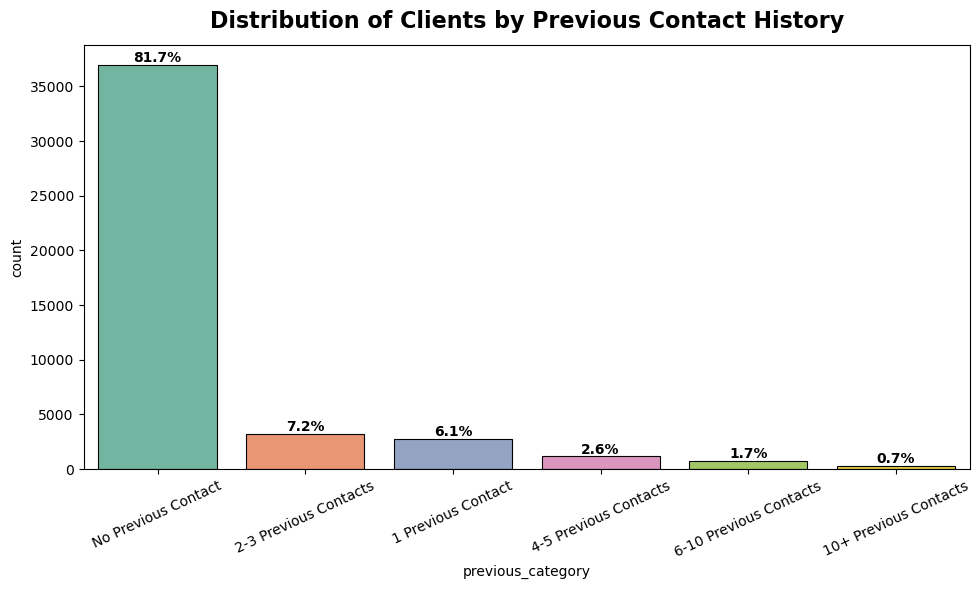

In [447]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=data, x='previous_category', order=previous_cat_counts.index, palette='Set2', edgecolor='black', linewidth=0.8, ax=ax)

# Add labels to each bar
for idx, row in previous_cat_counts.items():
    ax.text(idx, row, f"{previous_cat_percentages[idx]:.1f}%", color='black', ha="center", va="bottom", fontsize=10, fontweight='bold')
ax.set_title('Distribution of Clients by Previous Contact History', fontsize=16, fontweight='bold', y=1.02)
ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

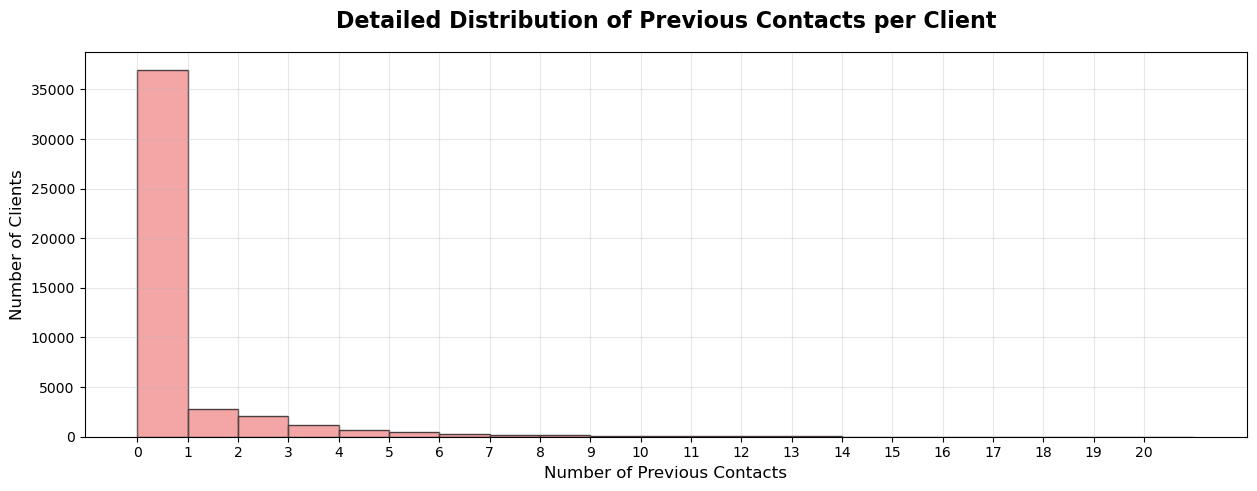

In [448]:
# Histogram showing detailed distribution

plt.figure(figsize=(15, 5))
max_previous = min(20, data['previous'].max())  # Limit to 20 for better visualization
plt.hist(data['previous'], bins=range(0, max_previous + 2), alpha=0.7, color='lightcoral', edgecolor='black')
plt.title('Detailed Distribution of Previous Contacts per Client', fontsize=16, fontweight='bold', y=1.04)
plt.xlabel('Number of Previous Contacts', fontsize=12)
plt.ylabel('Number of Clients', fontsize=12)
plt.xticks(range(0, max_previous + 1))

plt.grid(True, alpha=0.3)
plt.show()


In [449]:
# Statistics of previously contacted clients    
df_previously_contacted = data[data['previous'] > 0]
print(f"Number of previously contacted clients: {len(df_previously_contacted)}")

if len(df_previously_contacted) > 0:
    display_md("**Statistics of Previously Contacted Clients :**")
    print(df_previously_contacted['previous'].describe())
    
    # Percentile breakdown
    percentiles = [10, 25, 50, 75, 90, 95, 99]
    display_md("**Percentiles of Previous Contacts (Previously Contacted Clients) :**")
    for p in percentiles:
        value = np.percentile(df_previously_contacted['previous'], p)
        print(f"{p}th Percentile : {value:.0f} previous contacts")

Number of previously contacted clients: 8257


**Statistics of Previously Contacted Clients :**

count   8257.00
mean       3.18
std        4.56
min        1.00
25%        1.00
50%        2.00
75%        4.00
max      275.00
Name: previous, dtype: float64


**Percentiles of Previous Contacts (Previously Contacted Clients) :**

10th Percentile : 1 previous contacts
25th Percentile : 1 previous contacts
50th Percentile : 2 previous contacts
75th Percentile : 4 previous contacts
90th Percentile : 6 previous contacts
95th Percentile : 9 previous contacts
99th Percentile : 17 previous contacts


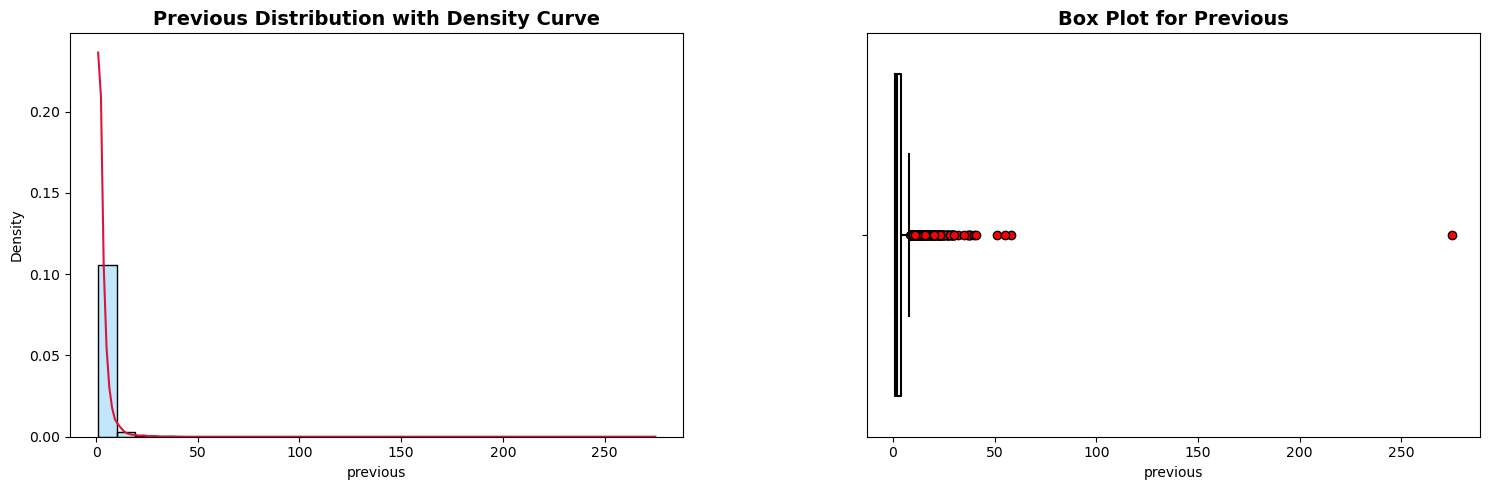

In [450]:
if len(df_previously_contacted) > 0:
    univariate_numeric_distribution(df_previously_contacted, 'previous')

**Success Rate by Number of Previous Contacts :**

term_deposit,yes,success_rate
previous,,
0,3384.00,9.16
1,583.00,21.03
2,456.00,21.65
3,294.00,25.74
4,171.00,23.95
5,121.00,26.36
6,83.00,29.96
7,54.00,26.34
8,39.00,30.23


**Success Rate by Previous Contact Categories :**

term_deposit,yes,success_rate
previous_category,,
1 Previous Contact,583,21.03
10+ Previous Contacts,54,18.37
2-3 Previous Contacts,750,23.09
4-5 Previous Contacts,292,24.89
6-10 Previous Contacts,226,29.35
No Previous Contact,3384,9.16


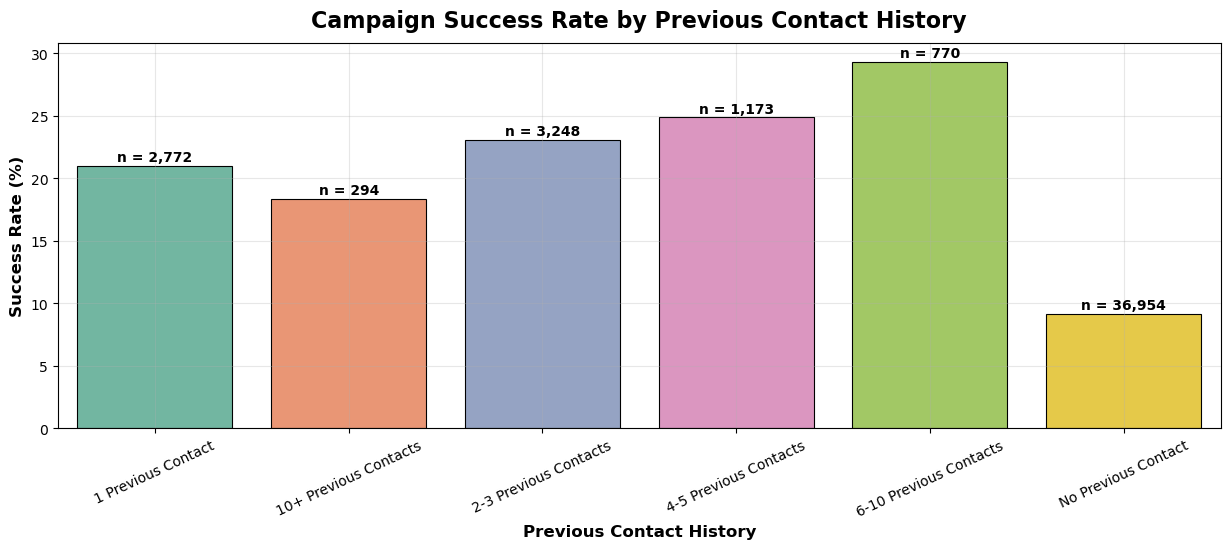

In [451]:
# Analyze campaign success by number of previous contacts
success_by_previous_counts = data.groupby('previous')['term_deposit'].value_counts().unstack().fillna(0).assign(total=lambda x: x.sum(axis=1), success_rate=lambda x: (x['yes'] / x['total']) * 100).sort_values(by='success_rate', ascending=False).sort_index()
display_md("**Success Rate by Number of Previous Contacts :**")
display(success_by_previous_counts[['yes', 'success_rate']].head(10))
print()

success_by_previous_cat = data.groupby('previous_category')['term_deposit'].value_counts().unstack().fillna(0).assign(total=lambda x: x.sum(axis=1), success_rate=lambda x: (x['yes'] / x['total']) * 100).sort_values(by='success_rate', ascending=False).sort_index()
display_md("**Success Rate by Previous Contact Categories :**")
display(success_by_previous_cat[['yes', 'success_rate']])

# Create bar plot
plt.figure(figsize=(15, 5))
sns.barplot(x=success_by_previous_cat.index, y=success_by_previous_cat['success_rate'], palette='Set2', edgecolor='black', linewidth=0.8)

# Add client count labels on bars
for i, row in success_by_previous_cat.iterrows():
    plt.text(i, row['success_rate'] + 0.1, f"n = {int(row['total']):,}", ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.title('Campaign Success Rate by Previous Contact History', fontsize=16, fontweight='bold', y=1.02)
plt.xlabel('Previous Contact History', fontsize=12, fontweight='bold')
plt.ylabel('Success Rate (%)', fontsize=12, fontweight='bold')
plt.xticks(rotation=25)

plt.grid(True, alpha=0.3)
plt.show()

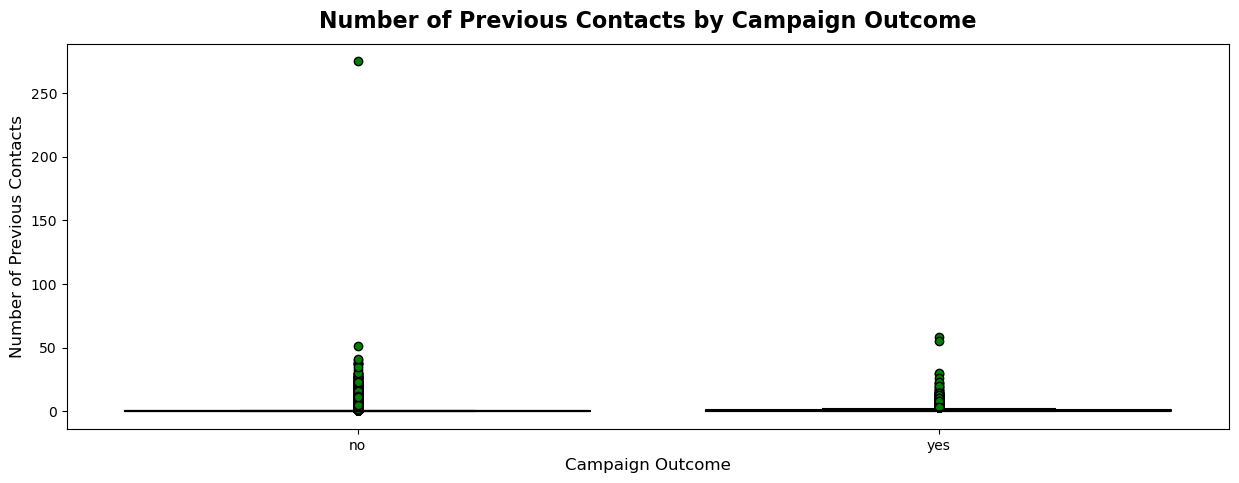

**Previous Contacts by Campaign Outcome :**

,count,mean,median,std
term_deposit,,,,
no,39922,0.50,0.00,2.26
yes,5289,1.17,0.00,2.55


In [452]:
# Box plot showing previous contacts distribution by campaign outcome

plt.figure(figsize=(15, 5))
sns.boxplot(data=data, x='term_deposit', y='previous', fill=False, color='k', flierprops={'marker':'o', 'markerfacecolor':'g'})
plt.title('Number of Previous Contacts by Campaign Outcome', fontsize=16, fontweight='bold', y=1.02)
plt.xlabel('Campaign Outcome', fontsize=12)
plt.ylabel('Number of Previous Contacts', fontsize=12)
plt.show()

# Statistical comparison
display_md("**Previous Contacts by Campaign Outcome :**")
previous_by_outcome = data.groupby('term_deposit')['previous'].agg(['count', 'mean', 'median', 'std'])
display(previous_by_outcome.round(2))


In [453]:
# Create detailed cross-tabulation
previous_outcome_crosstab = pd.crosstab(data['previous_category'], data['term_deposit'], 
                                       margins=True, normalize='index')
display_md("**Detailed Cross-tabulation (Row Percentages) :**")
display(previous_outcome_crosstab.round(3))

# Chi-square test for independence
from scipy.stats import chi2_contingency
chi2, p_value, dof, expected = chi2_contingency(pd.crosstab(data['previous_category'], data['term_deposit']))
display_md("**Chi-square Test for Independence :**")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Significant relationship: {'Yes' if p_value < 0.05 else 'No'}")


**Detailed Cross-tabulation (Row Percentages) :**

term_deposit,no,yes
previous_category,,
1 Previous Contact,0.79,0.21
10+ Previous Contacts,0.82,0.18
2-3 Previous Contacts,0.77,0.23
4-5 Previous Contacts,0.75,0.25
6-10 Previous Contacts,0.71,0.29
No Previous Contact,0.91,0.09
All,0.88,0.12


**Chi-square Test for Independence :**

Chi-square statistic: 1315.4940
P-value: 0.0000
Significant relationship: Yes


**Correlation between previous and current contacts :** -0.033

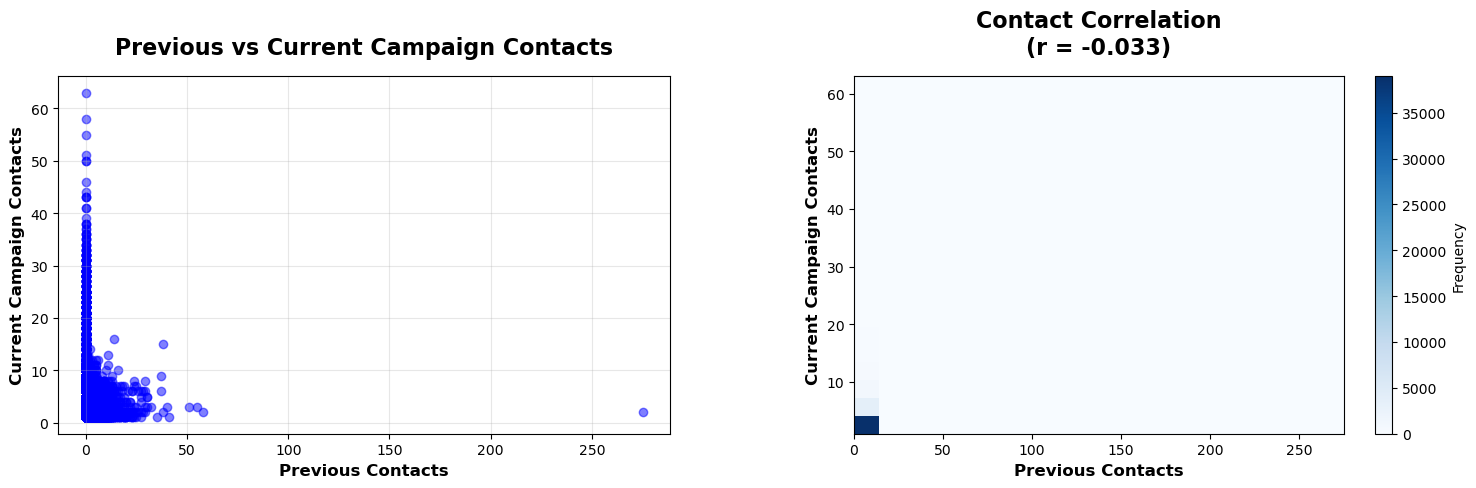

In [454]:
# Compare previous contacts with current campaign contacts
correlation = data['previous'].corr(data['campaign'])
display_md(f"**Correlation between previous and current contacts :** {correlation:.3f}")


fig, ax = plt.subplots(ncols=2, figsize=(15, 5))

ax[0].scatter(data['previous'], data['campaign'], alpha=0.5, color='blue')
ax[0].set_xlabel('Previous Contacts', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Current Campaign Contacts', fontsize=12, fontweight='bold')
ax[0].set_title('Previous vs Current Campaign Contacts', fontsize=16, fontweight='bold', y=1.04)
ax[0].grid(True, alpha=0.3)

h = ax[1].hist2d(data['previous'], data['campaign'], bins=20, cmap='Blues')
ax[1].set_xlabel('Previous Contacts', fontsize=12, fontweight='bold')
ax[1].set_ylabel('Current Campaign Contacts', fontsize=12, fontweight='bold')
ax[1].set_title(f'Contact Correlation\n(r = {correlation:.3f})', fontsize=16, fontweight='bold', y=1.04)

# Add colorbar properly
fig.colorbar(h[3], ax=ax[1], label='Frequency')

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()



In [455]:
# Detailed analysis for clients with different previous contact levels
display_md("**Detailed Analysis of Previous Contact Levels :**")
print("=" * 125)

# For first 10 previous contact levels
for prev_contact in sorted(data['previous'].unique())[:10]:
    subset = data[data['previous'] == prev_contact]
    total_clients = len(subset)
    success_count = (subset['term_deposit'] == 'yes').sum()
    success_rate = (subset['term_deposit'] == 'yes').mean() * 100
    avg_current_contacts = subset['campaign'].mean()
    print(f"Previous Contacts: {prev_contact:^7,} | Total Clients: {total_clients:^7,} | Success Rate: {success_rate:^6.1f}% | Avg Current Contacts: {avg_current_contacts:^7.1f} | Total Successful Conversions: {success_count:^7,}") 



**Detailed Analysis of Previous Contact Levels :**

Previous Contacts:    0    | Total Clients: 36,954  | Success Rate:  9.2  % | Avg Current Contacts:   2.9   | Total Successful Conversions:  3,384 
Previous Contacts:    1    | Total Clients:  2,772  | Success Rate:  21.0 % | Avg Current Contacts:   1.8   | Total Successful Conversions:   583  
Previous Contacts:    2    | Total Clients:  2,106  | Success Rate:  21.7 % | Avg Current Contacts:   1.9   | Total Successful Conversions:   456  
Previous Contacts:    3    | Total Clients:  1,142  | Success Rate:  25.7 % | Avg Current Contacts:   2.1   | Total Successful Conversions:   294  
Previous Contacts:    4    | Total Clients:   714   | Success Rate:  23.9 % | Avg Current Contacts:   2.2   | Total Successful Conversions:   171  
Previous Contacts:    5    | Total Clients:   459   | Success Rate:  26.4 % | Avg Current Contacts:   2.4   | Total Successful Conversions:   121  
Previous Contacts:    6    | Total Clients:   277   | Success Rate:  30.0 % | Avg Current Contacts:   2.3   | To

In [456]:
# Create a comprehensive summary
display_md("**BUSINESS INTELLIGENCE SUMMARY :**")
print("=" * 50)

# Key Metrics
first_time_clients = (data['previous'] == 0).sum()
returning_clients = (data['previous'] > 0).sum()
high_touch_clients = (data['previous'] > 5).sum()

display_md("**Client Segmentation :**")
print(f" - First-time Clients: {first_time_clients:^3,} ({(first_time_clients/len(data))*100:.1f}%)")
print(f" - Returning Clients: {returning_clients:^3,} ({(returning_clients/len(data))*100:.1f}%)")
print(f" - High-Touch Clients: {high_touch_clients:^3,} ({(high_touch_clients/len(data))*100:.1f}%)")

# Success Rates
first_time_success = data[data['previous'] == 0]['term_deposit'].apply(lambda x: x == 'yes').mean()*100
returning_success = data[data['previous'] > 0]['term_deposit'].apply(lambda x: x == 'yes').mean()*100

display_md("**Success Rates by Client Type :**")
print(f" - First-time Clients Success Rate: {first_time_success:^3.1f}%")
print(f" - Returning Clients Success Rate: {returning_success:^3.1f}%")
print(f" - Difference: {returning_success - first_time_success:^3.1f}%")

# Recommendation
if returning_success > first_time_success:
    display_md("**Recommendation :**")
    print(" - Returning clients have a higher success rate!")
    print(" - Consider priortizing follow-up campaigns.")
else:
    display_md("**Recommendation :**")
    print(" - First-time clients have a higher success rate!")
    print(" - Consider focusing on new clients.")


**BUSINESS INTELLIGENCE SUMMARY :**

**Client Segmentation :**

 - First-time Clients: 36,954 (81.7%)
 - Returning Clients: 8,257 (18.3%)
 - High-Touch Clients: 1,064 (2.4%)


**Success Rates by Client Type :**

 - First-time Clients Success Rate: 9.2%
 - Returning Clients Success Rate: 23.1%
 - Difference: 13.9%


**Recommendation :**

 - Returning clients have a higher success rate!
 - Consider priortizing follow-up campaigns.


### **Contact** 
Type of communication used to contact the client (categorical: 'cellular', 'telephone', 'unknown')

In [457]:
display_md("**Contact Distribution Summary:**")
display_md(f"**Number of clients contacted by telephone :** {data['contact'].value_counts().get('telephone', 0)}")
display_md(f"**Number of clients contacted by cellular :** {data['contact'].value_counts().get('cellular', 0)}")
display_md(f"**Number of clients contacted by unknown :** {data['contact'].value_counts().get('unknown', 0)}")

**Contact Distribution Summary:**

**Number of clients contacted by telephone :** 2906

**Number of clients contacted by cellular :** 29285

**Number of clients contacted by unknown :** 13020

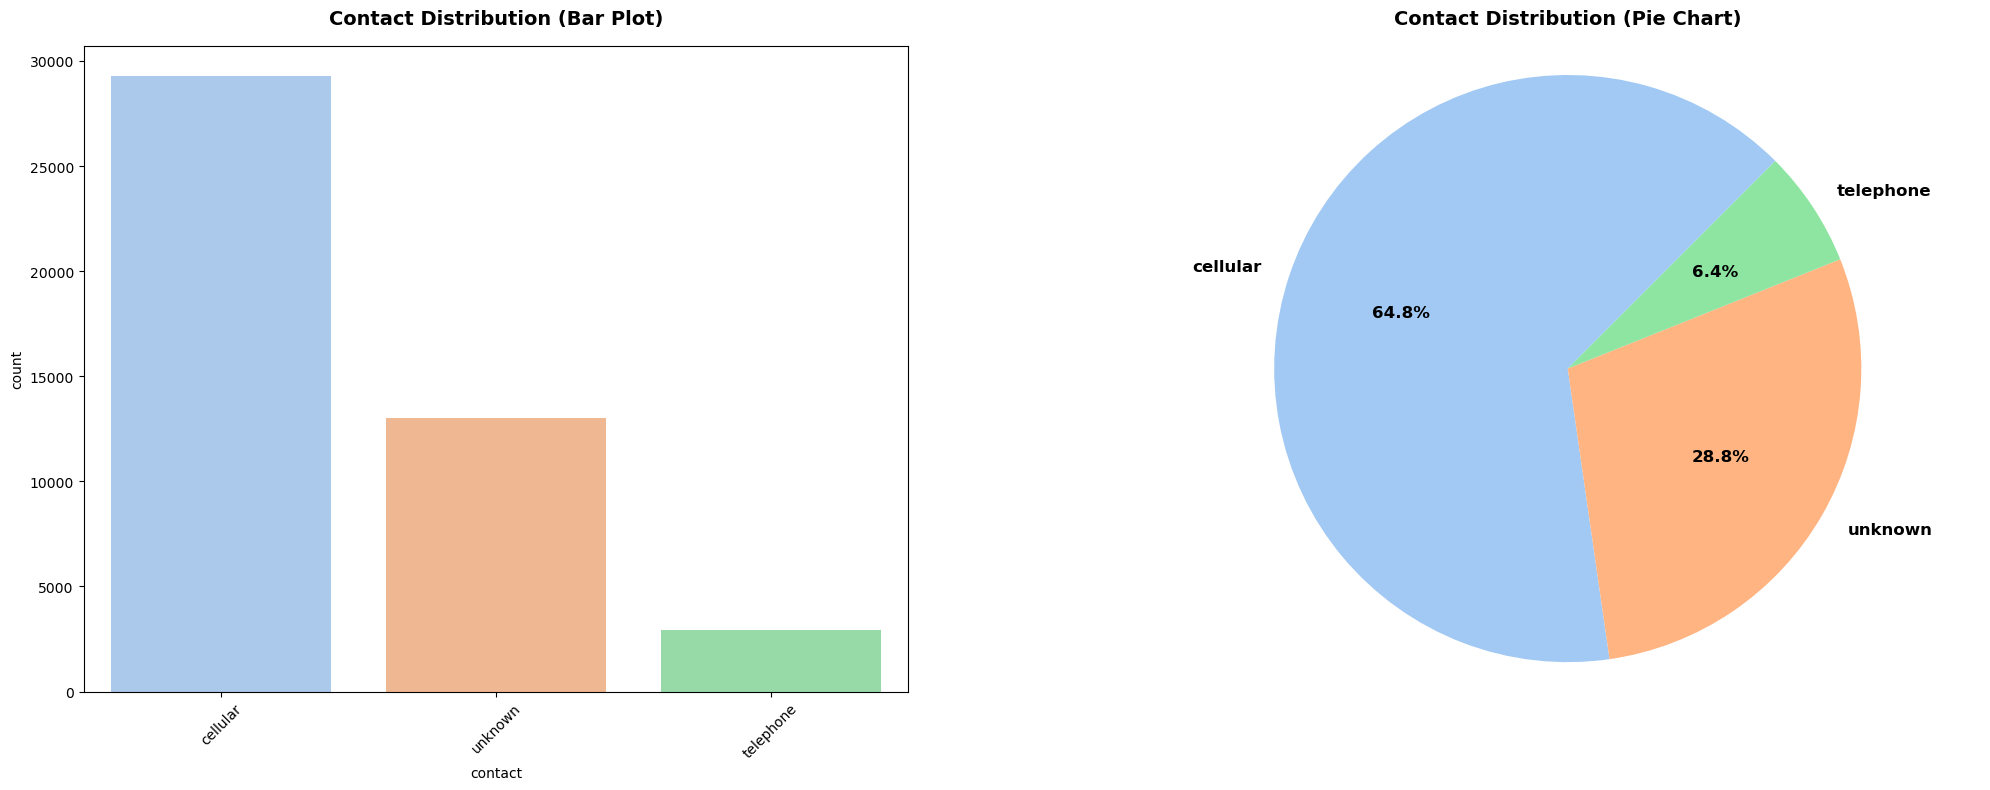

In [458]:
univariate_categorical_distribution(data, 'contact')

,contact,term_deposit,count
0,cellular,no,24916
1,cellular,yes,4369
2,telephone,no,2516
3,telephone,yes,390
4,unknown,no,12490
5,unknown,yes,530


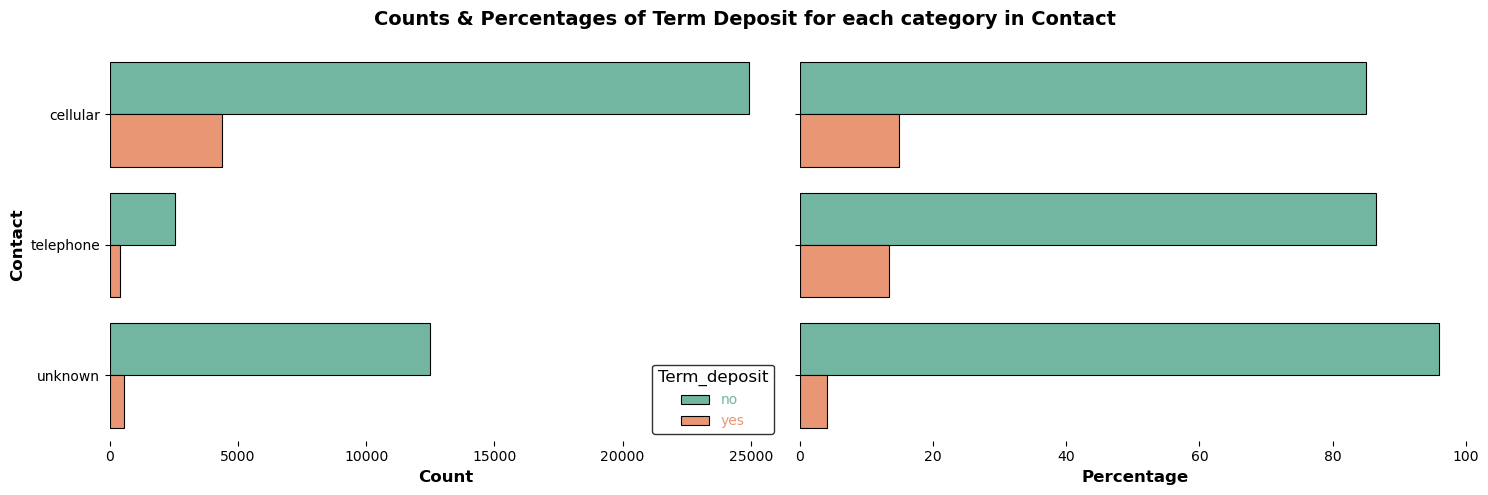

In [459]:
plot_categorical_columns(data, column='contact')

**Insight**

- The analysis indicates that cellular marketing campaigns generate more term deposit subscriptions compared to telephone campaigns.

### **Poutcome**
 Outcome of the previous marketing campaign (categorical: 'failure', 'unknown', 'success')

In [460]:
display_md("**Previous Campaign Outcome Distribution :**")
# count and percentage distribution
poutcome_counts = data['poutcome'].value_counts()
poutcome_percentages = data['poutcome'].value_counts(normalize=True) *100

print("Previous Campaign Outcome | Number of Clients | Percentage")
print("-"*60)
for category, count in poutcome_counts.items():
    print(f"{category:^25} | {count:^17,} | {poutcome_percentages[category]:>9.1f}%")
    

**Previous Campaign Outcome Distribution :**

Previous Campaign Outcome | Number of Clients | Percentage
------------------------------------------------------------
         unknown          |      36,959       |      81.7%
         failure          |       4,901       |      10.8%
          other           |       1,840       |       4.1%
         success          |       1,511       |       3.3%


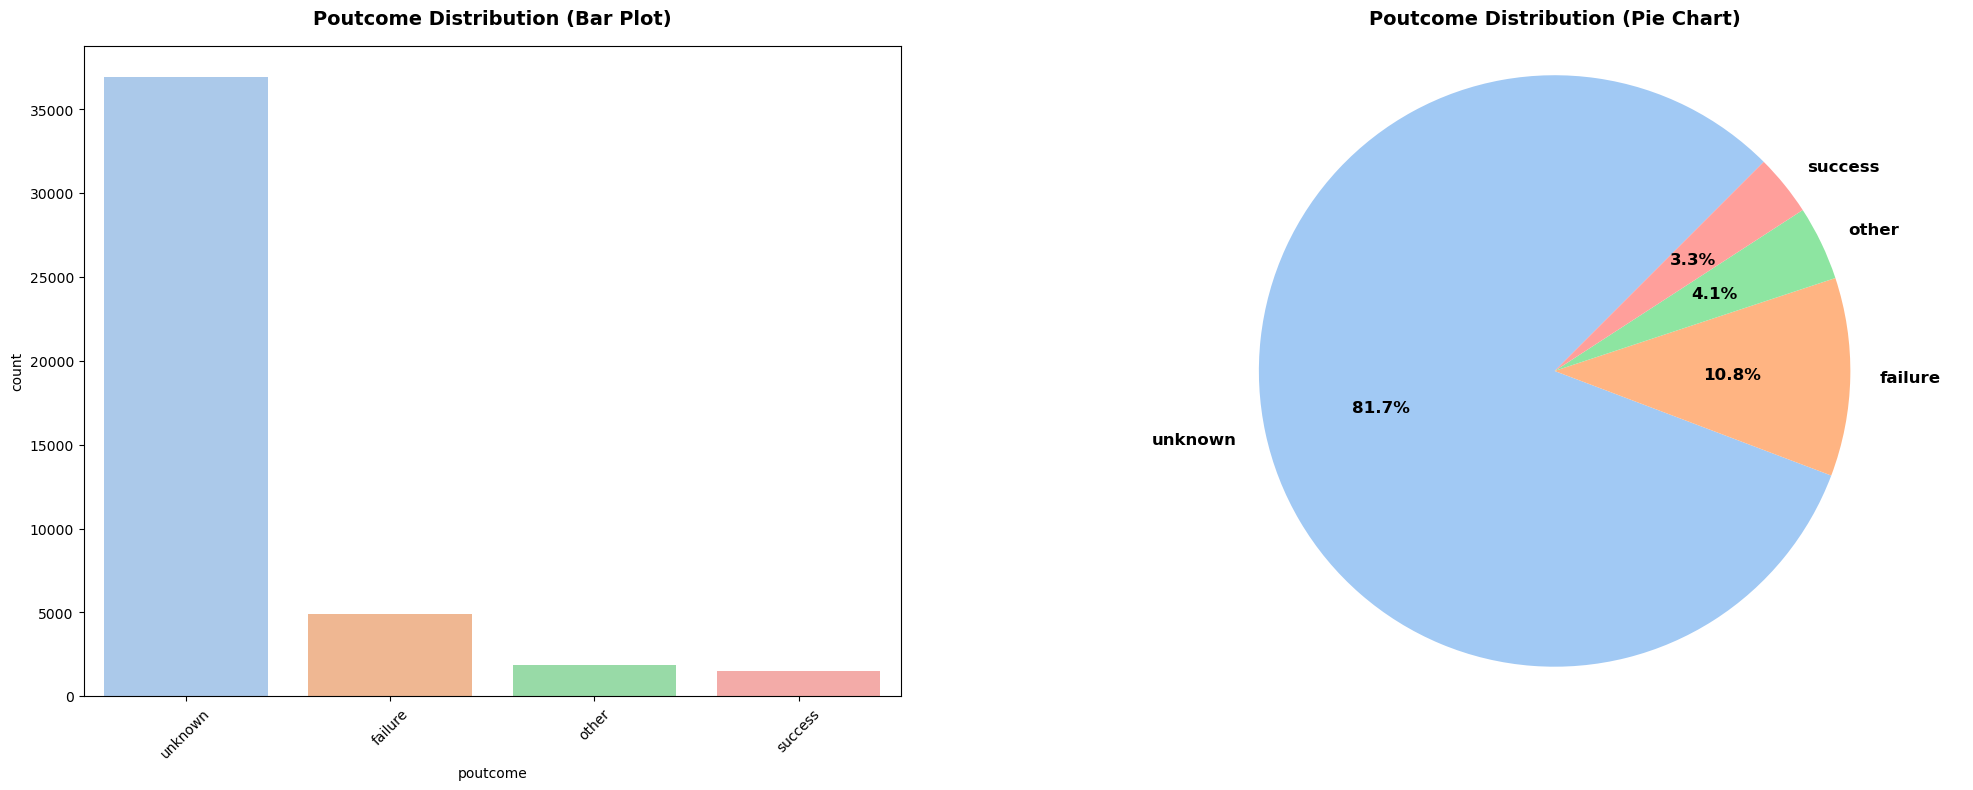

In [461]:
univariate_categorical_distribution(data, 'poutcome')

In [462]:
# Analyze current campaign success by previous campaign outcome
success_by_poutcome = data.groupby('poutcome')['term_deposit'].apply(lambda x: (x == 'yes').mean() * 100)

display_md("**Current Campaign Success Rate by Previous Campaign Outcome :**")
print("Previous Outcome" + " " * 3 + "| Success Rate | Client Count")
print("-" * 55)
for outcome, success_rate in success_by_poutcome.items():
    client_count = (data['poutcome'] == outcome).sum()
    print(f"{outcome:^18} | {success_rate:>11.1f}% | {client_count:^11,}")

# Calculate overall success rate for comparison
overall_success = (data['term_deposit'] == 'yes').mean() * 100
print()
display_md(f"**Overall current campaign success rate :** {overall_success:.1f}%")



**Current Campaign Success Rate by Previous Campaign Outcome :**

Previous Outcome   | Success Rate | Client Count
-------------------------------------------------------
     failure       |        12.6% |    4,901   
      other        |        16.7% |    1,840   
     success       |        64.7% |    1,511   
     unknown       |         9.2% |   36,959   



**Overall current campaign success rate :** 11.7%

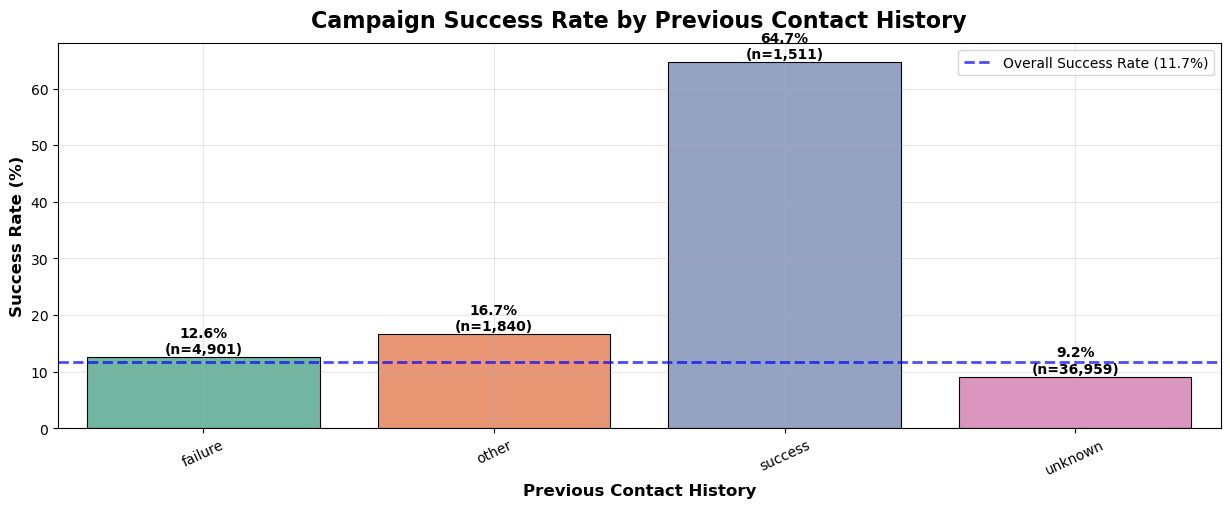

In [463]:
# Create bar plot
plt.figure(figsize=(15, 5))
sns.barplot(x=success_by_poutcome.index, y=success_by_poutcome, palette='Set2', edgecolor='black', linewidth=0.8)

# Add horizontal line for overall success rate
plt.axhline(y=overall_success, color='blue', ls='--', lw=2, alpha=0.7, label=f'Overall Success Rate ({overall_success:.1f}%)')

# Add client count labels on bars
for i, v in success_by_poutcome.items():
    plt.text(i, v + 0.1, f"{v:.1f}%\n(n={int(poutcome_counts[i]):,})", ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.title('Campaign Success Rate by Previous Contact History', fontsize=16, fontweight='bold', y=1.02)
plt.xlabel('Previous Contact History', fontsize=12, fontweight='bold')
plt.ylabel('Success Rate (%)', fontsize=12, fontweight='bold')
plt.xticks(rotation=25)
plt.legend()

plt.grid(True, alpha=0.3)
plt.show()

In [464]:
# Chi-square test for independence
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(pd.crosstab(data['poutcome'], data['term_deposit']))
display_md(f"**Chi-square Test Results :**")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")
print(f"Significant relationship: {'Yes' if p_value < 0.05 else 'No'}")

if p_value < 0.05:
    display_md(f"**Conclusion :** Previous campaign outcome significantly affects current campaign outcome.")
else:
    display_md(f"**Conclusion :** No significant relationship between previous and current campaign outcomes.")


**Chi-square Test Results :**

Chi-square statistic: 4391.5066
P-value: 0.000000
Degrees of freedom: 3
Significant relationship: Yes


**Conclusion :** Previous campaign outcome significantly affects current campaign outcome.

In [465]:
# Detailed breakdown for each previous outcome category
display_md("**DETAILED ANALYSIS BY PREVIOUS CAMPAIGN OUTCOME**")
print("=" * 60)

for outcome in data['poutcome'].unique():
    subset = data[data['poutcome'] == outcome]
    current_success_rate = (subset['term_deposit'] == 'yes').mean() * 100
    current_success_count = (subset['term_deposit'] == 'yes').sum()
    
    print(f"\n{outcome.upper()} Previous Campaign :")
    print(f"Total clients: {len(subset):,}")
    print(f"Current success rate: {current_success_rate:.1f}%")
    print(f"Successful conversions: {current_success_count:,}")
    print(f"Current vs Overall rate: {current_success_rate - overall_success:+.1f} percentage points")
    
    # Additional insights for this group
    avg_contacts = subset['campaign'].mean()
    avg_duration = subset['duration'].mean()
    print(f"Average contacts in current campaign: {avg_contacts:.1f}")
    print(f"Average call duration: {avg_duration:.0f} seconds")
    print("-" * 40)
    

**DETAILED ANALYSIS BY PREVIOUS CAMPAIGN OUTCOME**


UNKNOWN Previous Campaign :
Total clients: 36,959
Current success rate: 9.2%
Successful conversions: 3,386
Current vs Overall rate: -2.5 percentage points
Average contacts in current campaign: 2.9
Average call duration: 258 seconds
----------------------------------------

FAILURE Previous Campaign :
Total clients: 4,901
Current success rate: 12.6%
Successful conversions: 618
Current vs Overall rate: +0.9 percentage points
Average contacts in current campaign: 2.0
Average call duration: 244 seconds
----------------------------------------

OTHER Previous Campaign :
Total clients: 1,840
Current success rate: 16.7%
Successful conversions: 307
Current vs Overall rate: +5.0 percentage points
Average contacts in current campaign: 2.5
Average call duration: 256 seconds
----------------------------------------

SUCCESS Previous Campaign :
Total clients: 1,511
Current success rate: 64.7%
Successful conversions: 978
Current vs Overall rate: +53.0 percentage points
Average contacts in current c

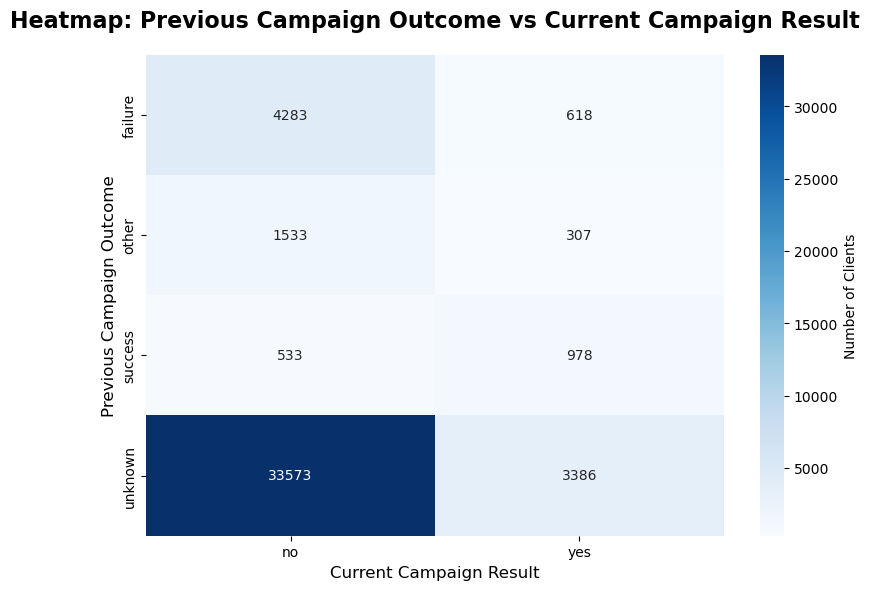

In [466]:
# Create a heatmap showing the relationship

plt.figure(figsize=(8, 6))
crosstab_for_heatmap = pd.crosstab(data['poutcome'], data['term_deposit'])
sns.heatmap(crosstab_for_heatmap, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Number of Clients'})
plt.title('Heatmap: Previous Campaign Outcome vs Current Campaign Result', fontsize=16, fontweight='bold', y=1.04)
plt.xlabel('Current Campaign Result', fontsize=12)
plt.ylabel('Previous Campaign Outcome', fontsize=12)
plt.tight_layout()
plt.show()


In [467]:
# Create actionable business insights

display_md("**BUSINESS INTELLIGENCE SUMMARY**")
print("=" * 50)

# Find the best and worst performing previous outcome groups
best_previous = success_by_poutcome.idxmax()
worst_previous = success_by_poutcome.idxmin()
best_rate = success_by_poutcome.max()
worst_rate = success_by_poutcome.min()

print(f"BEST performing group: {best_previous}")
print(f"Success rate: {best_rate:.1f}%")
print(f"Client count: {(data['poutcome'] == best_previous).sum():,}")

print(f"\nWORST performing group: {worst_previous}")
print(f"Success rate: {worst_rate:.1f}%")
print(f"Client count: {(data['poutcome'] == worst_previous).sum():,}")

print(f"\nPerformance gap: {best_rate - worst_rate:.1f} percentage points")

# Recommendations
print()
display_md(f"**STRATEGIC RECOMMENDATIONS:**")
if 'success' in best_previous.lower():
    print("Prioritize clients with previous successful campaigns")
    print("These clients show highest conversion potential")
elif 'failure' in worst_previous.lower():
    print("Clients with previous failures need different approach")
    print("Consider specialized re-engagement strategies")

# Calculate potential impact
high_potential_clients = (data['poutcome'] == best_previous).sum()
if high_potential_clients > 0:
    potential_additional_success = high_potential_clients * (best_rate - overall_success) / 100
    print(f"Focusing on {best_previous.upper()} group could yield {potential_additional_success:.0f} additional successes")


**BUSINESS INTELLIGENCE SUMMARY**

BEST performing group: success
Success rate: 64.7%
Client count: 1,511

WORST performing group: unknown
Success rate: 9.2%
Client count: 36,959

Performance gap: 55.6 percentage points



**STRATEGIC RECOMMENDATIONS:**

Prioritize clients with previous successful campaigns
These clients show highest conversion potential
Focusing on SUCCESS group could yield 801 additional successes


In [468]:
display_md("**Previous Campaign Outcome Findings :**")
print("=" * 50)

# Analyze relationship with other variables
display_md("**Association with other campaign metrics :**")
if 'previous' in data.columns:
    # Clients with previous contacts vs outcomes
    prev_contact_outcome = pd.crosstab(data['previous'] > 0, data['poutcome'])
    print("\nPrevious Contacts vs Previous Outcomes :")
    display(prev_contact_outcome)
    

**Previous Campaign Outcome Findings :**

**Association with other campaign metrics :**


Previous Contacts vs Previous Outcomes :


poutcome,failure,other,success,unknown
previous,,,,
False,0,0,0,36954
True,4901,1840,1511,5


In [469]:
chi2, p_value, dof, expected = chi2_contingency(pd.crosstab(data['poutcome'], data['previous']>0))
display_md(f"**Chi-square Test Results :**")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")
print(f"Significant relationship: {'Yes' if p_value < 0.05 else 'No'}")


if p_value < 0.05:
    display_md(f"**Conclusion :** There is a significant association between poutcome and whether the customer had previous contacts (previous > 0). The two variables are not independent.")
else:
    display_md(f"**Conclusion :** There is no significant association between poutcome (outcome of the previous marketing campaign) and whether the customer had previous contacts (previous > 0). The two variables are independent.")
    

**Chi-square Test Results :**

Chi-square statistic: 45177.5100
P-value: 0.000000
Degrees of freedom: 3
Significant relationship: Yes


**Conclusion :** There is a significant association between poutcome and whether the customer had previous contacts (previous > 0). The two variables are not independent.

,poutcome,term_deposit,count
0,failure,no,4283
1,failure,yes,618
2,other,no,1533
3,other,yes,307
4,success,no,533
5,success,yes,978
6,unknown,no,33573
7,unknown,yes,3386


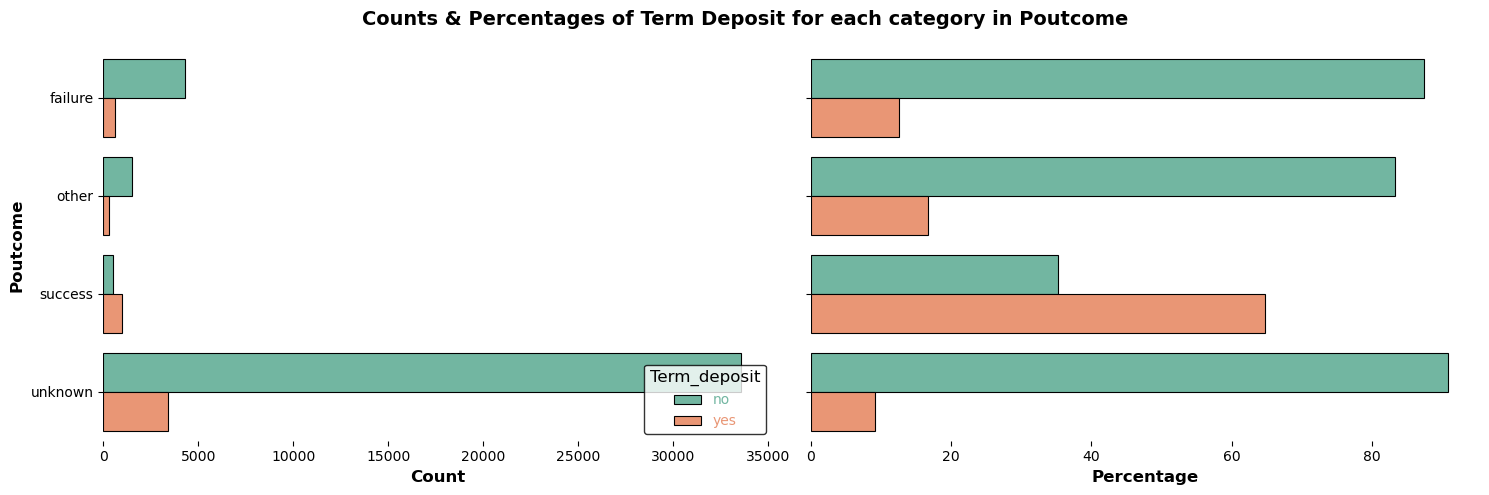

In [470]:
plot_categorical_columns(data,column='poutcome')

**Day**

In [471]:
display_md("**Last Contact Day Distribution Summary:**")
display(data['day'].value_counts()[:10])

**Last Contact Day Distribution Summary:**

day
20    2752
18    2308
21    2026
17    1939
6     1932
5     1910
14    1848
8     1842
28    1830
7     1817
Name: count, dtype: int64

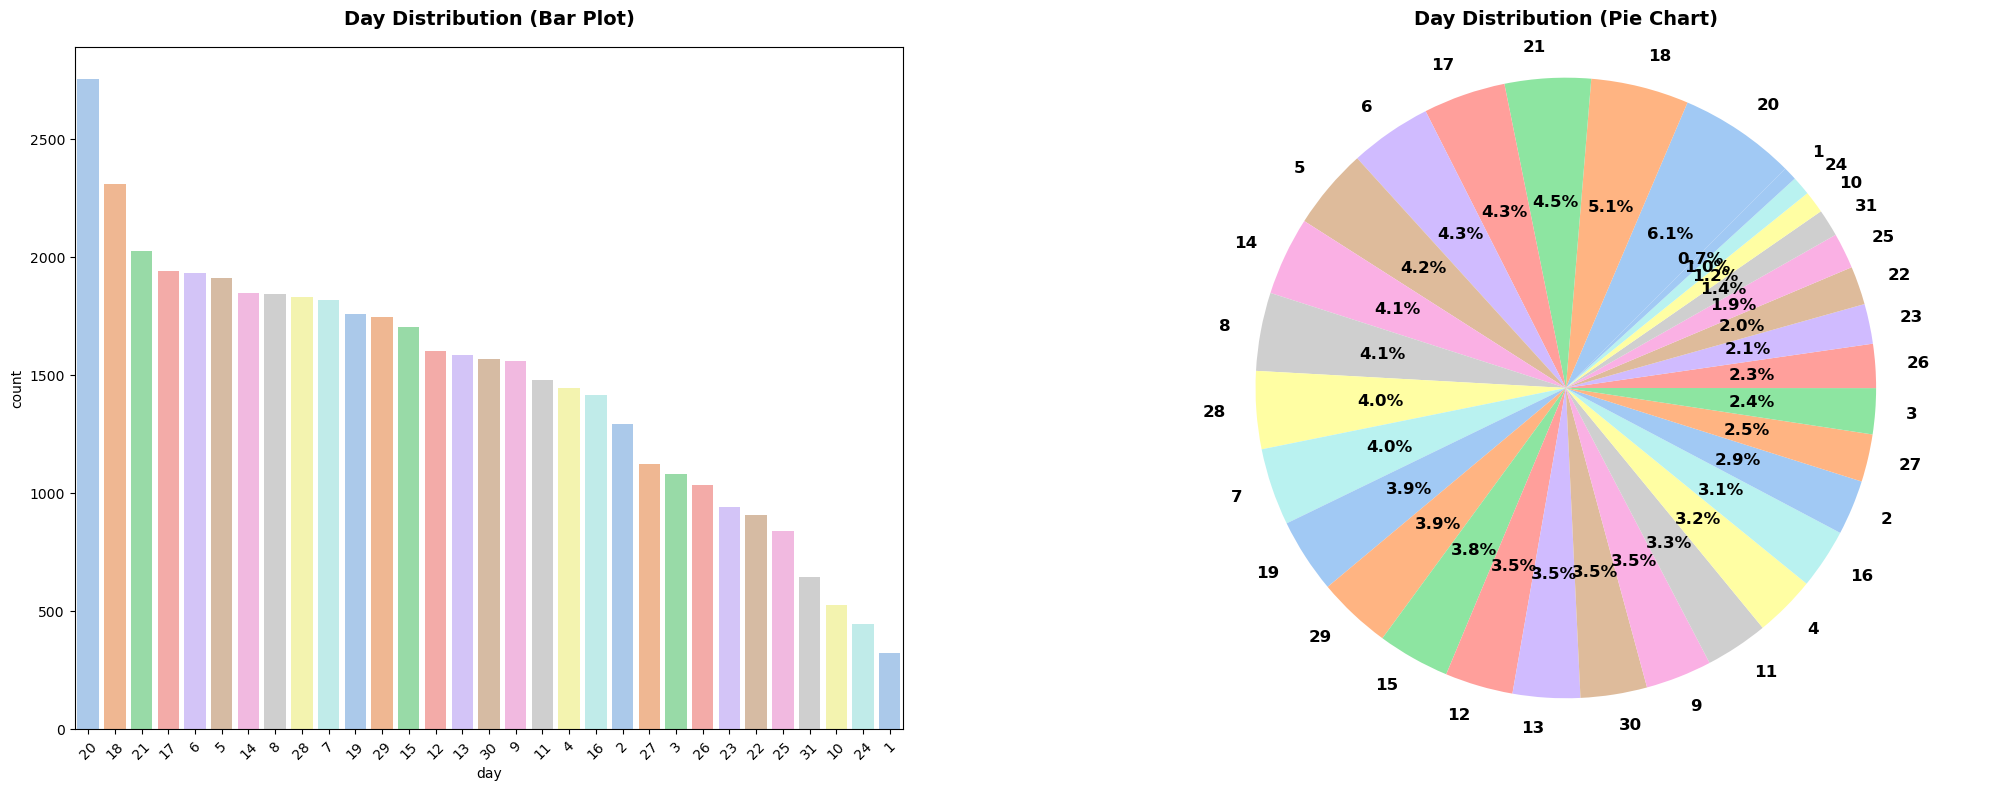

In [472]:
univariate_categorical_distribution(data, 'day')

**Month**

In [473]:
display_md("**Last Contact Month Distribution Summary:**")
display(data['month'].value_counts())

**Last Contact Month Distribution Summary:**

month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64

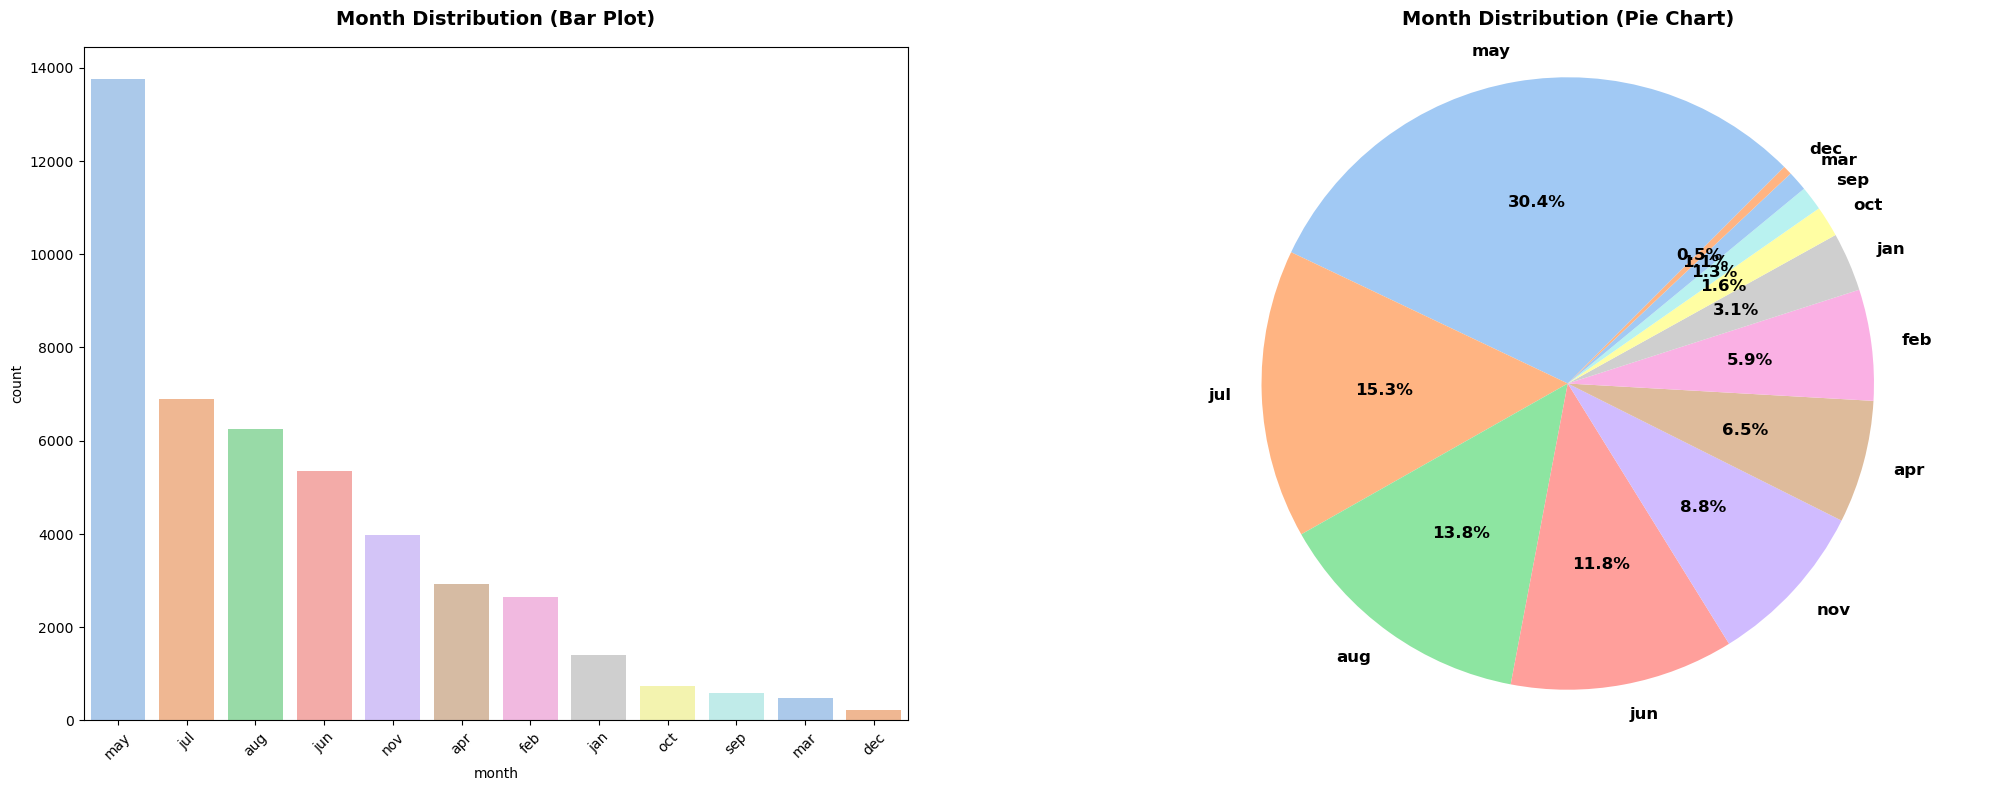

In [474]:
univariate_categorical_distribution(data, 'month')

**Number of subscribers of term deposit by month and day of week**

**Conclusion:**
By the below analysis, we conclude that:

- Most number of customers who subscribed to term deposits in month of May and in all day of week except for thursday. 

- Least number of customers who subscribed to term deposits in month of December and in all day of week. Holidays and festive seasons are not effective in converting customers to term deposits.

In [309]:
months_arr = [
    [i, m]
    for i, m in enumerate(data['month'])
    if i==0 or m != data['month'].iloc[i-1]    ## "Take this row if it's the first row OR if the month changed compared to the previous row."
]
months_arr = np.array(months_arr)


**We've got :**

**2008 : [0, 27729)**

**2009 : [27729, 42591)**

**2010 : [42591, shape of data)**



In [310]:
data.shape

(45211, 23)

In [311]:
## create year feature

data['year'] = np.hstack((np.array([2008] * (27729 - 0)),
           np.array([2009] * (42591 - 27729)),
           np.array([2010] * (45211 - 42591))))

month,apr,aug,dec,feb,jan,jul,jun,mar,may,nov,oct,sep
day,,,,,,,,,,,,
1,13,0,0,3,0,10,39,0,0,0,6,19
2,6,6,4,38,0,25,59,25,0,5,2,12
3,5,12,8,42,0,15,49,20,0,16,0,11
4,0,38,8,45,0,4,48,8,66,3,0,10
5,12,55,0,33,0,2,55,21,32,5,0,0
6,15,46,0,16,0,8,17,5,43,6,14,11
7,6,41,7,0,1,38,1,0,44,0,4,15
8,28,21,0,10,2,44,12,8,34,6,12,24
9,13,2,11,27,0,25,26,18,12,17,2,26


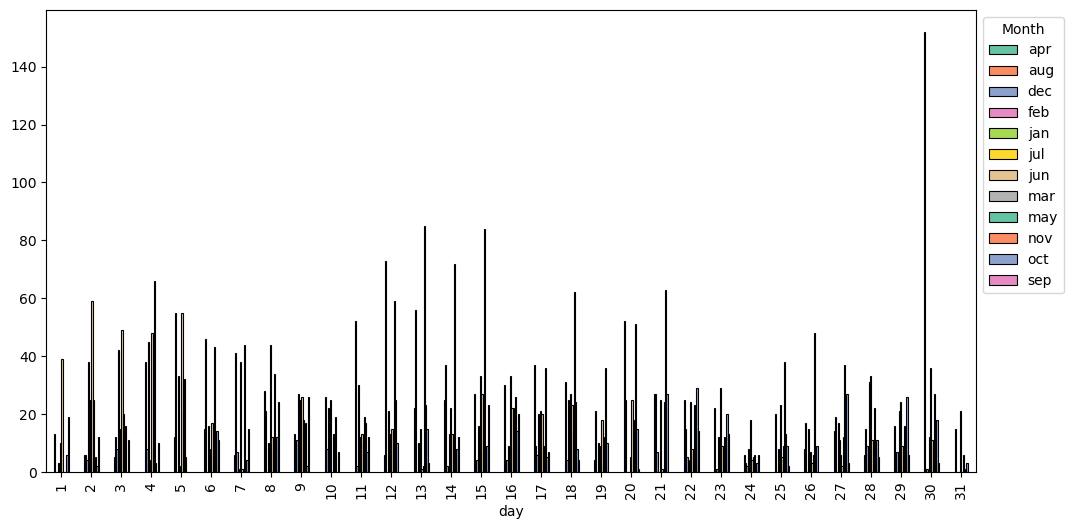

In [312]:
data1 = data[(data['term_deposit']=='yes')]
subsciber_df = pd.crosstab(data1['day'], data1['month'])
display(subsciber_df.style.highlight_max(axis='columns',color='yellow').highlight_min(axis='columns',color='coral'))


g = subsciber_df.plot(kind='bar',stacked=False,figsize=(12,6), color=sns.color_palette("Set2", n_colors=12), edgecolor='black', linewidth=0.8)
g.legend(title='Month',bbox_to_anchor=(1,1))
plt.show()

In [313]:
month_mapping = {
    'jan': 1,
    'feb': 2,
    'mar': 3,
    'apr': 4,
    'may': 5,
    'jun': 6,
    'jul': 7,
    'aug': 8,
    'sep': 9,
    'oct': 10,
    'nov': 11,
    'dec': 12
}

data['month_numeric'] = data['month'].map(month_mapping)

In [314]:
data[['month_numeric', 'year']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   month_numeric  45211 non-null  int64
 1   year           45211 non-null  int32
dtypes: int32(1), int64(1)
memory usage: 529.9 KB


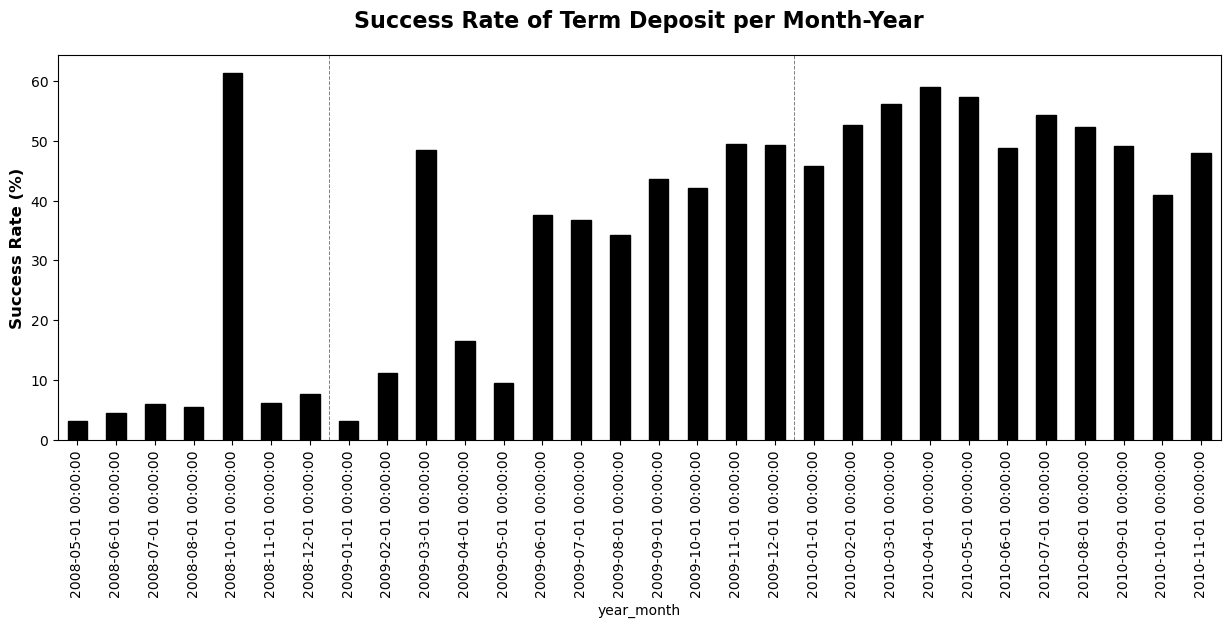

In [315]:
# Create proper datetime column
data.loc[:, 'year_month'] = pd.to_datetime(
    data['year'].astype(str) + '-' + data['month_numeric'].astype(str),
    format='%Y-%m'
)

# Count success rate per Year-Month
success_rate_yearmonth = data.groupby('year_month')['term_deposit'].apply(lambda x: (x=='yes').mean()*100).sort_index()

# Plot bar chart
fig, ax = plt.subplots(figsize=(15, 5))
success_rate_yearmonth.plot(kind='bar', color='k', edgecolor='k', ax=ax)

# Replace x-axis ticks with years only
years = success_rate_yearmonth.index.year.unique()
year_positions = [success_rate_yearmonth.index.get_loc(success_rate_yearmonth.index[success_rate_yearmonth.index.year == y][0]) for y in years]

#ax.set_xticks(year_positions)
#ax.set_xticklabels(years)

# Add vertical lines to separate years
for pos in year_positions:
    ax.axvline(pos-0.5, color='gray', linestyle='--', linewidth=0.7)

plt.title("Success Rate of Term Deposit per Month-Year", fontsize=16, fontweight='bold', y=1.05)
#plt.xlabel("Year", fontsize=12, fontweight='bold')
plt.ylabel("Success Rate (%)", fontsize=12, fontweight='bold')
plt.show()

### **3.4. Target Feature Analysis**

In [316]:
# Basic analysis of the target variable
display_md("**Term Deposit Subscription Analysis :**")
print(f"Total records: {len(data):,}")
print(f"Data type: {data['term_deposit'].dtype}")
print(f"Unique values: {data['term_deposit'].unique()}")

# Check for missing values
print(f"Missing values: {data['term_deposit'].isnull().sum()}")


**Term Deposit Subscription Analysis :**

Total records: 45,211
Data type: object
Unique values: ['no' 'yes']
Missing values: 0


In [317]:
# Count and percentage distribution
subscription_counts = data['term_deposit'].value_counts()
subscription_percentages = data['term_deposit'].value_counts(normalize=True) * 100

display_md("**Term Deposit Subscription Distribution :**")
for category, count in subscription_counts.items():
    print(f"{category} : {count:,} ({subscription_percentages[category]:.1f}%)")

display_md(f"**Total clients contacted :** {len(data):,}")
display_md(f"**Overall subscription rate :** {subscription_percentages.get('yes', 0):.1f}%")
display_md(f"**Non-subscription rate :** {subscription_percentages.get('no', 0):.1f}%")


**Term Deposit Subscription Distribution :**

no : 39,922 (88.3%)
yes : 5,289 (11.7%)


**Total clients contacted :** 45,211

**Overall subscription rate :** 11.7%

**Non-subscription rate :** 88.3%

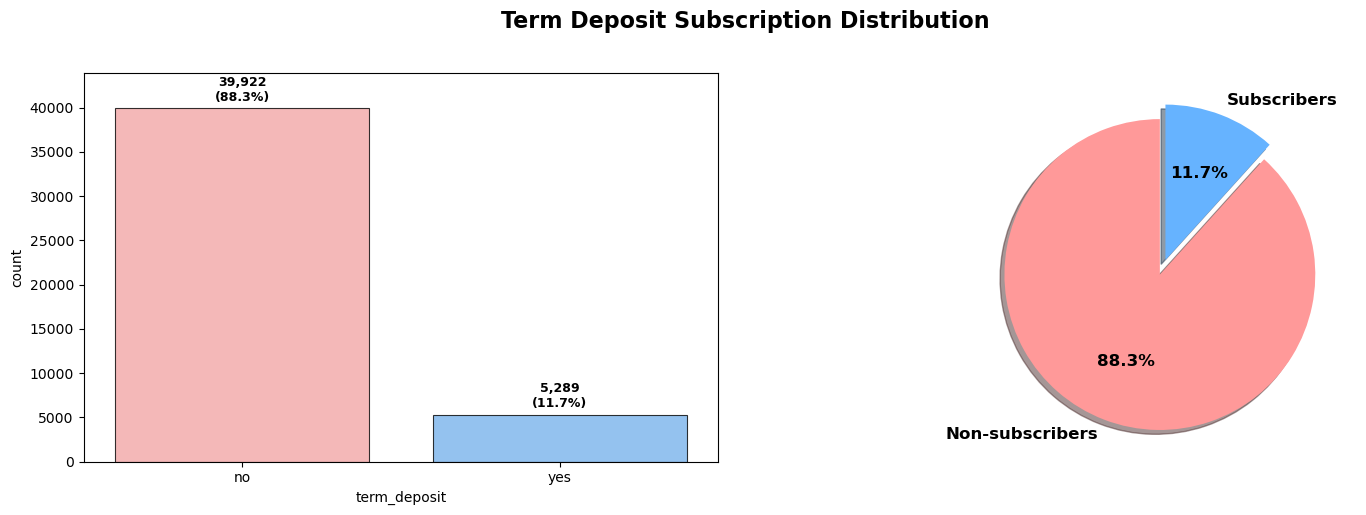

In [345]:
fig, ax = plt.subplots(ncols = 2, figsize=(15, 5))
sns.countplot(x=data['term_deposit'],palette=['#ff9999', '#66b3ff'],alpha=0.8, edgecolor='black', linewidth=0.8, ax=ax[0])

for i, v in enumerate(data['term_deposit'].value_counts()):
    ax[0].text(i, v+500, f'{v:,}\n({v/len(data)*100:.1f}%)',ha='center', va='bottom', fontsize=9,fontweight='bold' ,color='black')
ax[0].set_ylim(0, max(data['term_deposit'].value_counts())*1.1)

ax[1].pie(subscription_counts.values, labels=['Non-subscribers', 'Subscribers'], autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'], 
          explode=(0.05, 0.05), startangle=90, shadow=True, textprops={'fontsize':12, 'color':'k', 'weight':'bold'})

fig.suptitle("Term Deposit Subscription Distribution", fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.2)
plt.show()


__Data is highly imbalanced, with a significant majority of customers not subscribing to the term deposit. This imbalance will need to be addressed in the modeling phase, possibly through techniques such as resampling or using algorithms that can handle class imbalance effectively.__

In [319]:
# Analyze class imbalance
yes_count = (data['term_deposit'] == 'yes').sum()
no_count = (data['term_deposit'] == 'no').sum()
imbalance_ratio = max(yes_count, no_count) / min(yes_count, no_count)

display_md("**CLASS IMBALANCE ANALYSIS**")
print("=" * 40)
print(f"Subscribed (yes): {yes_count:,} clients")
print(f"Not subscribed (no): {no_count:,} clients")
print(f"Imbalance ratio: {imbalance_ratio:.1f}:1")

if imbalance_ratio > 2:
    display_md("  **SIGNIFICANT CLASS IMBALANCE DETECTED !** ")
    print(" Consider using approachs like :")
    print(" - Stratified Sampling")
    print(" - SMOTE Oversampling Approach")
    print(" - Class Weights")
    print(" - Ensemble methods")
    print(" - Threshold Tuning")
    print(" - Cost-Sensitive Optimization")
else:
    print("Classes are relatively balanced")


**CLASS IMBALANCE ANALYSIS**

Subscribed (yes): 5,289 clients
Not subscribed (no): 39,922 clients
Imbalance ratio: 7.5:1


  **SIGNIFICANT CLASS IMBALANCE DETECTED !** 

 Consider using approachs like :
 - Stratified Sampling
 - SMOTE Oversampling Approach
 - Class Weights
 - Ensemble methods
 - Threshold Tuning
 - Cost-Sensitive Optimization


In [320]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'term_deposit', 'age_group', 'balance_category',
       'duration_category', 'contact_frequency_category', 'pdays_category',
       'previous_category', 'year', 'month_numeric', 'year_month'],
      dtype='object')

In [321]:
# Analyze subscription rates across different demographic features
display_md("**SUBSCRIPTION RATES ACROSS DEMOGRAPHICS FEATURES**")
print("*"*60)

# By Age Groups
def categorize_age(age):
    if age < 30:
        return 'Under 30'
    elif age < 40:
        return '30-39'
    elif age < 50:
        return '40-49'
    elif age < 60:
        return '50-59'
    else:
        return '60+'

data['age_band'] = data['age'].apply(categorize_age)
age_subscription = data.groupby('age_band')['term_deposit'].apply(lambda x: (x == 'yes').mean() * 100)

display_md("**Across Age Band :**")
for age_band, success_rate in age_subscription.items():
    count_age = len(data['age_band'] == age_band)
    print(f" {age_band} : {success_rate:.1f}% ({count_age:,} clients)")


**SUBSCRIPTION RATES ACROSS DEMOGRAPHICS FEATURES**

************************************************************


**Across Age Band :**

 30-39 : 10.6% (45,211 clients)
 40-49 : 9.1% (45,211 clients)
 50-59 : 9.3% (45,211 clients)
 60+ : 33.6% (45,211 clients)
 Under 30 : 17.6% (45,211 clients)


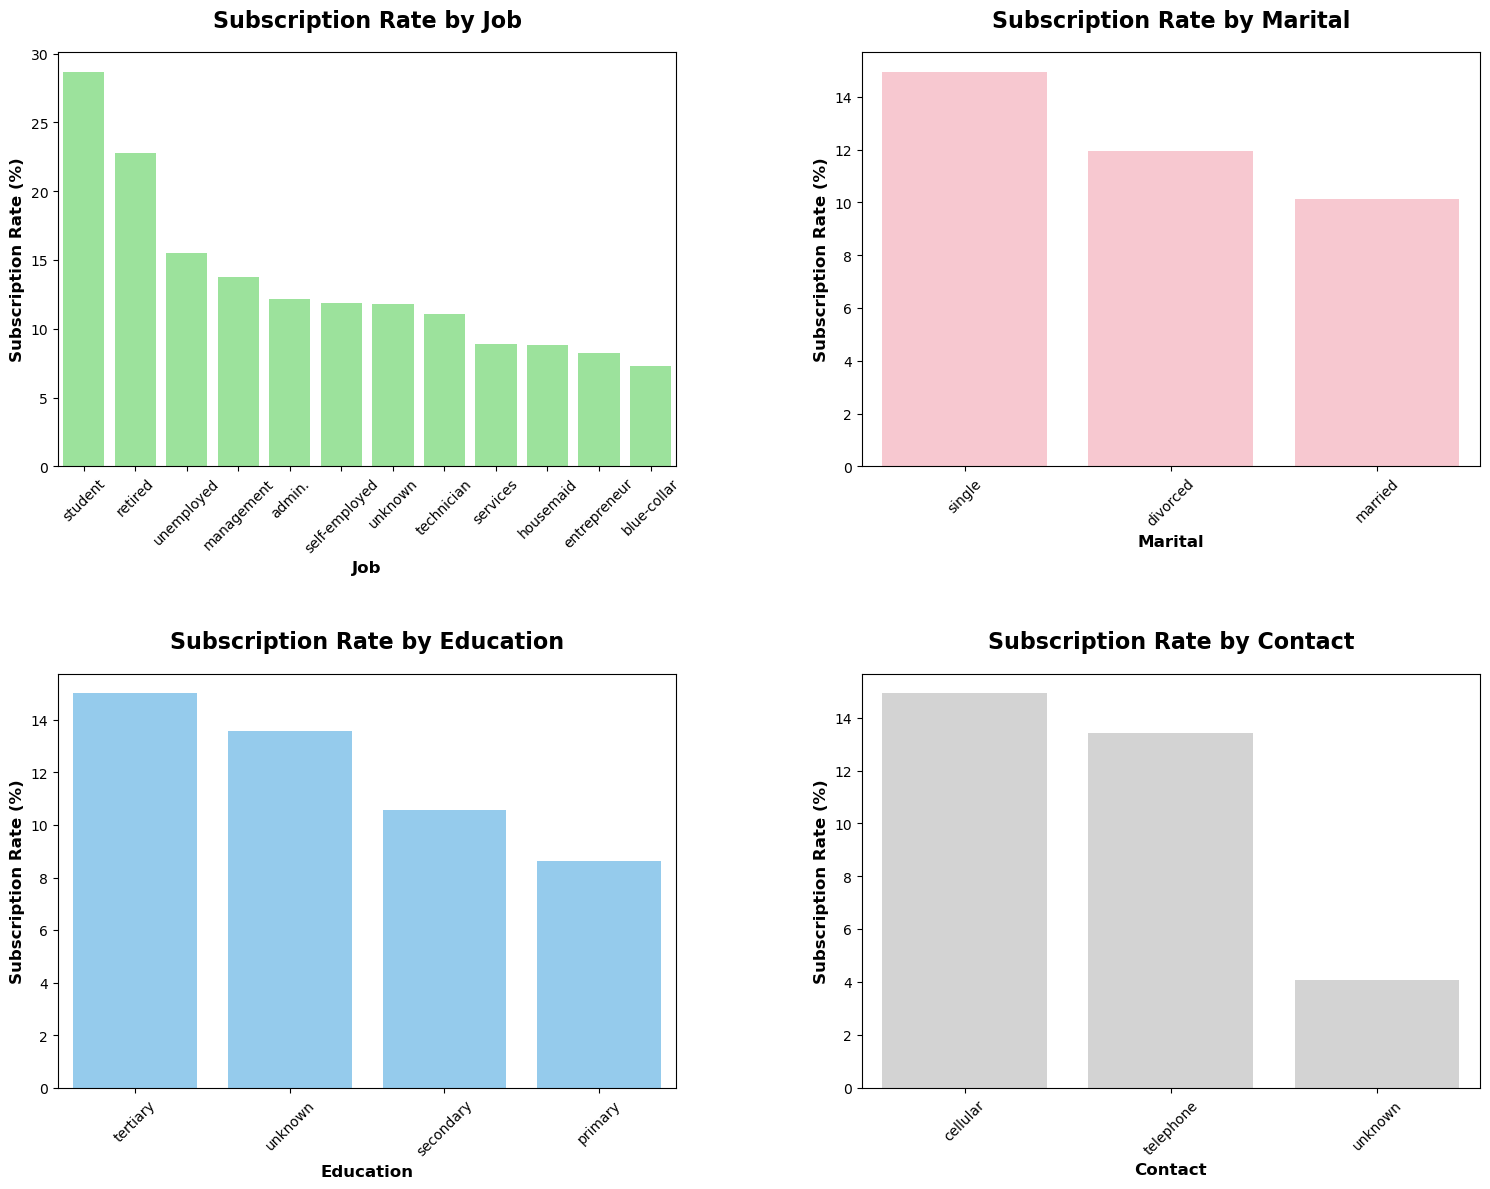

In [322]:
fig, ax = plt.subplots(2, 2, figsize=(15, 12))
ax = ax.flatten()

demographic_columns = ['job', 'marital', 'education', 'contact']
colors = ['lightgreen', 'pink', 'lightskyblue', 'lightgrey']

for i, (col, colour) in enumerate(zip(demographic_columns, colors)):
    # Calculate subscription rate
    subscription_rate = (
        data.groupby(col)['term_deposit']
            .apply(lambda x: (x == 'yes').mean() * 100)
            .sort_values(ascending=False)
    )

    # Plot
    sns.barplot(
        x=subscription_rate.index,
        y=subscription_rate.values,
        color=colour,
        ax=ax[i]
    )

    ax[i].set_title(
        f"Subscription Rate by {col.capitalize()}",
        fontsize=16,
        fontweight='bold', y=1.04
    )
    ax[i].set_xlabel(f"{col.capitalize()}", fontsize=12, fontweight='bold')
    ax[i].set_ylabel("Subscription Rate (%)", fontsize=12, fontweight='bold')
    ax[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.5)
plt.show()

In [323]:
# Subscription rates by month and day of week
display_md("**SEASONAL ANALYSIS**")
print("=" * 30)

# By month
month_subscription = data.groupby('month')['term_deposit'].apply(lambda x: (x == 'yes').mean() * 100)
print("Subscription Rate by Month:")
for month, rate in month_subscription.items():
    count = (data['month'] == month).sum()
    print(f"  {month}: {rate:.1f}% ({count:,} clients)")

# By day of week
day_subscription = data.groupby('day')['term_deposit'].apply(lambda x: (x == 'yes').mean() * 100)
print(f"\nSubscription Rate by Day of Week:")
for day, rate in day_subscription.items():
    count = (data['day'] == day).sum()
    print(f"  {day}: {rate:.1f}% ({count:,} clients)")

**SEASONAL ANALYSIS**

Subscription Rate by Month:
  apr: 19.7% (2,932 clients)
  aug: 11.0% (6,247 clients)
  dec: 46.7% (214 clients)
  feb: 16.6% (2,649 clients)
  jan: 10.1% (1,403 clients)
  jul: 9.1% (6,895 clients)
  jun: 10.2% (5,341 clients)
  mar: 52.0% (477 clients)
  may: 6.7% (13,766 clients)
  nov: 10.2% (3,970 clients)
  oct: 43.8% (738 clients)
  sep: 46.5% (579 clients)

Subscription Rate by Day of Week:
  1: 28.0% (322 clients)
  2: 14.1% (1,293 clients)
  3: 16.5% (1,079 clients)
  4: 15.9% (1,445 clients)
  5: 11.3% (1,910 clients)
  6: 9.4% (1,932 clients)
  7: 8.6% (1,817 clients)
  8: 10.9% (1,842 clients)
  9: 11.5% (1,561 clients)
  10: 23.1% (524 clients)
  11: 12.2% (1,479 clients)
  12: 15.2% (1,603 clients)
  13: 15.2% (1,585 clients)
  14: 11.4% (1,848 clients)
  15: 14.0% (1,703 clients)
  16: 13.6% (1,415 clients)
  17: 9.1% (1,939 clients)
  18: 9.9% (2,308 clients)
  19: 6.9% (1,757 clients)
  20: 7.0% (2,752 clients)
  21: 9.9% (2,026 clients)
  22: 17.0% (905 clients)
  23

In [324]:
pivot_df = data[data['term_deposit'] == 'yes'].pivot_table(
    index='year',
    columns='month',
    values='term_deposit',
    aggfunc='count',
    fill_value=0
)

print(pivot_df)

month  apr  aug  dec  feb  jan  jul  jun  mar  may  nov  oct  sep
year                                                             
2008     0  288    1    0    0  384  201    0  258  220   49    0
2009   451  264   99  255   38   76  241  125  533  147  184  123
2010   126  136    0  186  104  167  104  123  134   36   90  146


In [325]:
import pandas as pd
data_1 = data.copy()

# Calendar order of months
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# Convert month to an ordered categorical
data_1['month'] = pd.Categorical(
    data_1['month'],
    categories=month_order,
    ordered=True
)

# Create a binary subscription column (if not already created)
data_1['subscribed'] = (data_1['term_deposit'] == 'yes').astype(int)

# Pivot table: subscription rate (%)
pivot = (
    data_1.pivot_table(
        index='month',
        columns='year',
        values='subscribed',
        aggfunc='mean',
        fill_value=0
    )
    * 100
)

# Ensure months appear in calendar order
pivot = pivot.sort_index()

print(pivot)

year   2008  2009  2010
month                  
jan    0.00  3.23 45.81
feb    0.00 11.11 52.69
mar    0.00 48.45 56.16
apr    0.00 16.59 58.88
may    3.24  9.56 57.26
jun    4.48 37.54 48.83
jul    6.02 36.71 54.22
aug    5.52 34.20 52.31
sep    0.00 43.62 49.16
oct   61.25 42.01 40.91
nov    6.11 49.49 48.00
dec    7.69 49.25  0.00


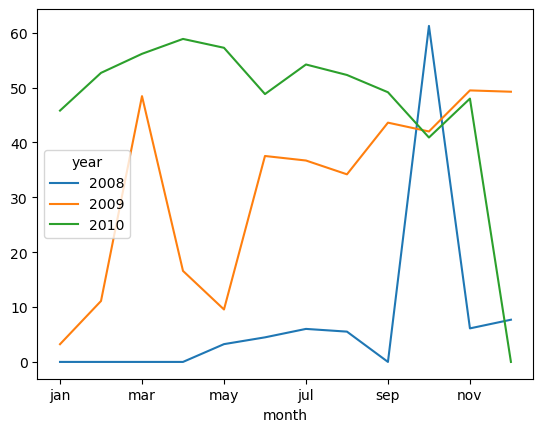

In [326]:
pivot.plot();

In [327]:
# Create a binary column
data_1 = data.copy()
data_1['subscribed'] = (data_1['term_deposit'] == 'yes').astype(int)

# Pivot table
pivot = data_1.pivot_table(
    index='year',
    columns='month',
    values='subscribed',
    aggfunc='mean',
    fill_value=0
) * 100

display(pivot.T.sort_index())

year,2008,2009,2010
month,,,
apr,0.00,16.59,58.88
aug,5.52,34.20,52.31
dec,7.69,49.25,0.00
feb,0.00,11.11,52.69
jan,0.00,3.23,45.81
jul,6.02,36.71,54.22
jun,4.48,37.54,48.83
mar,0.00,48.45,56.16
may,3.24,9.56,57.26


In [328]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'term_deposit', 'age_group', 'balance_category',
       'duration_category', 'contact_frequency_category', 'pdays_category',
       'previous_category', 'year', 'month_numeric', 'year_month', 'age_band'],
      dtype='object')

In [329]:
# Analyze subscription success by campaign characteristics
display_md("**SUBSCRIPTION RATES BY CAMPAIGN CHARACTERISTICS**")
print("=" * 55)

# Analysis by call duration categories
def categorize_duration(duration):
    if duration == 0:
        return 'No Contact'
    elif duration <= 120:
        return 'Short (≤2 min)'
    elif duration <= 300:
        return 'Medium (2-5 min)'
    elif duration <= 600:
        return 'Long (5-10 min)'
    else:
        return 'Very Long (>10 min)'

data['duration_band'] = data['duration'].apply(categorize_duration)
duration_subscription = data.groupby('duration_band')['term_deposit'].apply(lambda x: (x == 'yes').mean() * 100)

print(f"\nBy Call Duration:")
for duration_cat, rate in duration_subscription.items():
    count = (data['duration_band'] == duration_cat).sum()
    print(f"  {duration_cat}: {rate:.1f}% ({count:,} clients)")

# By number of contacts
campaign_subscription = data.groupby('campaign')['term_deposit'].apply(lambda x: (x == 'yes').mean() * 100)
print("\nBy Number of Contacts in Current Campaign:")
for contacts, rate in campaign_subscription[:10].items():
    count = (data['campaign'] == contacts).sum()
    print(f"  {contacts} contact(s): {rate:.1f}% ({count:,} clients)")


**SUBSCRIPTION RATES BY CAMPAIGN CHARACTERISTICS**


By Call Duration:
  Long (5-10 min): 19.2% (8,484 clients)
  Medium (2-5 min): 8.6% (18,893 clients)
  No Contact: 0.0% (3 clients)
  Short (≤2 min): 1.5% (14,041 clients)
  Very Long (>10 min): 48.4% (3,790 clients)

By Number of Contacts in Current Campaign:
  1 contact(s): 14.6% (17,544 clients)
  2 contact(s): 11.2% (12,505 clients)
  3 contact(s): 11.2% (5,521 clients)
  4 contact(s): 9.0% (3,522 clients)
  5 contact(s): 7.9% (1,764 clients)
  6 contact(s): 7.1% (1,291 clients)
  7 contact(s): 6.4% (735 clients)
  8 contact(s): 5.9% (540 clients)
  9 contact(s): 6.4% (327 clients)
  10 contact(s): 5.3% (266 clients)


In [330]:
# compute business impact metrics
display_md("**BUSINESS IMPACT ANALYSIS**")
print("=" * 40)

total_clients = len(data)
successful_subscriptions = (data['term_deposit'] == 'yes').sum()
failed_attempts = (data['term_deposit'] == 'no').sum()
subscription_rate = successful_subscriptions / total_clients *100

print(f"Campaign Overview:")
print(f"   Total clients contacted: {total_clients:,}")
print(f"   Successful subscriptions: {successful_subscriptions:,}")
print(f"   Unsuccessful attempts: {failed_attempts:,}")
print(f"   Success rate: {subscription_rate:.2f}%")

# Calculate efficiency metrics
total_contacts_made = data['campaign'].sum()
avg_contacts_per_client = data['campaign'].mean()
avg_contacts_per_success = data[data['term_deposit'] == 'yes']['campaign'].mean()

print(f"\n Contact Efficiency:")
print(f"   Total contacts made: {total_contacts_made:,}")
print(f"   Average contacts per client: {avg_contacts_per_client:.1f}")
print(f"   Average contacts per successful subscription: {avg_contacts_per_success:.1f}")

# Cost-benefit analysis (hypothetical values)
print(f"\n Hypothetical Cost-Benefit Analysis:")
cost_per_contact = 5  # Assume $5 per contact
revenue_per_subscription = 1000  # Assume $1000 revenue per subscription

total_cost = total_contacts_made * cost_per_contact
total_revenue = successful_subscriptions * revenue_per_subscription
net_profit = total_revenue - total_cost
roi = (net_profit / total_cost) * 100

print(f"   Estimated total cost: ${total_cost:,}")
print(f"   Estimated total revenue: ${total_revenue:,}")
print(f"   Estimated net profit: ${net_profit:,}")
print(f"   Return on Investment (ROI): {roi:.1f}%")


**BUSINESS IMPACT ANALYSIS**

Campaign Overview:
   Total clients contacted: 45,211
   Successful subscriptions: 5,289
   Unsuccessful attempts: 39,922
   Success rate: 11.70%

 Contact Efficiency:
   Total contacts made: 124,956
   Average contacts per client: 2.8
   Average contacts per successful subscription: 2.1

 Hypothetical Cost-Benefit Analysis:
   Estimated total cost: $624,780
   Estimated total revenue: $5,289,000
   Estimated net profit: $4,664,220
   Return on Investment (ROI): 746.5%


In [331]:
# Create a comprehensive statistical summary
display_md("**STATISTICAL SUMMARY**")
print("=" * 30)

# Confidence interval for subscription rate
from scipy import stats
n = len(data)
p = subscription_rate / 100
se = np.sqrt(p * (1 - p) / n)
ci_lower = (p - 1.96 * se) * 100
ci_upper = (p + 1.96 * se) * 100

print(f"Subscription rate: {subscription_rate:.2f}%")
print(f"95% Confidence Interval: [{ci_lower:.2f}%, {ci_upper:.2f}%]")
print(f"Standard Error: {se * 100:.3f}%")

# Sample size adequacy
print(f"\nSample size: {n:,}")
if n >= 1000:
    print("Large sample size - results are statistically robust")
elif n >= 100:
    print(" Moderate sample size - results are reasonably reliable")
else:
    print(" Small sample size - interpret results with caution")


**STATISTICAL SUMMARY**

Subscription rate: 11.70%
95% Confidence Interval: [11.40%, 11.99%]
Standard Error: 0.151%

Sample size: 45,211
Large sample size - results are statistically robust


#### **3.5. Correlation Analysis & Likelihood of a client subscribing**

In [332]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'term_deposit', 'age_group', 'balance_category',
       'duration_category', 'contact_frequency_category', 'pdays_category',
       'previous_category', 'year', 'month_numeric', 'year_month', 'age_band',
       'duration_band'],
      dtype='object')

In [333]:
# convert target feature to numeric for correaltion analysis
df_corr = data[['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'term_deposit','age_band', 'balance_category',
       'duration_band','contact_frequency_category', 'pdays_category',
       'previous_category', 'year', 'month_numeric', 'year_month']]       # not including datetime features: 'year', 'month_numeric', 'year_month'
       
df_corr['term_deposit_numeric'] = (data['term_deposit'] == 'yes').astype(int)

display_md("**Data Preparation for Correlation Analysis :**")
display_md("**Target Feature Conversion : yes=1, no=0**")
display_md(f"**Subscription Rate :** {df_corr['term_deposit_numeric'].mean():.3f}")


**Data Preparation for Correlation Analysis :**

**Target Feature Conversion : yes=1, no=0**

**Subscription Rate :** 0.117

In [334]:
display(df_corr.value_counts())

age  job         marital   education  default  balance  housing  loan  contact    day  month  duration  campaign  pdays  previous  poutcome  term_deposit  age_band  balance_category  duration_band     contact_frequency_category  pdays_category   previous_category    year  month_numeric  year_month  term_deposit_numeric
18   student     single    primary    no       608      no       no    cellular   12   aug    267       1         -1     0         unknown   yes           Under 30  Low ($1-999)      Medium (2-5 min)  Single Contact              Never Contacted  No Previous Contact  2009  8              2009-08-01  1                       1
45   management  married   tertiary   no       0        no       no    cellular   20   aug    71        2         -1     0         unknown   no            40-49     Zero Balance      Short (≤2 min)    2 Contacts                  Never Contacted  No Previous Contact  2008  8              2008-08-01  0                       1
                 divorced  

In [335]:
# First, let's check what features actually exist in DataFrame
display_md("**Available features in the dataset :**")
print(df_corr.columns.tolist())
print(f"\nDataFrame shape: {df_corr.shape}")

**Available features in the dataset :**

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'term_deposit', 'age_band', 'balance_category', 'duration_band', 'contact_frequency_category', 'pdays_category', 'previous_category', 'year', 'month_numeric', 'year_month', 'term_deposit_numeric']

DataFrame shape: (45211, 27)


In [336]:
# Fix the correlation analysis by fixing which features exist
# Define potential numeric feaures(common in banking sectors)
primary_numeric_cols = [
    'age', 'duration', 'campaign', 'pdays', 'previous',
    'emp_var_rate', 'cons_price_idx',
    'cons_conf_idx', 'euribor3m', 'nr_employed', 'term_deposit_numeric',
    # Alternative feature names that might exist
    'emp.var,rate', 'cons.price.idx',
    'cons.conf.idx', 'euribor3m', 'nr.employed', 
    'y', 'term_deposit', 'target'
]

# Check which numeric features belongs to df_corr dataframe
existing_numeric_cols = []
for col in primary_numeric_cols:
    if col in df_corr.columns:
        existing_numeric_cols.append(col)
display_md("**Existing Numeric Features :**")
print(existing_numeric_cols, end="\n")

# Also check for numeric features by data type
numeric_features = df_corr.select_dtypes(include='number').columns.tolist()
display_md("**All Numeric Features in Dataset :**")
print(numeric_features)


**Existing Numeric Features :**

['age', 'duration', 'campaign', 'pdays', 'previous', 'term_deposit_numeric', 'term_deposit']


**All Numeric Features in Dataset :**

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'year', 'month_numeric', 'term_deposit_numeric']


In [344]:
# Correlation Analysis : use only those columns which actually exist
final_numeric_cols = [col for col in numeric_features if col in df_corr.columns]

# compute correlation matrix with existing features
corr_matrix = df_corr[final_numeric_cols].corr()

# Determine target variable (could be 'term_deposit_numeric', 'term_deposit', or 'y')
target_col = None
for possible_target in ['term_deposit_numeric', 'term_deposit', 'y']:
    if possible_target in corr_matrix.columns:
        target_col = possible_target 
        break

if target_col:
    # concentrate on correlation with target feature
    target_corr = corr_matrix[target_col].drop(target_col).sort_values(key=abs, ascending=False)

    display_md("**CORRELATION WITH TERM DEPOSIT SUBSCRIPTION**")
    print("="*60)
    print(f"{'Features':<20} | {'Correlation':>11} | {'Strength':>11}")
    print("-"*60)

    for col, corr in target_corr.items():
        if abs(corr) >= 0.3:
            strength = 'Strong'
        elif abs(corr) >= 0.1:
            strength = 'Moderate'
        elif abs(corr) >= 0.05:
            stength = 'Weak'
        else:
            strength = 'Very Weak'

        direction = 'Positive' if corr > 0 else 'Negative'
        print(f"{col:<16} | {corr:>15.3f} | {strength} {direction}")

else:
    display_md("**Target feature not found. Please check your target feature name.**")

**CORRELATION WITH TERM DEPOSIT SUBSCRIPTION**

Features             | Correlation |    Strength
------------------------------------------------------------
duration         |           0.395 | Strong Positive
year             |           0.330 | Strong Positive
pdays            |           0.104 | Moderate Positive
previous         |           0.093 | Moderate Positive
campaign         |          -0.073 | Moderate Negative
balance          |           0.053 | Moderate Positive
day              |          -0.028 | Very Weak Negative
age              |           0.025 | Very Weak Positive
month_numeric    |           0.019 | Very Weak Positive


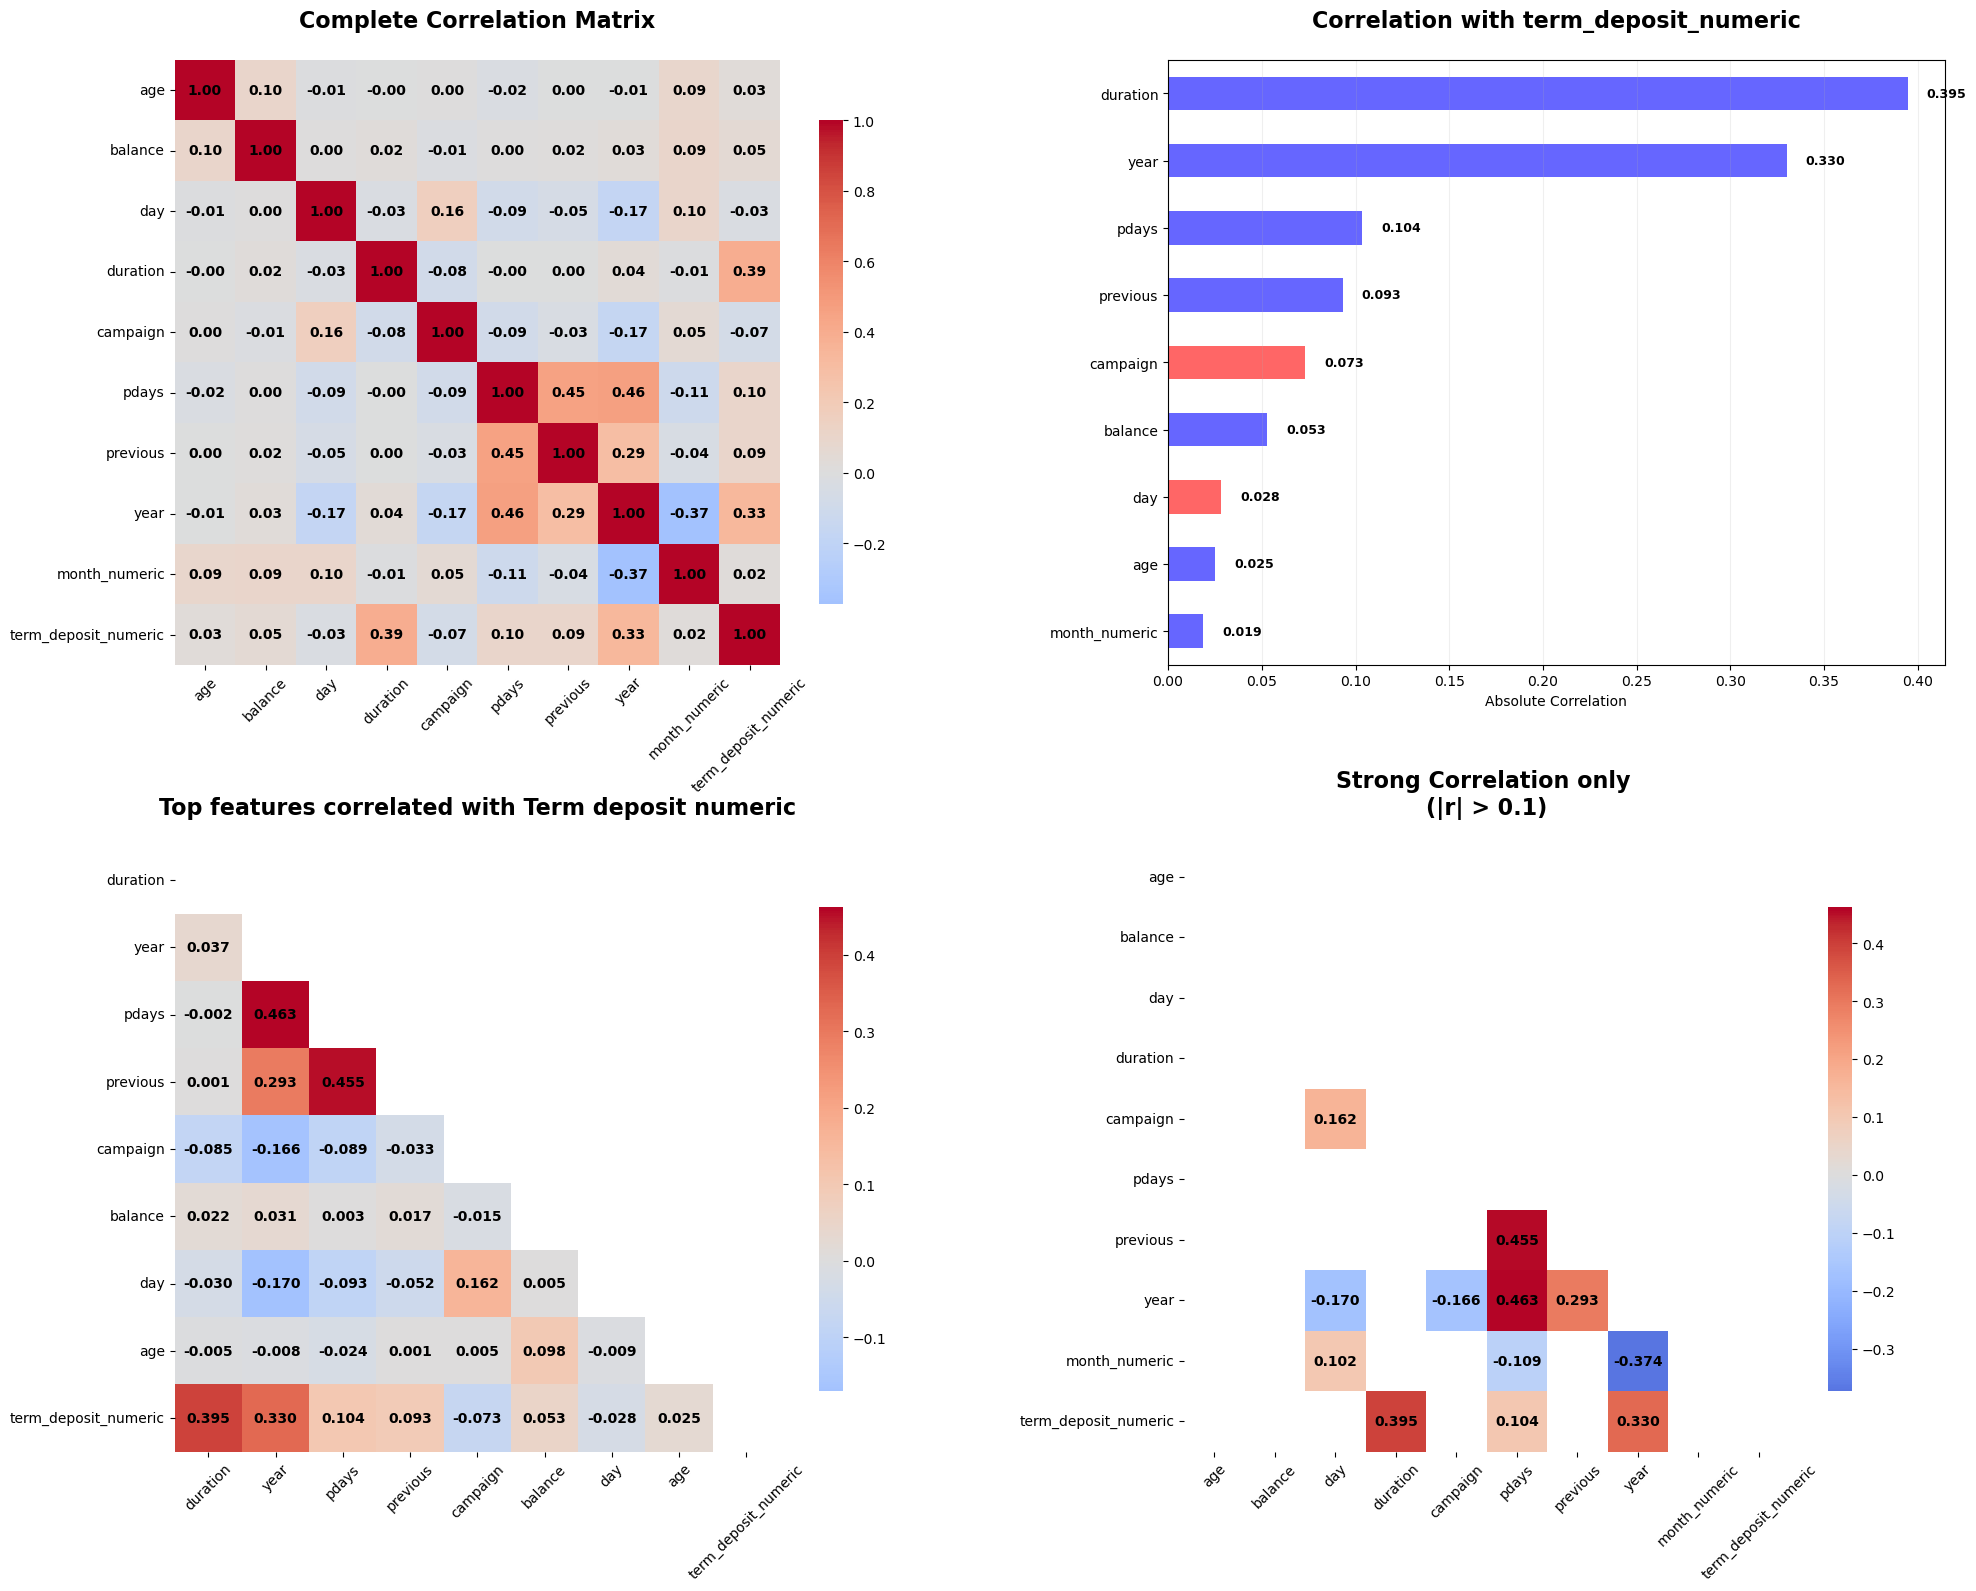

In [343]:
# Create comprehensive correlation matrix visualization
fig, ax = plt.subplots(2, 2, figsize=(20, 16))
ax = ax.flatten()

# 1. Complete correlation matrix heatmap
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', 
    center=0, square=True,
    annot_kws={'fontweight':'bold', 'color':'k'},
    cbar_kws={'shrink':0.8},
    ax=ax[0]
)
ax[0].set_title("Complete Correlation Matrix", fontsize=16, fontweight='bold', y=1.04)
ax[0].tick_params(axis='x', rotation=45)

# 2. bar plot of target feature correlation
if target_col:
    target_correlation = corr_matrix[target_col].drop(target_col)
    target_corr_abs = target_correlation.abs().sort_values(ascending=True)
    colors = ['red' if x < 0 else 'blue' for x in target_correlation[target_corr_abs.index]]

    target_corr_abs.plot(kind='barh', color=colors, ax=ax[1], alpha=0.6)
    ax[1].set_title(f"Correlation with {target_col}", fontsize=16, fontweight='bold', y=1.04)
    ax[1].set_xlabel("Absolute Correlation")
    ax[1].grid(axis='x', alpha=0.2)

    # Label the bar with correlation values
    for index, (column, corr_values) in enumerate(target_corr_abs.items()):
        ax[1].text(abs(corr_values) + 0.01, index, f"{corr_values:.3f}", va='center', fontsize=9, fontweight='bold')

# 3. Top correlated features with target feature
if target_col:
    top_corr_cols = target_correlation.abs().nlargest(8).index.tolist() + [target_col]
    top_corr = corr_matrix.loc[top_corr_cols, top_corr_cols]

    # Create mask for upper triangular matrix
    mask = np.triu(np.ones_like(top_corr, dtype=bool))

    sns.heatmap(top_corr,
                mask=mask,
                annot=True, fmt='.3f',
                cmap='coolwarm',
                center=0, square=True,
                annot_kws={'fontweight':'bold', 'color':'k'},
                cbar_kws={'shrink':0.8},
                ax=ax[2])
    ax[2].set_title(f"Top features correlated with {target_col.replace("_", " ").replace(".", " ").capitalize()}", fontsize=16, fontweight='bold', y=1.04)
    ax[2].tick_params(axis='x', rotation=45)

    # 4. Strong Correlation Only (|Correlation| > 0.1)
    strong_corr_mask = np.abs(corr_matrix) > 0.1
    strong_corr = corr_matrix.where(strong_corr_mask)
    mask = np.triu(np.ones_like(strong_corr, dtype=bool))
    sns.heatmap(
        strong_corr,
        mask=mask,
        annot=True, fmt='.3f',
        cmap='coolwarm',
        center=0, square=True,
        annot_kws={'fontweight':'bold', 'color':'k'},
        cbar_kws={'shrink':0.8},
        ax=ax[3]
    )
    ax[3].set_title("Strong Correlation only \n(|r| > 0.1)", fontsize=16, fontweight='bold', y=1.04)
    ax[3].tick_params(axis='x', rotation=45)
    

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


Target column: term_deposit
Target column type: object
Unique values in target: ['no' 'yes']


**Campaign Contact Analysis :**

,campaign,count,mean
0,1,17544,0.15
1,2,12505,0.11
2,3,5521,0.11
3,4,3522,0.09
4,5,1764,0.08
5,6,1291,0.07
6,7,735,0.06
7,8,540,0.06
8,9,327,0.06
9,10,266,0.05


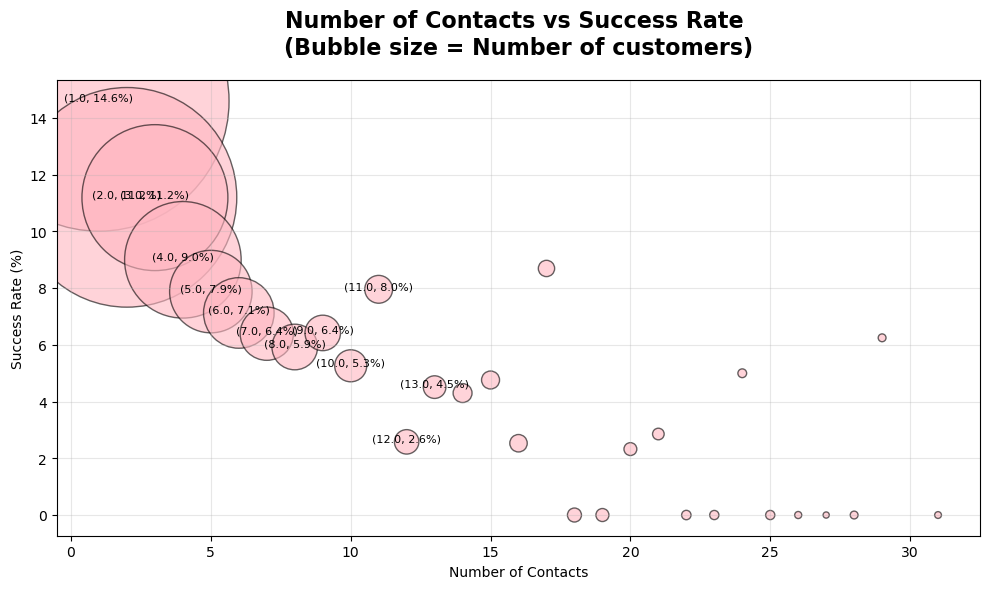

In [ ]:
# Handle both string and numeric target features

#  Campaign contacts vs success
if 'campaign' in df_corr.columns and target_col:
    print(f"Target column: {target_col}")
    print(f"Target column type: {df_corr[target_col].dtype}")
    print(f"Unique values in target: {df_corr[target_col].unique()}")
    
    # Handle different target feature types
    if df_corr[target_col].dtype == 'object':  # String values like 'yes'/'no'
        # Convert to numeric for aggregation
        df_corr['target_numeric'] = (df_corr[target_col] == 'yes').astype(int)
        target_for_agg = 'target_numeric'
    else:  # Already numeric
        target_for_agg = target_col
    
    # Now perform the aggregation
    campaign_data = df_corr.groupby('campaign')[target_for_agg].agg(['count', 'mean']).reset_index()
    campaign_data = campaign_data[campaign_data['count'] >= 10]  # Filter for meaningful sample sizes
    
    display_md("**Campaign Contact Analysis :**")
    display(campaign_data.head(10))

    # Create the scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(campaign_data['campaign'], campaign_data['mean'] * 100, 
               s=campaign_data['count']*2, alpha=0.6, c='lightpink', edgecolors='black')
    plt.xlabel('Number of Contacts')
    plt.ylabel('Success Rate (%)')
    plt.title('Number of Contacts vs Success Rate \n(Bubble size = Number of customers)', fontsize=16, fontweight='bold', y=1.04)
    plt.grid(True, alpha=0.3)

    # Add annotation to bubbles
    for idx, row in campaign_data.iterrows():
        # highlight high success rate and high volume
        if row['mean'] > 0.5 or row['count'] > 100:
            plt.text(row['campaign'], row['mean']*100, 
                     f"({row['campaign']}, {row['mean']*100:.1f}%)",
                     fontsize=8, ha='center')

    plt.tight_layout()
    plt.show()

    

In [168]:
# First, let's properly identify and prepare the target variable
display_md("**TARGET FEATURE PREPARATION**")
print("=" * 40)

# Check what target columns exist
possible_targets = ['y', 'y_numeric', 'term_deposit', 'term_deposit_numeric']
target_col = None

for col in possible_targets:
    if col in df_corr.columns:
        target_col = col
        print(f"Found target column: {col}")
        print(f"Data type: {df_corr[col].dtype}")
        print(f"Unique values: {df_corr[col].unique()}")
        break

if target_col is None:
    print("Available columns:", df_corr.columns.tolist())
    print("Please specify your target column name")
else:
    # Create a numeric version of target for analysis
    if df_corr[target_col].dtype == 'object':
        if 'yes' in df_corr[target_col].values:
            df_corr['target_numeric'] = (df_corr[target_col] == 'yes').astype(int)
        elif 'True' in df_corr[target_col].values:
            df_corr['target_numeric'] = (df_corr[target_col] == 'True').astype(int)
        else:
            # Try to convert to numeric
            df_corr['target_numeric'] = pd.to_numeric(df_corr[target_col], errors='coerce')
    else:
        df_corr['target_numeric'] = df_corr[target_col]
    
    # MARKETING CAMPAIGN OUTCOMES ANALYSIS
    print()
    display_md("**MARKETING CAMPAIGN OUTCOMES ANALYSIS**")
    print("=" * 50)
    
    # 1. Overall Success Rate
    success_rate = df_corr['target_numeric'].mean() * 100
    total_success = df_corr['target_numeric'].sum()
    total_campaigns = len(df_corr)
    
    print(f"Overall Success Rate: {success_rate:.2f}%")
    print(f"Successful Campaigns: {total_success:,}")
    print(f"Total Campaigns: {total_campaigns:,}")
    print(f"Failed Campaigns: {total_campaigns - total_success:,}")
    
    # 2. Previous Campaign Impact
    if 'poutcome' in df_corr.columns:
        print(f"\nPREVIOUS CAMPAIGN OUTCOMES:")
        prev_outcomes = df_corr['poutcome'].value_counts()
        for outcome, count in prev_outcomes.items():
            pct = (count / len(df_corr)) * 100
            print(f"  {outcome}: {count:,} ({pct:.1f}%)")
        
        # Success rate by previous outcome
        print(f"\nSUCCESS RATE BY PREVIOUS CAMPAIGN:")
        prev_success = df_corr.groupby('poutcome')['target_numeric'].mean() * 100
        for outcome, rate in prev_success.sort_values(ascending=False).items():
            print(f"  {outcome}: {rate:.2f}%")
    
    # 3. Campaign Contact Analysis - FIXED
    if 'campaign' in df_corr.columns:
        print(f"\nCAMPAIGN CONTACT ANALYSIS:")
        
        # Basic statistics
        print(f"Average contacts per customer: {df_corr['campaign'].mean():.2f}")
        print(f"Median contacts: {df_corr['campaign'].median():.0f}")
        print(f"Max contacts: {df_corr['campaign'].max()}")
        
        # Success rate by number of contacts - FIXED
        campaign_analysis = df_corr.groupby('campaign').agg({
            'target_numeric': ['count', 'sum', 'mean']
        }).round(3)
        
        # Flatten column names
        campaign_analysis.columns = ['total_customers', 'successful', 'success_rate']
        campaign_analysis = campaign_analysis.reset_index()
        
        # Filter for meaningful sample sizes
        campaign_analysis_filtered = campaign_analysis[campaign_analysis['total_customers'] >= 5]
        
        print(f"\nSUCCESS RATE BY NUMBER OF CONTACTS (min 5 customers):")
        top_performers = campaign_analysis_filtered.nlargest(5, 'success_rate')
        for _, row in top_performers.iterrows():
            print(f"  {row['campaign']} contacts: {row['success_rate']*100:.1f}% "
                  f"({row['successful']:.0f}/{row['total_customers']:.0f})")
    
    # 4. Call Duration Analysis
    if 'duration' in df_corr.columns:
        print(f"\nCALL DURATION ANALYSIS:")
        print(f"Average duration: {df_corr['duration'].mean():.0f} seconds")
        print(f"Median duration: {df_corr['duration'].median():.0f} seconds")
        
        # Duration bins analysis
        df_corr['duration_'] = pd.cut(df_corr['duration'], 
                                            bins=[0, 120, 300, 600, float('inf')], 
                                            labels=['Very Short (<2min)', 'Short (2-5min)', 
                                                   'Medium (5-10min)', 'Long (>10min)'])
        
        duration_success = df_corr.groupby('duration_category')['target_numeric'].agg(['count', 'mean'])
        print(f"\nSUCCESS RATE BY CALL DURATION:")
        for category, row in duration_success.iterrows():
            print(f"  {category}: {row['mean']*100:.1f}% ({row['count']:,} calls)")
            

**TARGET FEATURE PREPARATION**

Found target column: term_deposit
Data type: object
Unique values: ['no' 'yes']



**MARKETING CAMPAIGN OUTCOMES ANALYSIS**

Overall Success Rate: 11.70%
Successful Campaigns: 5,289
Total Campaigns: 45,211
Failed Campaigns: 39,922

PREVIOUS CAMPAIGN OUTCOMES:
  unknown: 36,959 (81.7%)
  failure: 4,901 (10.8%)
  other: 1,840 (4.1%)
  success: 1,511 (3.3%)

SUCCESS RATE BY PREVIOUS CAMPAIGN:
  success: 64.73%
  other: 16.68%
  failure: 12.61%
  unknown: 9.16%

CAMPAIGN CONTACT ANALYSIS:
Average contacts per customer: 2.76
Median contacts: 2
Max contacts: 63

SUCCESS RATE BY NUMBER OF CONTACTS (min 5 customers):
  1.0 contacts: 14.6% (2561/17544)
  2.0 contacts: 11.2% (1401/12505)
  3.0 contacts: 11.2% (618/5521)
  32.0 contacts: 11.1% (1/9)
  4.0 contacts: 9.0% (317/3522)

CALL DURATION ANALYSIS:
Average duration: 258 seconds
Median duration: 180 seconds

SUCCESS RATE BY CALL DURATION:
  Very Short (<2min): 1.5% (14,041.0 calls)
  Short (2-5min): 8.6% (18,893.0 calls)
  Medium (5-10min): 19.2% (8,484.0 calls)
  Long (>10min): 48.4% (3,790.0 calls)


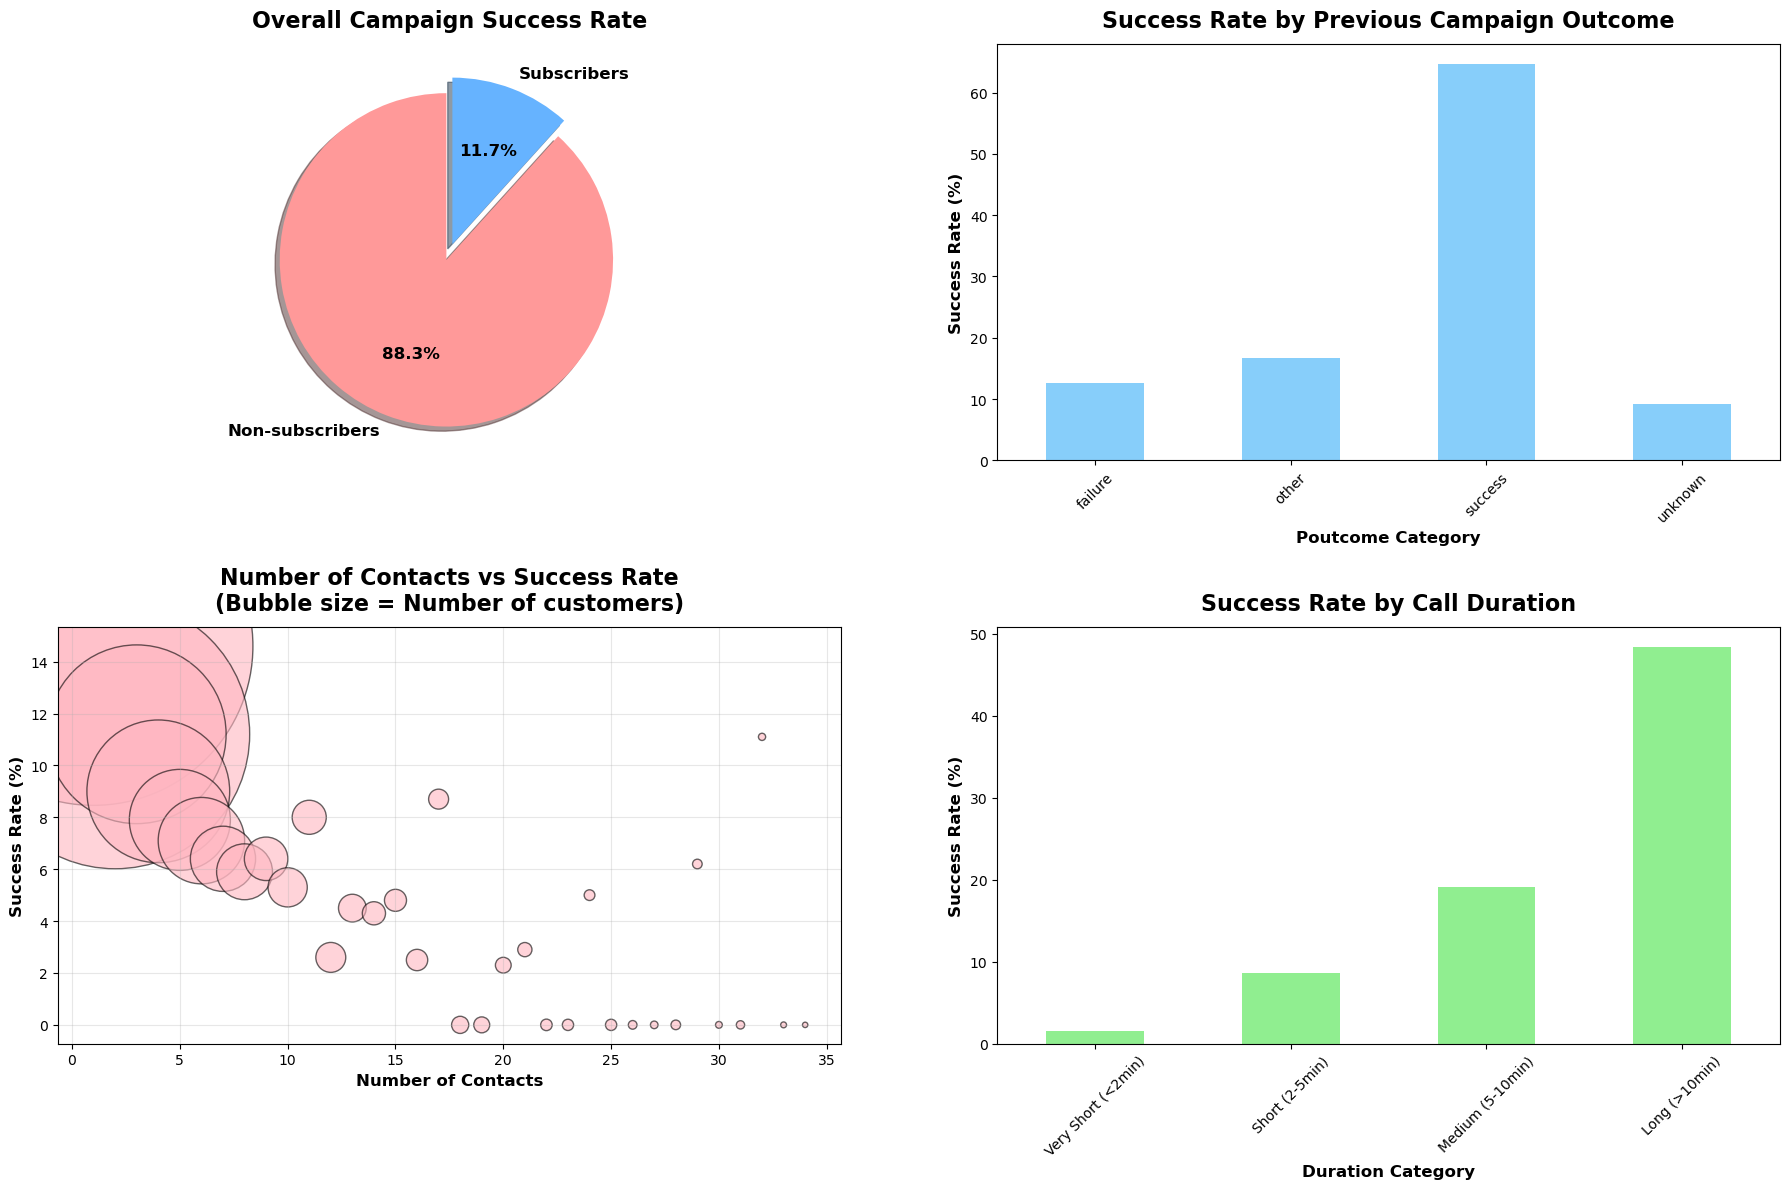

**KEY INSIGHTS FROM MARKETING CAMPAIGNS :**

1. Overall campaign success rate: 11.7%
2. Best previous campaign outcome: success (64.7% success)
3. Optimal number of contacts: 1 (14.6% success)
4. Most effective call duration: Long (>10min) (0.5% success)


In [178]:
# Create visualizations 
fig, ax = plt.subplots(2, 2, figsize=(18, 12))
ax=ax.flatten()

# 1. Overall Success Rate Pie Chart
success_counts = df_corr['target_numeric'].value_counts()
ax[0].pie(success_counts.values, labels=['Non-subscribers', 'Subscribers'], 
              autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'],
              explode=(0.05, 0.05), shadow=True, startangle=90,
              textprops = {'fontsize':12, 'weight':'bold', 'color':'k'})
ax[0].set_title('Overall Campaign Success Rate', fontsize=16, fontweight='bold', y=1.02)

# 2. Previous Campaign Impact
if 'poutcome' in df_corr.columns:
    prev_impact = df_corr.groupby('poutcome')['target_numeric'].mean() * 100
    prev_impact.plot(kind='bar', ax=ax[1], color='lightskyblue')
    ax[1].set_title('Success Rate by Previous Campaign Outcome', fontsize=16, fontweight='bold', y=1.02)
    ax[1].set_xlabel("Poutcome Category", fontsize=12, fontweight='bold')
    ax[1].set_ylabel('Success Rate (%)', fontsize=12, fontweight='bold')
    ax[1].tick_params(axis='x', rotation=45)

# 3. Campaign Contacts vs Success - FIXED
if 'campaign' in df_corr.columns:
    # Use the fixed campaign_analysis_filtered from above
    ax[2].scatter(campaign_analysis_filtered['campaign'],
                  campaign_analysis_filtered['success_rate'] * 100,
                  s=campaign_analysis_filtered['total_customers']*3, 
                  alpha=0.6, c='lightpink', edgecolors='black')
    ax[2].set_xlabel('Number of Contacts', fontsize=12, fontweight='bold')
    ax[2].set_ylabel('Success Rate (%)', fontsize=12, fontweight='bold')
    ax[2].set_title('Number of Contacts vs Success Rate\n(Bubble size = Number of customers)', fontsize=16, fontweight='bold', y=1.02)
    ax[2].grid(True, alpha=0.3)

# 4. Duration Impact
if 'duration_category' in df_corr.columns:
    duration_impact = df_corr.groupby('duration_category')['target_numeric'].mean() * 100
    duration_impact.plot(kind='bar', color='lightgreen', ax=ax[3])
    ax[3].set_title('Success Rate by Call Duration', fontsize=16, fontweight='bold', y=1.02)
    ax[3].set_ylabel('Success Rate (%)', fontsize=12, fontweight='bold')
    ax[3].set_xlabel("Duration Category", fontsize=12, fontweight='bold')
    ax[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.4)
plt.show()

# Summary insights
display_md("**KEY INSIGHTS FROM MARKETING CAMPAIGNS :**")
print("=" * 55)
print(f"1. Overall campaign success rate: {success_rate:.1f}%")

if 'poutcome' in df_corr.columns:
    best_prev = prev_success.idxmax()
    best_prev_rate = prev_success.max()
    print(f"2. Best previous campaign outcome: {best_prev} ({best_prev_rate:.1f}% success)")

if 'campaign' in df_corr.columns and len(campaign_analysis_filtered) > 0:
    optimal_contacts = campaign_analysis_filtered.loc[campaign_analysis_filtered['success_rate'].idxmax(), 'campaign']
    optimal_rate = campaign_analysis_filtered['success_rate'].max() * 100
    print(f"3. Optimal number of contacts: {optimal_contacts} ({optimal_rate:.1f}% success)")

if 'duration_category' in df_corr.columns:
    best_duration = duration_success['mean'].idxmax()
    best_duration_rate = duration_success['mean'].max()
    print(f"4. Most effective call duration: {best_duration} ({best_duration_rate:.1f}% success)")


**4.1. Numerical-Numerical**

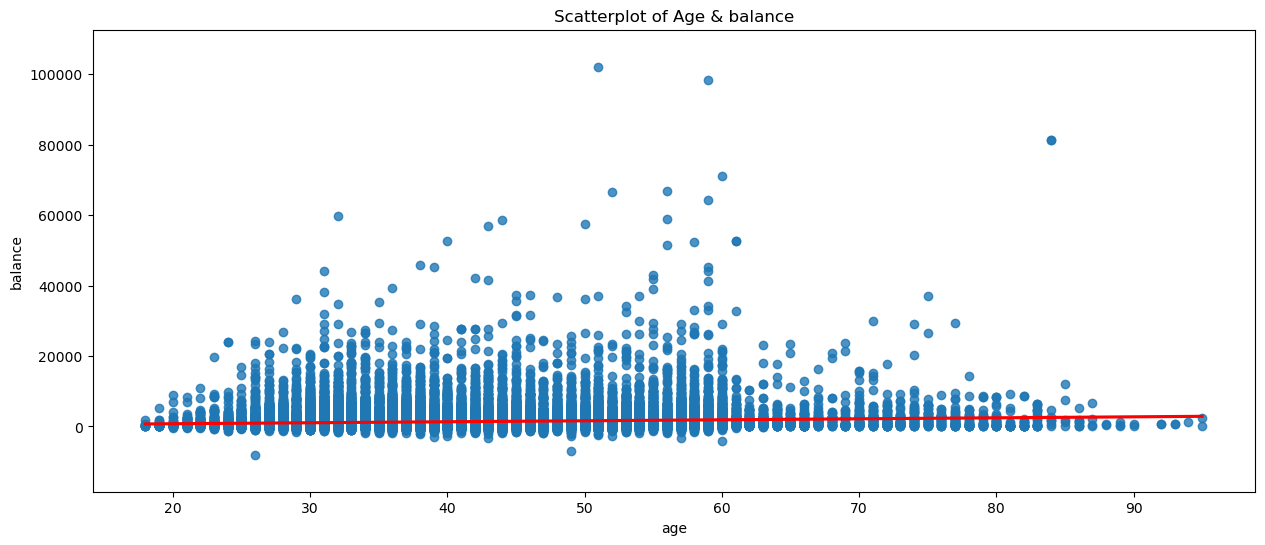

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
sns.regplot(data=data, x='age', y='balance', line_kws={"color":"red"}, ax=ax)

bottom, top = ax.get_ylim()
ax.set_ylim(bottom-5000, top + 5000)
ax.set_title("Scatterplot of Age & balance")

plt.show()

**Insight :**

- The dataset likely has balances centered around zero (many negative and positive values).

- balance is independent of age in this linear fit.


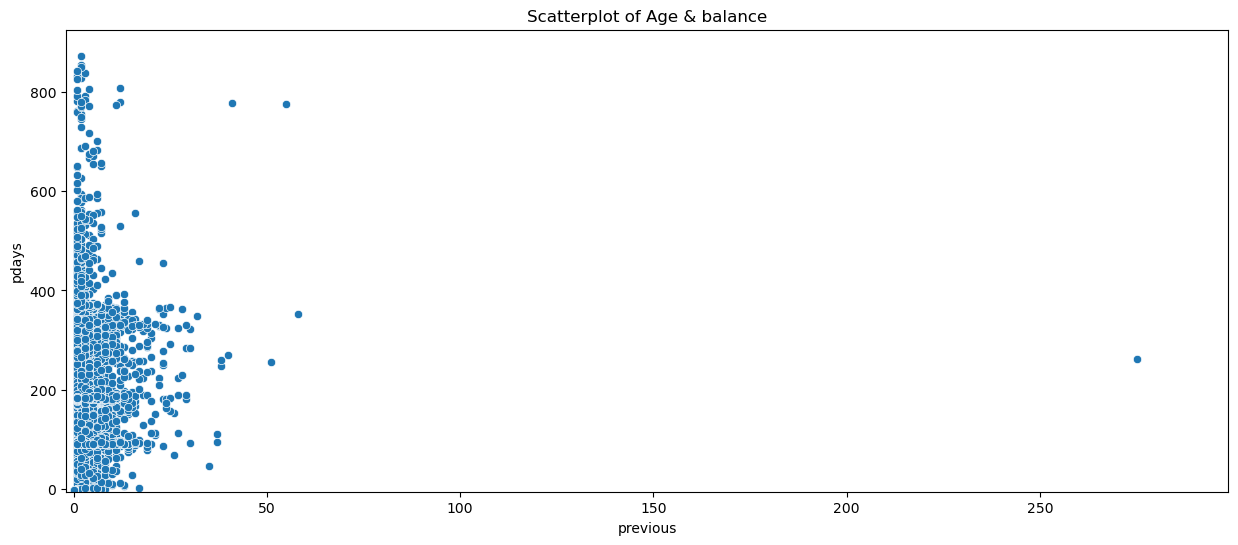

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
sns.scatterplot(data=data, x='previous', y='pdays', ax=ax)

bottom, top = ax.get_ylim()
ax.set_ylim(-5, top + 10)
ax.set_xlim(-2, ax.get_xlim()[1]+10)
ax.set_title("Scatterplot of Age & balance")

plt.show()

## **5. Multivariate analysis**

## **6. Outliers Analysis & Treatment**

In [ ]:
# since duration = 0 doesn't have predictive power, we can drop it
new_df = data.query('duration > 0').reset_index(drop=True)
new_df.shape

(45208, 28)

In [ ]:
print(f"Duplicate rows : {new_df.duplicated().sum()}", end="\n\n")
display(new_df.stb.missing().query('percent > 0'))

Duplicate rows : 0



,missing,total,percent


In [ ]:
# plot outliers for numeric columns
def inspect_outliers(df:pd.DataFrame):
    # store numeric columns 
    numeric_col = df.select_dtypes(include=['number']).columns
    # iterate through each numeric column
    for col in numeric_col:
        fig, ax = plt.subplots(ncols=2, figsize=(15, 5))
        sns.boxplot(data=df, x = col, ax=ax[0], fill=False, color='k', flierprops=dict(marker='o', markerfacecolor='r'))
        sns.histplot(data=df, x = col, ax=ax[1], kde=False, color='lightblue')
        plt.suptitle(f'Outliers Analysis for {col.capitalize()}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

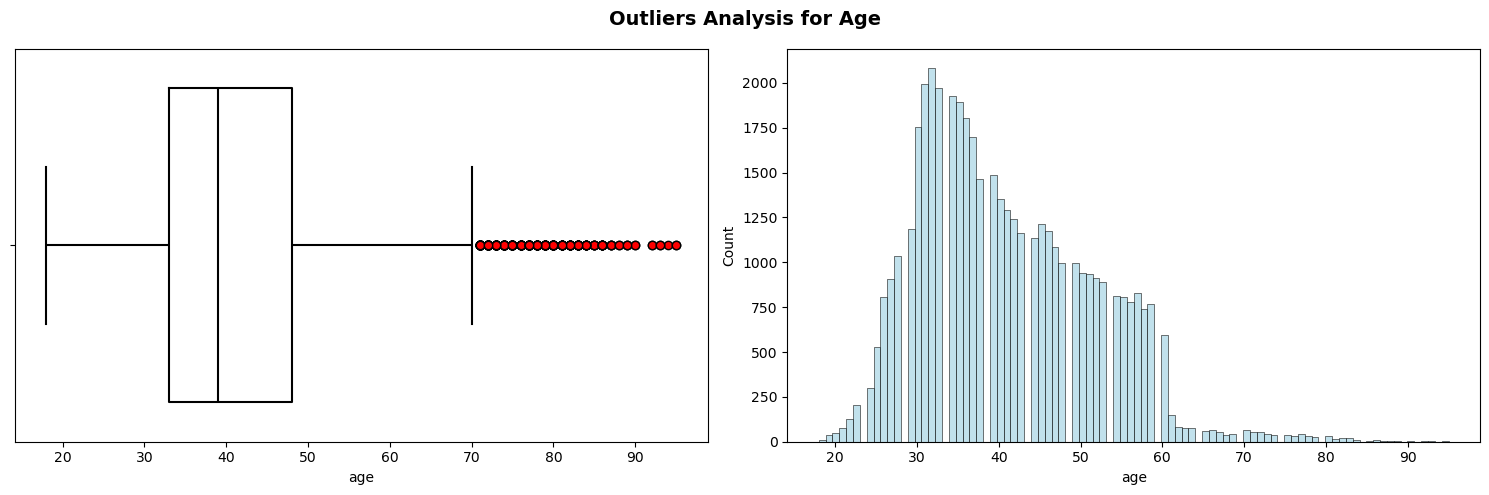

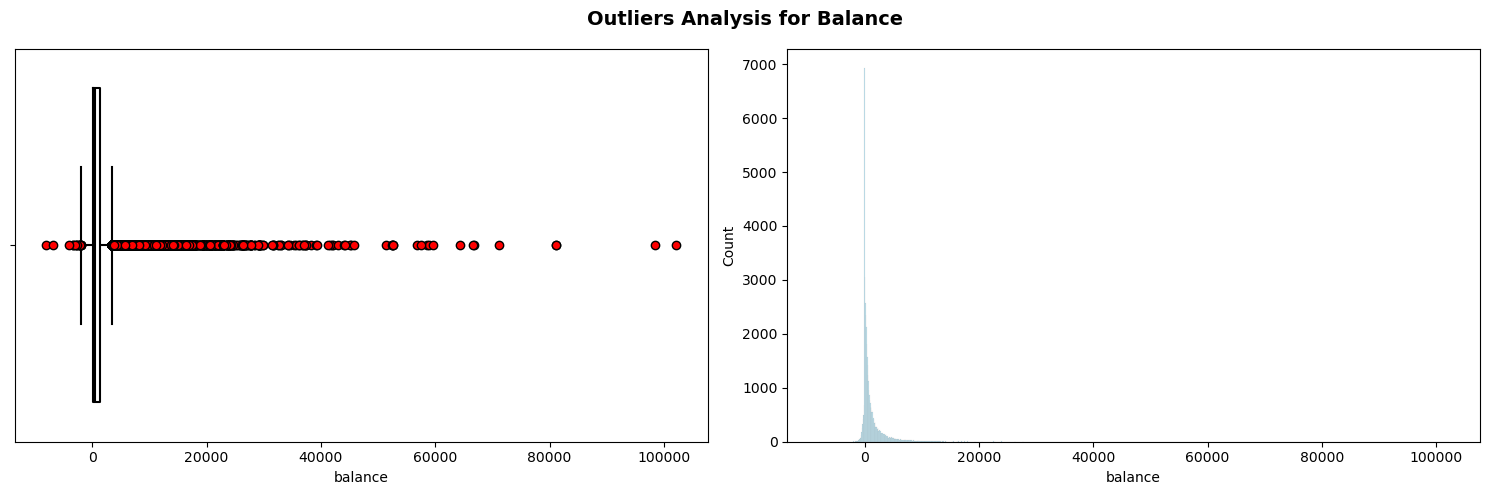

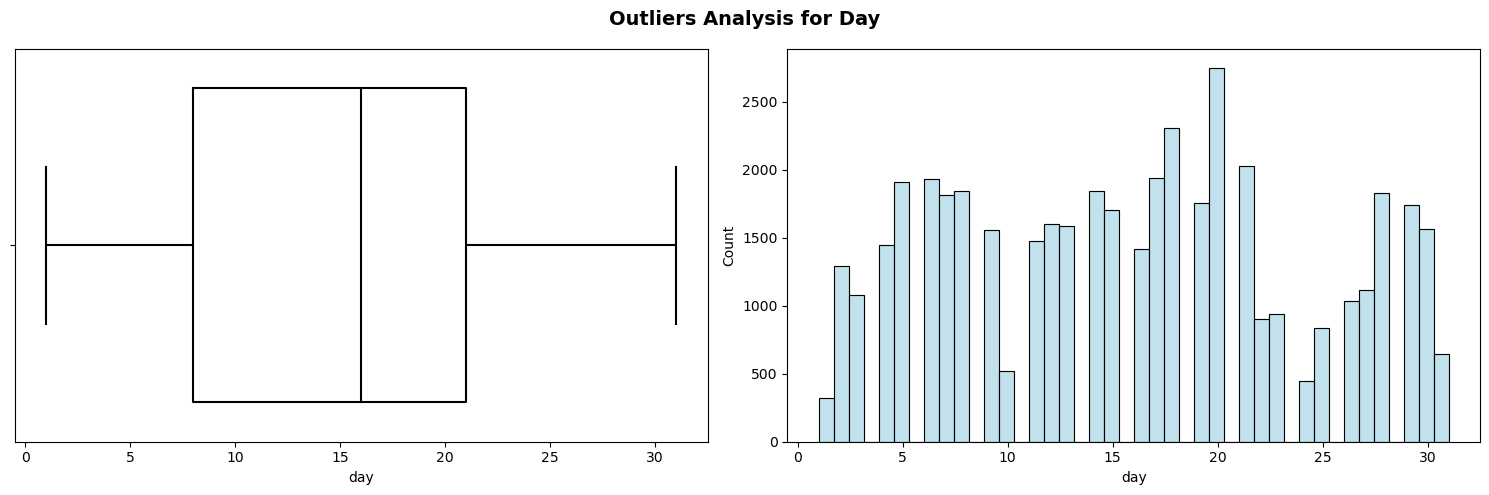

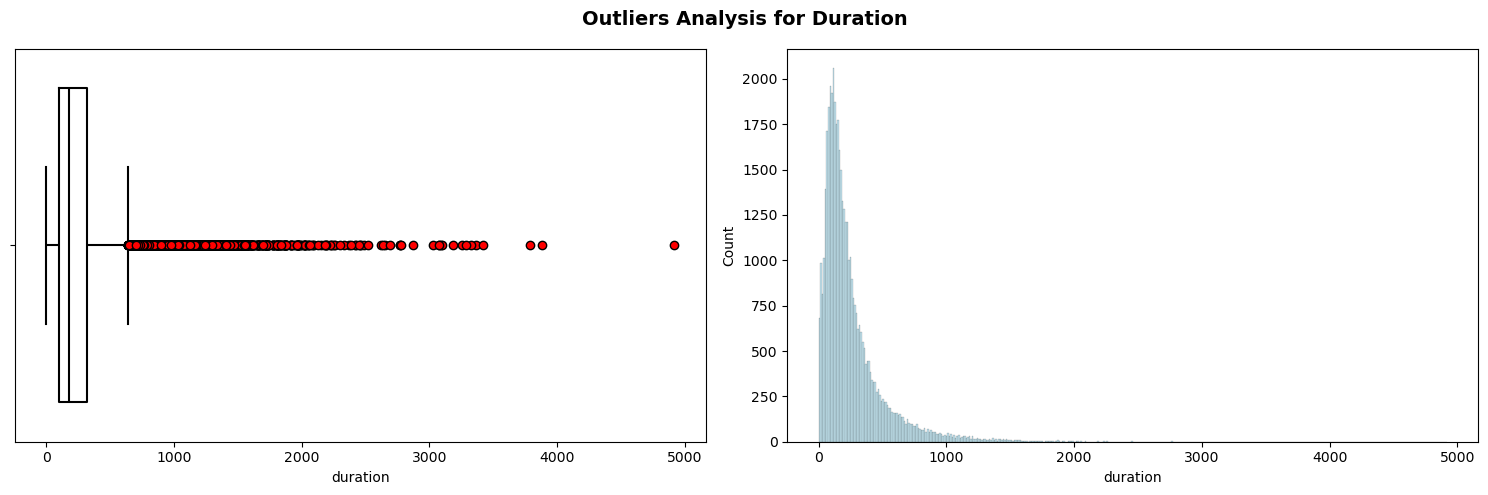

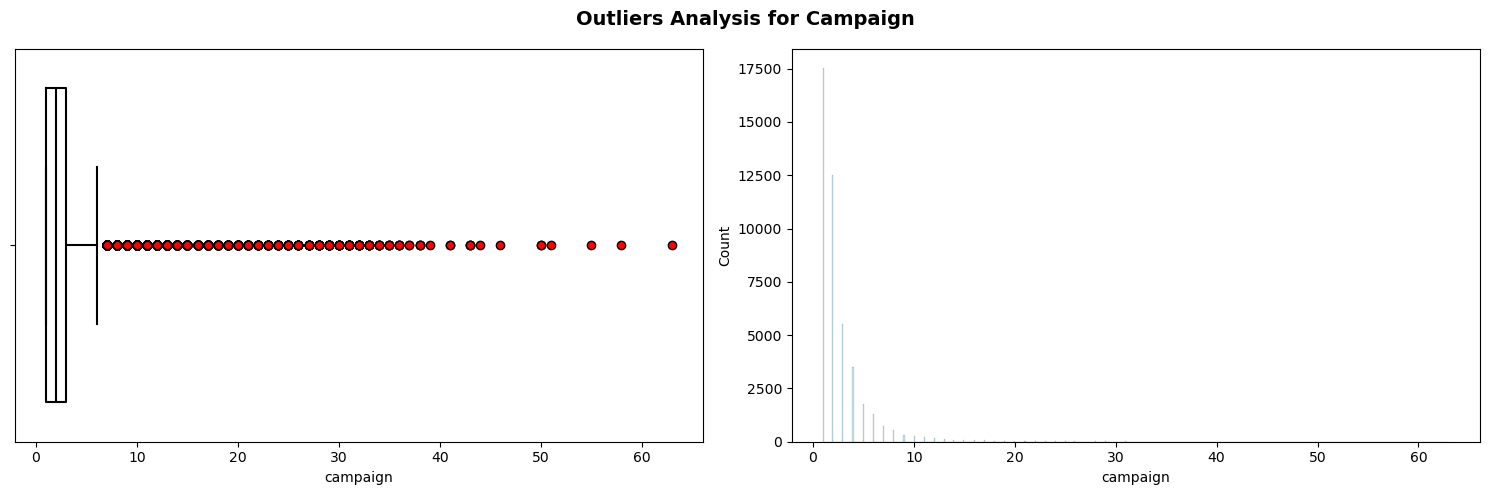

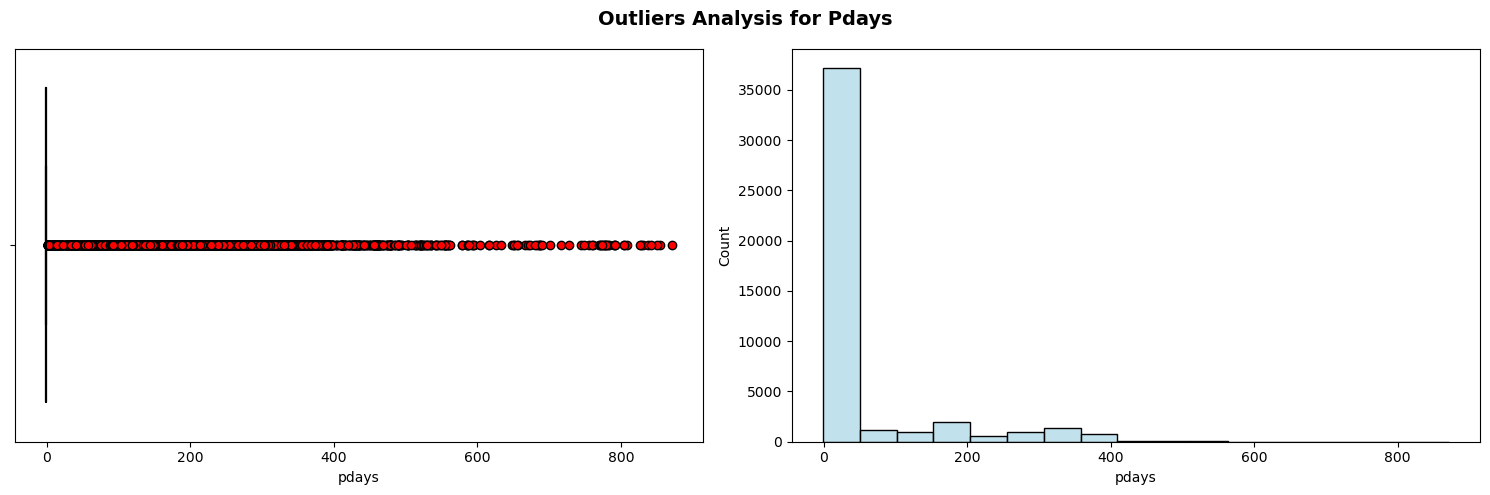

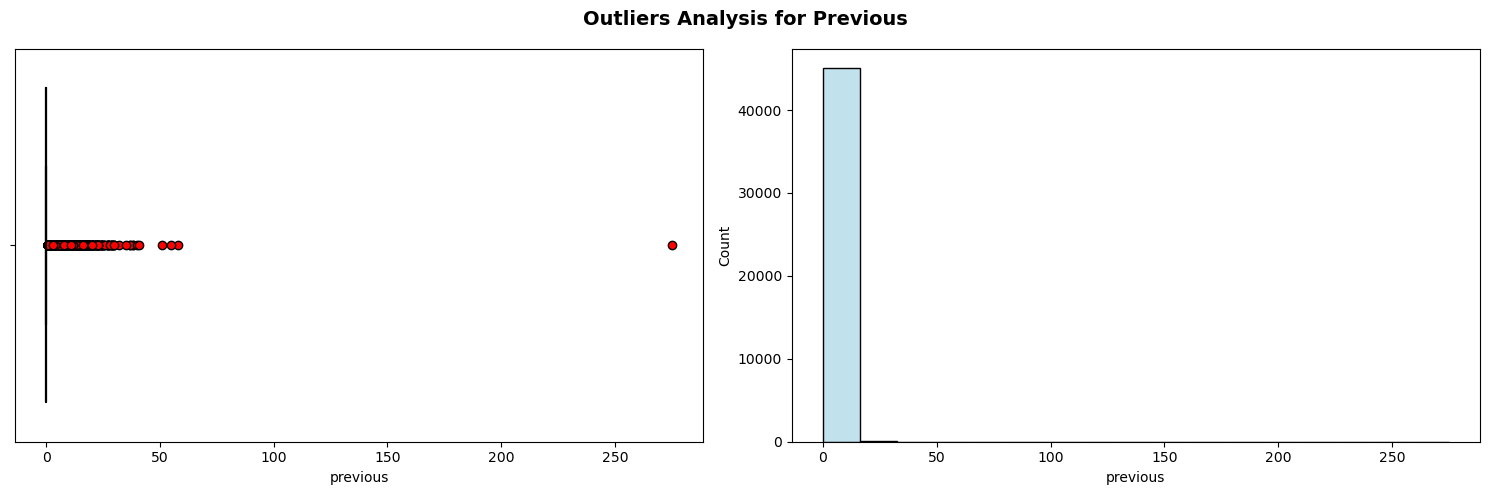

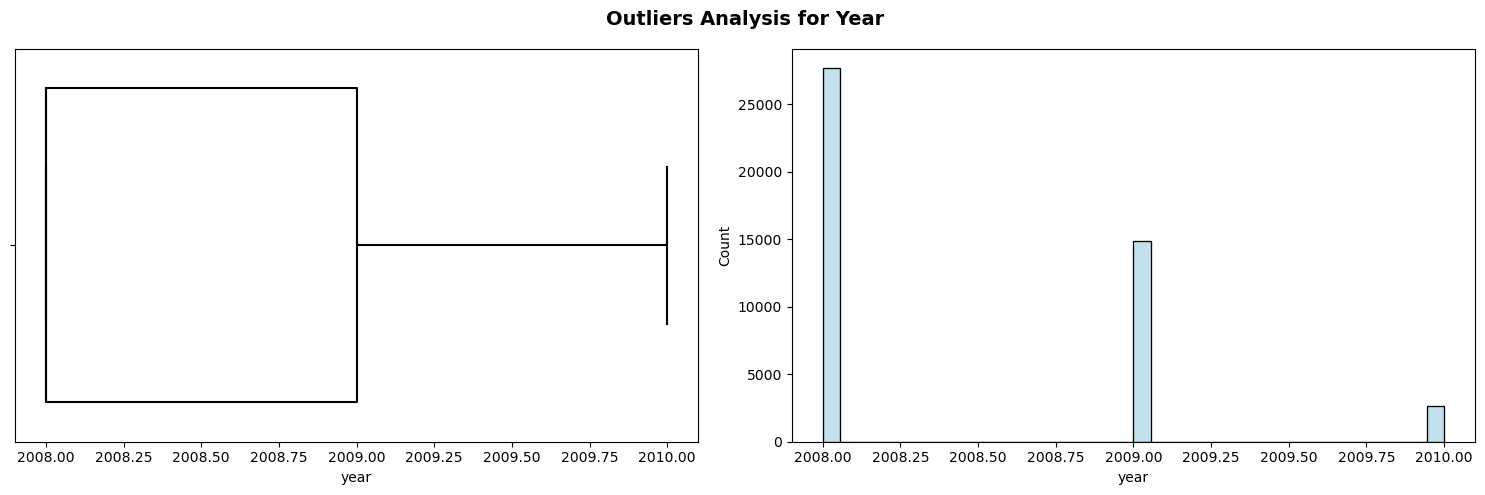

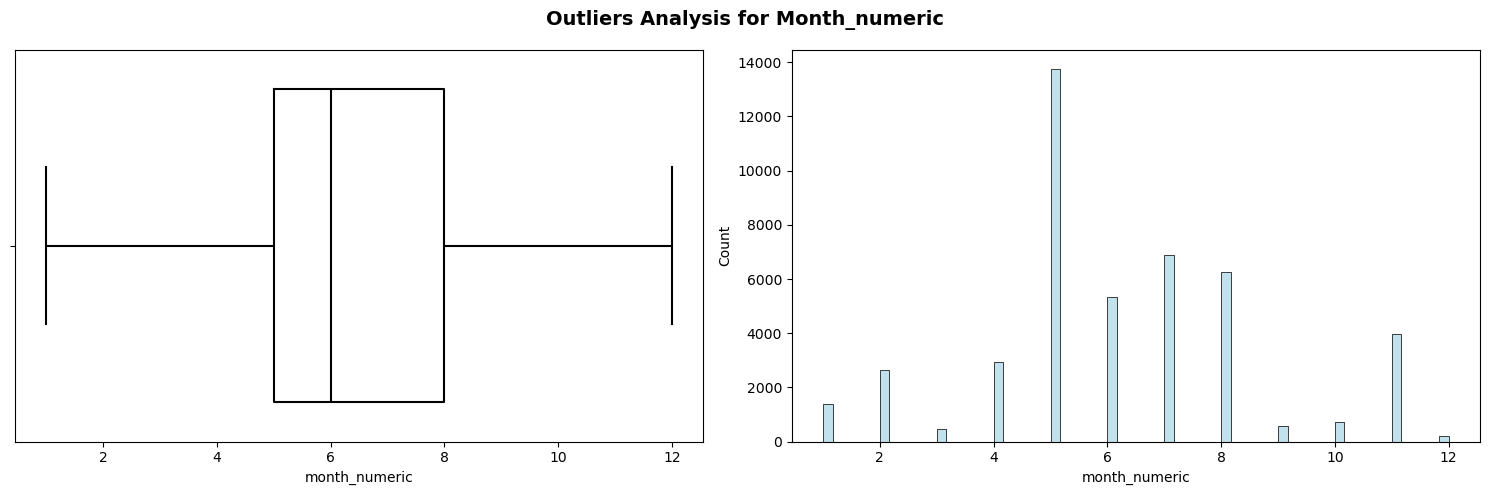

In [ ]:
inspect_outliers(new_df)

In [ ]:
# outliers percentage in each features
def calculate_outlier_percentage(df:pd.DataFrame, lower_percentile:float=5, upper_percentile: float=95) -> pd.DataFrame:
    """
    Calculate the percentage of outliers based on winsorized method for all the numeric columns in the DataFrame.

    Parameters:
    df(pd.DataFrame): The input DataFrame containing numerical features.
    lower_percentile(float): The lower percentile foe winsorization. Default is 5.
    upper_percentile(float): The upper percentile for winsorization. Default is 95.


    Returns:
    pd.DataFrame: A DataFrame contains features name along w.r.t their outlier percentage in it.
    """
    num_col = new_df.select_dtypes(include='number').columns
    variable = []
    outlier = []

    for col in num_col:
        x_low, x_high = np.percentile(new_df[col], [lower_percentile, upper_percentile])
        total = len(new_df[col])
        outliers_len = len(df[~df[col].between(x_low, x_high)])
        outlier_percentage = round((outliers_len/total)*100, 2)
        variable.append(col)
        outlier.append(outlier_percentage)

    outlier_df = pd.DataFrame(zip(variable, outlier), columns=['Features', 'Outliers Percentage'])
    return outlier_df

In [ ]:
anamoly_df = calculate_outlier_percentage(new_df, lower_percentile=1, upper_percentile=99)
anamoly_df.sort_values(by=['Outliers Percentage'],ascending=False).reset_index(drop=True)

,Features,Outliers Percentage
0,balance,2.00
1,duration,1.92
2,age,1.63
3,campaign,1.00
4,previous,1.00
5,pdays,0.85
6,day,0.71
7,month_numeric,0.47
8,year,0.00


In [ ]:
# Outlier Treatment using winsorization method 
def outlier_by_wisorize(df: pd.DataFrame, lower_percent:float=5, upper_percent:float=95, exclude_col:list=None)->pd.DataFrame:
    """
    A DataFrame with numeric columns in it.
    
    Parameters:
    df: the input DataFrame
    lower_percent: float value which by default take 5.
    upper_percent: float value which by default take 95.

    Return:
    A DataFrame without outliers.
    """
    df_winsorize = df.copy()
    num_col = df.select_dtypes(include='number').columns
    winsorize_col = set(num_col) - set(exclude_col) if exclude_col else num_col
    
    for col in winsorize_col:
        x_low, x_high = np.percentile(df[col],[lower_percent, upper_percent])
        df_winsorize[col] = np.where(df_winsorize[col] < x_low, x_low, df_winsorize[col]) # lower capping
        df_winsorize[col] = np.where(df_winsorize[col] > x_high, x_high, df_winsorize[col]) # upper capping

    return df_winsorize


In [ ]:
winsorize_df = outlier_by_wisorize(new_df, lower_percent=1, upper_percent=99, exclude_col=['pdays'])

In [ ]:
# check statistical difference or not of outlier capping on numeric columns
def plot_kde_before_after(df:pd.DataFrame, winsorize_df:pd.DataFrame, exclude_col:list):
    """
    Plot KDE for all numeric columns before and after winsorization and calculate wilcoxon rank-sum test results.

    Parameters:
    df: pd.DataFrame the original dataframe
    winsorize_df: winsorize method dataframe
    exclude_col: List of column to exclude from plotting
    """
    num_col = df.select_dtypes(include='number').columns
    plot_col = set(num_col) - set(exclude_col) if exclude_col else num_col

    #plot kdeplot
    for col in plot_col:
        fig, ax = plt.subplots(1,1, figsize=(8,4))
        sns.kdeplot(df[col], ax=ax, label='Original', fill=True)
        sns.kdeplot(winsorize_df[col], ax=ax, label='Winsorized', fill=True)
        plt.title(f"KDE Plot for {col.capitalize()}", fontweight='bold')
        plt.xlabel(f"{col.capitalize()}", fontweight='bold')
        plt.ylabel('Density', fontweight='bold')
        plt.legend(labelcolor='linecolor')

        plt.tight_layout()
        plt.show()
        # Wilcoxon rank-sum test
        u_stats, p_value = stats.mannwhitneyu(df[col], winsorize_df[col])
        print(f"Wilcoxon rank-sum test for '{col}' : U Statistic: {u_stats:.4f}, P-Value: {p_value:.4f}")
        if p_value < 0.05:
            print(f"The Distributions of '{col}' are statistically different (p_value < 0.05).")
        else:
            print(f"The Distributions of '{col}' are not statistically different (p_value > 0.05).")

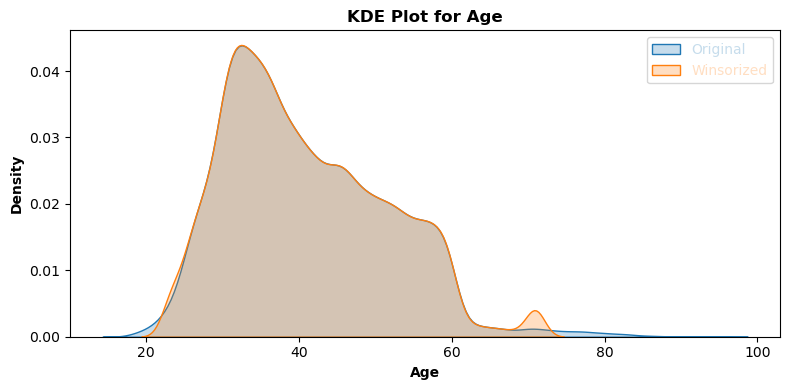

Wilcoxon rank-sum test for 'age' : U Statistic: 1021909750.0000, P-Value: 0.9943
The Distributions of 'age' are not statistically different (p_value > 0.05).


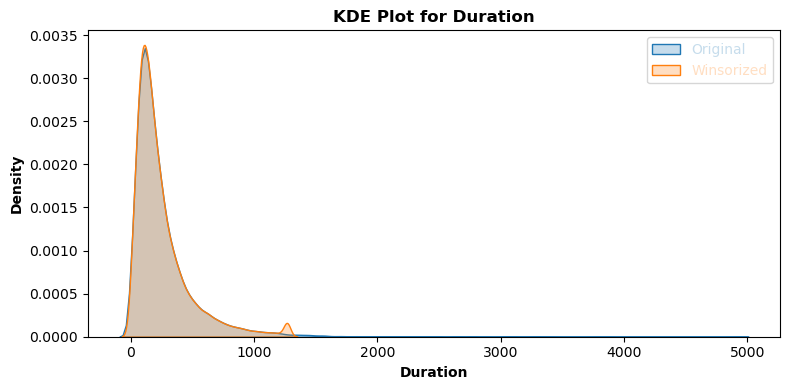

Wilcoxon rank-sum test for 'duration' : U Statistic: 1021877996.0000, P-Value: 0.9993
The Distributions of 'duration' are not statistically different (p_value > 0.05).


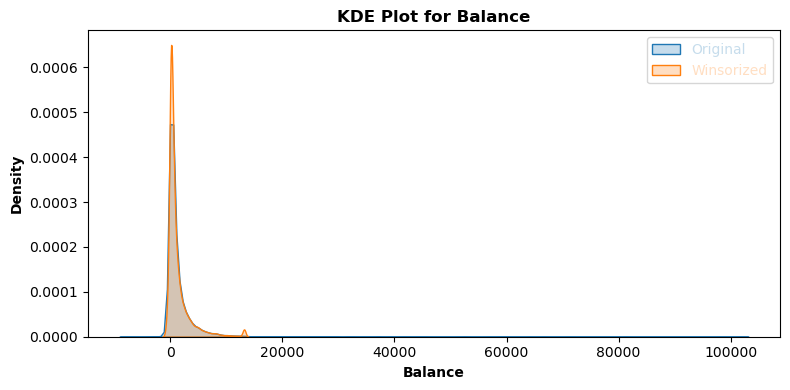

Wilcoxon rank-sum test for 'balance' : U Statistic: 1021882086.5000, P-Value: 0.9999
The Distributions of 'balance' are not statistically different (p_value > 0.05).


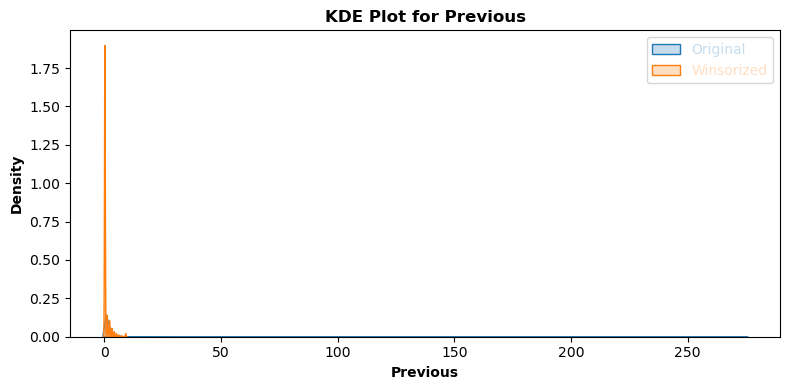

Wilcoxon rank-sum test for 'previous' : U Statistic: 1021984236.5000, P-Value: 0.9690
The Distributions of 'previous' are not statistically different (p_value > 0.05).


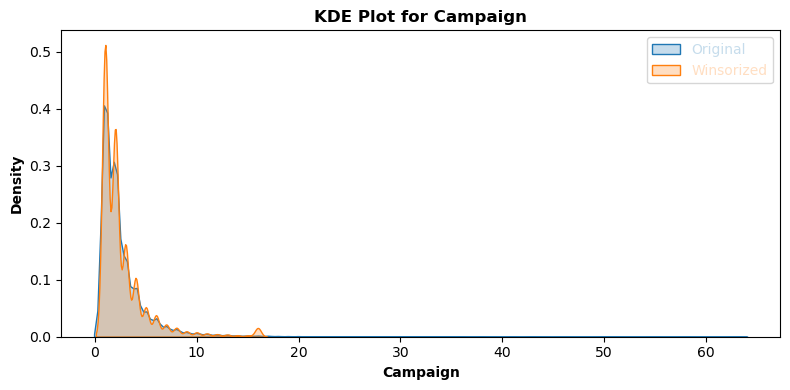

Wilcoxon rank-sum test for 'campaign' : U Statistic: 1022001147.0000, P-Value: 0.9746
The Distributions of 'campaign' are not statistically different (p_value > 0.05).


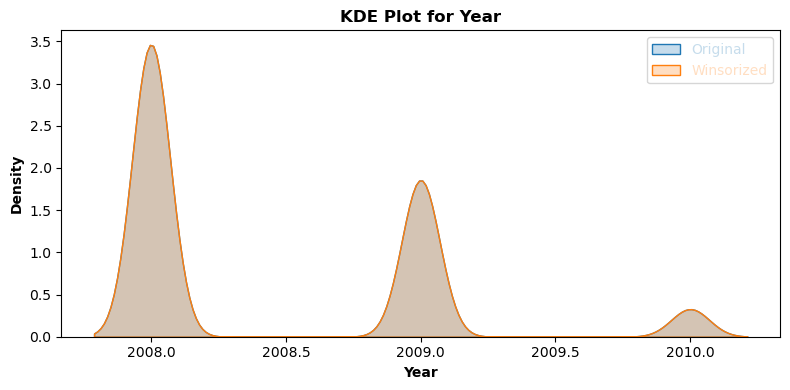

Wilcoxon rank-sum test for 'year' : U Statistic: 1021881632.0000, P-Value: 1.0000
The Distributions of 'year' are not statistically different (p_value > 0.05).


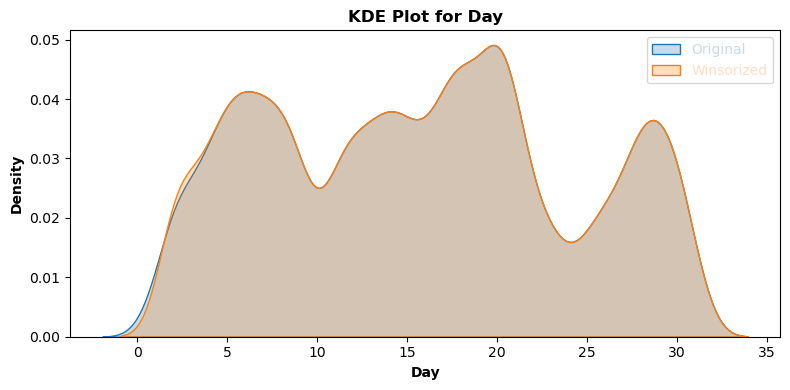

Wilcoxon rank-sum test for 'day' : U Statistic: 1021621617.0000, P-Value: 0.9471
The Distributions of 'day' are not statistically different (p_value > 0.05).


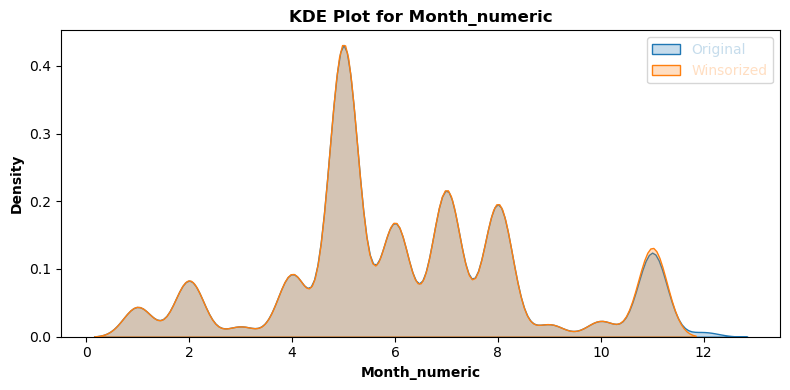

Wilcoxon rank-sum test for 'month_numeric' : U Statistic: 1022329320.0000, P-Value: 0.9074
The Distributions of 'month_numeric' are not statistically different (p_value > 0.05).


In [ ]:
plot_kde_before_after(new_df, winsorize_df, exclude_col=['pdays'])

## **7. Feature Engineering**

In [ ]:
winsorize_df['age_group'] = pd.cut(winsorize_df['age'],bins=3, labels=['young','middle-age','senior'])
winsorize_df.head(1)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,term_deposit,age_group,balance_category,duration_category,contact_frequency_category,pdays_category,previous_category,year,month_numeric,year_month,age_band,duration_band
0,58.00,management,married,tertiary,no,2143.00,yes,no,unknown,5.00,may,261.00,1.00,-1,0.00,unknown,no,senior,Medium ($1K-5K),Medium (181-300 sec),Single Contact,Never Contacted,No Previous Contact,2008.00,5.00,2008-05-01,50-59,Medium (2-5 min)


#### **7.1. Feature Selection**

**Numerical Features**

**7.1.1Correlation Method**

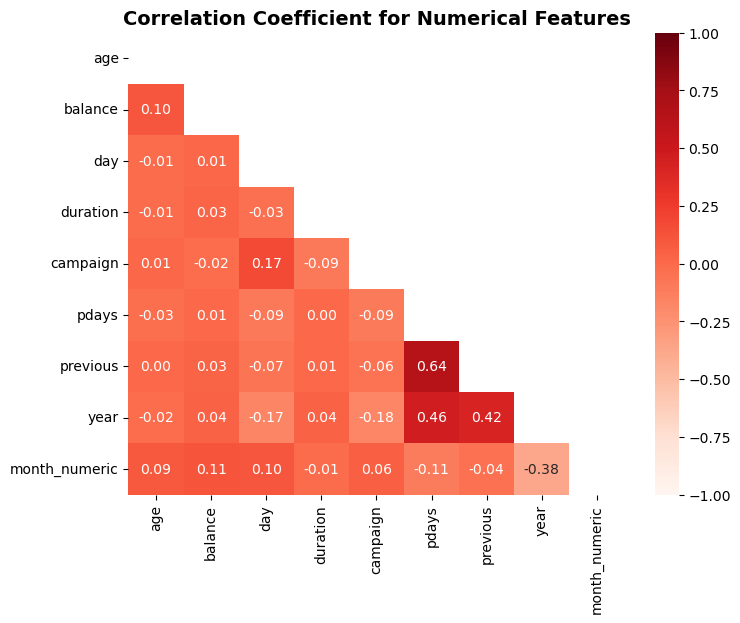

In [ ]:
# Calculate correlation of numerical columns
corr_df = winsorize_df.select_dtypes(include='number').corr()

# Generate a mask for upper triangle
mask = np.zeros_like(corr_df, dtype=bool)
mask[np.triu_indices_from(mask)] = True
# plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_df, annot=True, fmt='.2f', mask=mask, cmap='Reds',vmin=-1, vmax=1, cbar=True)
plt.title('Correlation Coefficient for Numerical Features',fontsize=14, fontweight='bold')
plt.show()

**pearson's r also known as Pearson Correlation Coefficient. It calculates linear relation between numerical features. Eliminating Features on this basis would only runs the risk of removing too much information, which is detrimental to your efforts for building a reliable model. Follow hybrid method for elimination of features, will use VIF.**

**7.1.2. VIF Method**

In [ ]:
# compute vif for numeric columns
def calculate_vif(df:pd.DataFrame):

    #select numeric columns
    num_df = df.select_dtypes(include='number')
    # the computation of vif required constant
    num_df['intercept'] = 1

    # create Dataframe to store features and vif values
    vif_df = pd.DataFrame()
    vif_df['Features'] = num_df.columns
    vif_df['VIF'] = [variance_inflation_factor(num_df.values, i) for i in range(num_df.shape[1])]
    vif_df = vif_df[vif_df['Features'] != 'intercept']
    return(vif_df)

# Criterion: Remove variable with vif >= 5

In [ ]:
vif = calculate_vif(winsorize_df)
vif['VIF'] = vif['VIF'].round(0)
vif

,Features,VIF
0,age,1.00
1,balance,1.00
2,day,1.00
3,duration,1.00
4,campaign,1.00
5,pdays,2.00
6,previous,2.00
7,year,2.00
8,month_numeric,1.00


In [ ]:
vif[vif['VIF']>4]['Features'].to_list()

[]

**7.1.3. Skewness of Numeric Features**

previous        3.66
balance         3.07
campaign        2.87
pdays           2.62
duration        2.08
year            1.01
age             0.55
month_numeric   0.22
day             0.10
dtype: float64


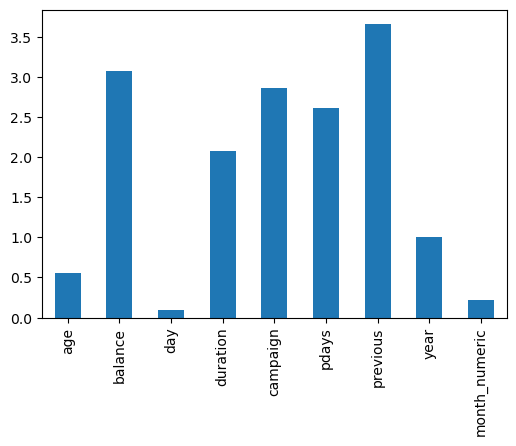

In [ ]:
"""
Zero means normally distributed feature i.e., bell shaped curve.
Positive value means feature has rightly-skewed distribution.
Negative value means feature has left-skewed distribution.

"""
skewed = winsorize_df.select_dtypes(include='number').apply(lambda x: stats.skew(x))
print(skewed.sort_values(ascending=False))

# plot skewness of each features
ax=skewed.plot(kind='bar',figsize=(6,4))
plt.show()


**Categorical Features**

*****Categorical Features Modification*****

- **If three categories and one is sparse, impute with max frequency. If more than three categories and some are sparse, mold sparses into 'other' categories.**

In [ ]:
winsorize_df['marital'].value_counts(normalize=True).idxmax() == winsorize_df['marital'].mode()

0    True
Name: marital, dtype: bool

In [ ]:
def replace_small_categories_with_mode(df:pd.DataFrame, column:str):
    """
    A Dataframe with categorical columns in it.

    Parameters:
    df(pd.DataFrame): the input dataframe.
    column(str): list of columns to replace smallest category with mode / maximum value

    Returns:
    pd.DataFrame: A DataFrame with categorical columns whose smallest category is replaced.
    
    """
    # Lets make a df copy 
    df_copy = df.copy(deep=True)

    # calculate proportions of each columns
    category_proportions = df_copy[column].value_counts(normalize=True)

    # Identify the category with smallest proportions
    small_category = category_proportions.idxmin()

    # Find most frequent category
    mode = category_proportions.idxmax()
 
    # Replace small category with mode if number of categories is equal to 3
    if len(category_proportions)==3:
        df_copy[column] = np.where(df_copy[column]==small_category, mode, df_copy[column])
    
    return df_copy

In [ ]:
cat_col = winsorize_df.select_dtypes(exclude='number').columns
col = [col for col in cat_col if 'unknown' in winsorize_df[col].values]
for i in col:
    print(i  , (winsorize_df[i].nunique()))

job 12
education 4
contact 3
poutcome 4


In [ ]:
# mutate for categorical column where it has three categories

mutate_with_mode = ['default', 'housing', 'loan']
for col in mutate_with_mode:
    winsorize_df = replace_small_categories_with_mode(winsorize_df, column= col)

In [ ]:
def merge_small_categories(df:pd.DataFrame, column:str, threshold: float, min_categories=4, categories_under_threshold=1):
    """
    
    """
    # Let's create a copy 
    df_copy = df.copy(deep=True)

    # Calculate the proportion of each category
    category_proportions = df_copy[column].value_counts(normalize=True)

    # Identify small categories
    small_category = category_proportions[category_proportions < threshold].index

    # Check if the total number of unique categories is greater than the specified categories
    if len(category_proportions) >= min_categories:
        # Check if at least the specified number of categories greater than number of threshold category
        if len(small_category) >= categories_under_threshold:
            #Replace small categories with 'Others' using map
            df_copy[column] = df_copy[column].map(lambda x: 'Others' if x in small_category else x)
    
    return df_copy

In [ ]:
merge_threshold = {'job': 0.03, 'marital': 0.01, 'education': 0.05}

for col, threshold in merge_threshold.items():
    winsorize_df = merge_small_categories(winsorize_df, column=col, threshold=threshold)

In [ ]:
# Mapping dictionaries(use Q2, Q3 and write Q1, Q4 as 'others')
month_to_quarter = {'jan': 'Others', 'feb': 'Others', 'mar': 'Others',
                    'apr': 'Q2', 'may': 'Q2', 'jun': 'Q2',
                    'jul': 'Q3', 'aug': 'Q3', 'sep': 'Q3',
                    'oct': 'Others', 'nov': 'Others', 'dec': 'Others'}

winsorize_df['quarter'] = winsorize_df['month'].map(month_to_quarter)

**5.1.4. Cramer's V**

**Cramer's V unlocks the strength and direction of associations between categorical features and returns a value between 0(weak) and 1(strong).**

In [ ]:
def cramers_v(x,y):
    """ Calculate Cramers'V statistics for two categorical variables."""
    confusion_matrix = pd.crosstab(x,y) # compute contigency table
    chi2, p, dof, expected = stats.chi2_contingency(confusion_matrix) # compute chi2 statistics
    n = confusion_matrix.sum().sum() # total number of observations
    min_dim = min(confusion_matrix.shape) - 1 # minimum dimension of confusion matix
    V = np.sqrt((chi2 / n) / min_dim) # calculate cramers'V statistics
    return V, chi2, p, dof



def filter_cat_features_association(df:pd.DataFrame):
    """
    Calculate cramers'V and chi-squared for each pair of categorical features.

    Parameters:
    df(pd.DataFrame): The input dataframe contains categorical features.

    Returns: 
    pd.DataFrame: A DataFrame contiaing pair of categorical features with their cramers'v values, chi-squared statistics, p_value, degree of freedom.
    """

    cat_col = df.select_dtypes(exclude='number').columns
    results = []

    for col1, col2 in combinations(cat_col, 2):
        V, chi2, p, dof = cramers_v(df[col1], df[col2])
        results.append({'Feature1': col1, 'Feature2': col2, 'Cramers_V': V, 'P_value': p, 'Degrees of Freedom': dof})

    results_df = pd.DataFrame(results)
    return results_df



In [ ]:
pd.set_option('display.max_rows' ,None)
# Association between columns other than target_column: term_deposit
cramers_df = filter_cat_features_association(winsorize_df)
cramers_df[(cramers_df['Feature2'] != 'term_deposit') & (cramers_df['Feature1'] != 'term_deposit')].reset_index(drop=True)

,Feature1,Feature2,Cramers_V,P_value,Degrees of Freedom
0,job,marital,0.15,0.00,16
1,job,education,0.44,0.00,24
2,job,default,0.03,0.00,8
3,job,housing,0.28,0.00,8
4,job,loan,0.10,0.00,8
5,job,contact,0.15,0.00,16
6,job,month,0.12,0.00,88
7,job,poutcome,0.05,0.00,24
8,job,age_group,0.37,0.00,16
9,job,balance_category,0.07,0.00,40


In [ ]:
# Association between columns and target column: term_deposit
cramers_df[(cramers_df['Feature2'] == 'term_deposit') | (cramers_df['Feature1'] == 'term_deposit')].reset_index(drop=True)

,Feature1,Feature2,Cramers_V,P_value,Degrees of Freedom
0,job,term_deposit,0.12,0.00,8
1,marital,term_deposit,0.07,0.00,2
2,education,term_deposit,0.07,0.00,3
3,default,term_deposit,0.02,0.00,1
4,housing,term_deposit,0.14,0.00,1
5,loan,term_deposit,0.07,0.00,1
6,contact,term_deposit,0.15,0.00,2
7,month,term_deposit,0.26,0.00,11
8,poutcome,term_deposit,0.31,0.00,3
9,term_deposit,age_group,0.09,0.00,2


In [ ]:
def cramers_v(x,y):
    """ Calculate Cramers'V statistics for two categorical variables."""
    confusion_matrix = pd.crosstab(x,y) # compute contigency table
    chi2, p, dof, expected = stats.chi2_contingency(confusion_matrix) # compute chi2 statistics
    n = confusion_matrix.sum().sum() # total number of observations
    min_dim = min(confusion_matrix.shape) - 1 # minimum dimension of confusion matix
    V = np.sqrt((chi2 / n) / min_dim) # calculate cramers'V statistics
    return V



In [ ]:


def filter_cat_features_visualization(df:pd.DataFrame):
    """
    Calculate cramers'V and chi-squared for each pair of categorical features.

    Parameters:
    df(pd.DataFrame): The input dataframe contains categorical features.

    Returns: 
    pd.DataFrame: A DataFrame contiaing pair of categorical features with their cramers'v values, chi-squared statistics, p_value, degree of freedom.
    """

    cat_col = df.select_dtypes(exclude='number').columns
    #results = []
    cramers_result = pd.DataFrame(index=cat_col.to_list(), columns=cat_col.to_list())
    #corrM = np.zeros((len(cat_col), len(cat_col)))

    #for col1, col2 in combinations(cat_col, 2):
    for col1 in cat_col:
        for col2 in cat_col:
            if col1 != col2:
                cramers_result.loc[col1, col2] = cramers_v(df[col1], df[col2])
            else:
                cramers_result.loc[col1, col2] = 1
    
    cramers_result = cramers_result.astype(float)
    return cramers_result



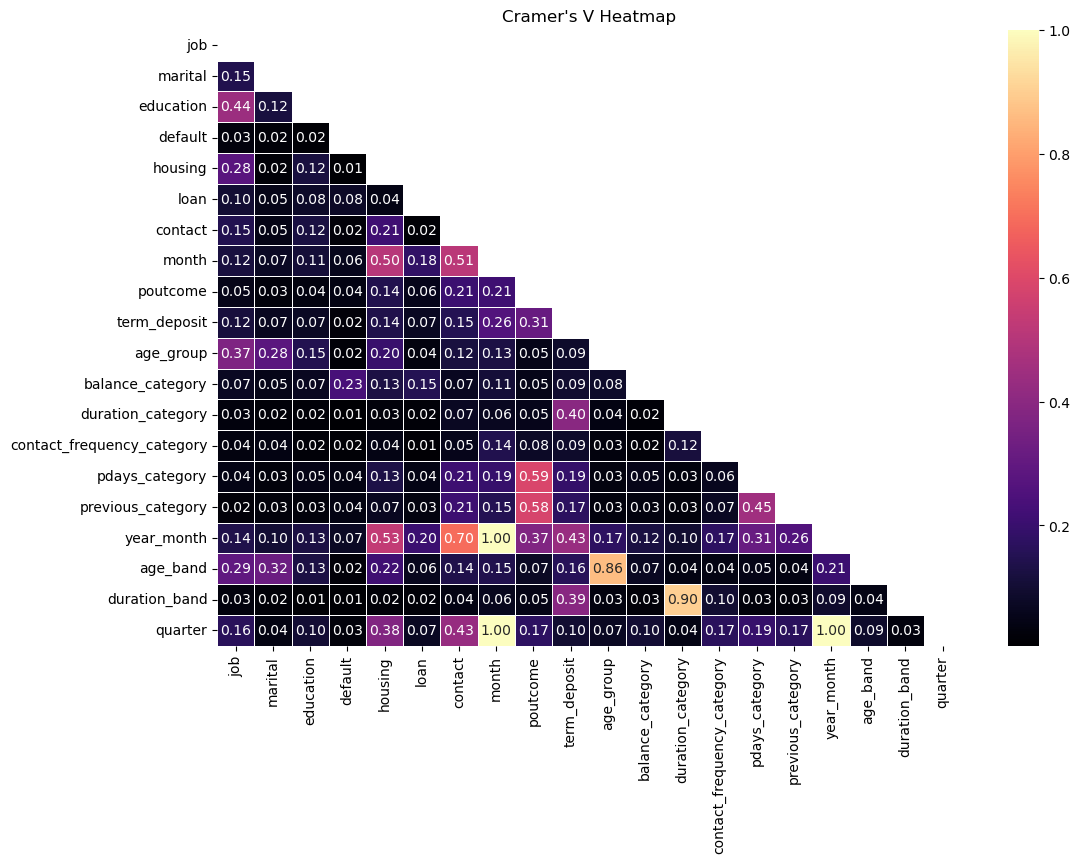

In [ ]:
cramers_df = filter_cat_features_visualization(winsorize_df)
plt.figure(figsize=(12, 8))
mask = np.zeros_like(cramers_df, dtype='bool')
mask[np.triu_indices_from(mask)] = True
sns.heatmap(cramers_df, mask=mask ,annot=True, cmap='magma', fmt=".2f", linewidths=0.5)
plt.title("Cramer's V Heatmap")
plt.show()
